In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/capstone_clean_data.csv")

In [ ]:
df.head()

,SQLDATE,Actor1Name,Actor2Name,EventCode,SOURCEURL,event
0,20260903,NEPAL,NaN,20,https://www.miragenews.com/nepal-floods-kids-f...,Nepal Floods
1,20260903,BUDDHIST,NaN,10,https://aninews.in/news/world/asia/nepal-flash...,Nepal Floods
2,20260903,ASIAN DEVELOPMENT BANK,SOUTH KOREA,73,https://theindianawaaz.com/nepal-flood-tragedy...,Nepal Floods
3,20260903,NaN,NEPAL,20,https://www.spotlightnepal.com/2026/09/03/reli...,Nepal Floods
4,20260903,NaN,NEPAL,42,https://www.spotlightnepal.com/2026/09/03/japa...,Nepal Floods


In [ ]:
df.shape

(423, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SQLDATE     423 non-null    int64 
 1   Actor1Name  392 non-null    object
 2   Actor2Name  174 non-null    object
 3   EventCode   423 non-null    int64 
 4   SOURCEURL   423 non-null    object
 5   event       423 non-null    object
dtypes: int64(2), object(4)
memory usage: 20.0+ KB


In [ ]:
df.isnull().sum()

,0
SQLDATE,0
Actor1Name,31
Actor2Name,249
EventCode,0
SOURCEURL,0
event,0


In [ ]:
df["Actor1Name"] = df["Actor1Name"].fillna("Unknown")
df["Actor2Name"] = df["Actor2Name"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
SQLDATE,0
Actor1Name,0
Actor2Name,0
EventCode,0
SOURCEURL,0
event,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["event"].value_counts()

,count
event,
NEET Exam Leak,210
Nepal Floods,163
Jaishankar-Putin Meeting,50


In [ ]:
df["event"].value_counts(normalize=True) * 100

,proportion
event,
NEET Exam Leak,49.645390
Nepal Floods,38.534279
Jaishankar-Putin Meeting,11.820331


In [ ]:
df["event"].value_counts(normalize=True)*100

,proportion
event,
NEET Exam Leak,49.645390
Nepal Floods,38.534279
Jaishankar-Putin Meeting,11.820331


“The dataset is moderately imbalanced. NEET Exam Leak has the highest representation, while the Jaishankar–Putin Meeting is under-represented.”

In [ ]:
from urllib.parse import urlparse

df["domain"] = df["SOURCEURL"].apply(
    lambda x: urlparse(x).netloc.replace("www.", "")##https://www.bbc.com=bbc.com
)

df["domain"].value_counts().head(20)

,count
domain,
navbharattimes.indiatimes.com,21
economictimes.indiatimes.com,11
timesofindia.indiatimes.com,11
spotlightnepal.com,10
napaneetoday.ca,9
india.com,9
news18.com,8
thehindu.com,8
theindianawaaz.com,7


This analysis shows how the articles are distributed across different news sources or domains. It helps us understand which websites contribute more articles to the dataset and whether any source dominates the data.”

In [ ]:
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"].astype(str), format="%Y%m%d")##converts 20260903 into 2026-09-03



print("Start date:", df["SQLDATE"].min())
print("End date:", df["SQLDATE"].max())

Start date: 2022-01-26 00:00:00
End date: 2026-09-03 00:00:00


We are checking the time range covered by the articles in the dataset.

In [ ]:
df[["SOURCEURL", "domain", "event"]].head(10)

,SOURCEURL,domain,event
0,https://www.miragenews.com/nepal-floods-kids-f...,miragenews.com,Nepal Floods
1,https://aninews.in/news/world/asia/nepal-flash...,aninews.in,Nepal Floods
2,https://theindianawaaz.com/nepal-flood-tragedy...,theindianawaaz.com,Nepal Floods
3,https://www.spotlightnepal.com/2026/09/03/reli...,spotlightnepal.com,Nepal Floods
4,https://www.spotlightnepal.com/2026/09/03/japa...,spotlightnepal.com,Nepal Floods
5,https://www.clickorlando.com/news/world/2026/0...,clickorlando.com,Nepal Floods
6,https://www.spotlightnepal.com/2026/09/03/eu-p...,spotlightnepal.com,Nepal Floods
7,https://scroll.in/article/1044769/a-community-...,scroll.in,Nepal Floods
8,https://www.thethirdpole.net/en/regional-coope...,thethirdpole.net,Nepal Floods
9,https://www.aljazeera.com/news/2023/3/10/lack-...,aljazeera.com,Nepal Floods


In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
url=df["SOURCEURL"].iloc[0]## storing it in a variable
url

'https://www.miragenews.com/nepal-floods-kids-face-water-crisis-disease-risk-1738136/'

In [ ]:
response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=10
)

response.status_code### Send a request to the first article URL with a browser header and 10-second timeout

200

In [ ]:
soup=BeautifulSoup(response.text,"html.parser")### conerts raw web bpage into python code

In [ ]:
title = soup.title.get_text(strip=True)

title

'Nepal Floods: Kids Face Water Crisis, Disease Risk | Mirage News'

In [ ]:
title=soup.title.get_text(strip=True)### Extract the title from the webpage
title

'Nepal Floods: Kids Face Water Crisis, Disease Risk | Mirage News'

In [ ]:
clean_title = title.split("|")[0].strip()### Remove the website name and keep only the article headline

clean_title

'Nepal Floods: Kids Face Water Crisis, Disease Risk'

# Create a function to extract the title from any article URL

In [ ]:
def extract_title(url):
    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},### Use a browser-style header when requesting the webpage
        timeout=10
    )

    soup = BeautifulSoup(response.text, "html.parser")

    title = soup.title.get_text(strip=True)

    return title

In [ ]:
df["SOURCEURL"].head(3).apply(extract_title)

,SOURCEURL
0,"Nepal Floods: Kids Face Water Crisis, Disease ..."
1,403 Forbidden
2,Nepal Flood Tragedy: Death toll rises to over ...


In [ ]:
def extract_title(url):
    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        if soup.title:
            return soup.title.get_text(strip=True)

        return None

    except:
        return None### Safely extract the title and return None if the webpage cannot be accessed

In [ ]:
df["SOURCEURL"].head(3).apply(extract_title)### Test the safe title extraction function on the first 3 article URLs

,SOURCEURL
0,"Nepal Floods: Kids Face Water Crisis, Disease ..."
1,None
2,Nepal Flood Tragedy: Death toll rises to over ...


In [ ]:
df["title"] = df["SOURCEURL"].apply(extract_title)### Extract article titles for all URLs and store them in a new title column

In [ ]:
df[["SOURCEURL", "title"]].head(10)

,SOURCEURL,title
0,https://www.miragenews.com/nepal-floods-kids-f...,"Nepal Floods: Kids Face Water Crisis, Disease ..."
1,https://aninews.in/news/world/asia/nepal-flash...,None
2,https://theindianawaaz.com/nepal-flood-tragedy...,Nepal Flood Tragedy: Death toll rises to over ...
3,https://www.spotlightnepal.com/2026/09/03/reli...,Relief Supplies for Bhotekoshi Flood Victims A...
4,https://www.spotlightnepal.com/2026/09/03/japa...,Japan and JICA Support Nepal's Flood-Affected ...
5,https://www.clickorlando.com/news/world/2026/0...,Trading food for medicine and crossing the riv...
6,https://www.spotlightnepal.com/2026/09/03/eu-p...,The EU provides further NPR 89 Million In Huma...
7,https://scroll.in/article/1044769/a-community-...,How community-led warning system across Nepal-...
8,https://www.thethirdpole.net/en/regional-coope...,None
9,https://www.aljazeera.com/news/2023/3/10/lack-...,Lack of cross-border flood alerts adds to disa...


In [ ]:
df[["SOURCEURL","title"]].head(10)

,SOURCEURL,title
0,https://www.miragenews.com/nepal-floods-kids-f...,"Nepal Floods: Kids Face Water Crisis, Disease ..."
1,https://aninews.in/news/world/asia/nepal-flash...,None
2,https://theindianawaaz.com/nepal-flood-tragedy...,Nepal Flood Tragedy: Death toll rises to over ...
3,https://www.spotlightnepal.com/2026/09/03/reli...,Relief Supplies for Bhotekoshi Flood Victims A...
4,https://www.spotlightnepal.com/2026/09/03/japa...,Japan and JICA Support Nepal's Flood-Affected ...
5,https://www.clickorlando.com/news/world/2026/0...,Trading food for medicine and crossing the riv...
6,https://www.spotlightnepal.com/2026/09/03/eu-p...,The EU provides further NPR 89 Million In Huma...
7,https://scroll.in/article/1044769/a-community-...,How community-led warning system across Nepal-...
8,https://www.thethirdpole.net/en/regional-coope...,None
9,https://www.aljazeera.com/news/2023/3/10/lack-...,Lack of cross-border flood alerts adds to disa...


In [ ]:
df["title"].isnull().sum()

np.int64(129)

In [ ]:
df[df["title"].isnull()]["event"].value_counts()### Check which news sources have the most missing titles

,count
event,
NEET Exam Leak,72
Nepal Floods,42
Jaishankar-Putin Meeting,15


In [ ]:
df[df["title"].notnull()]["event"].value_counts()### Count the available article titles for each event

,count
event,
NEET Exam Leak,138
Nepal Floods,121
Jaishankar-Putin Meeting,35


In [ ]:
df[df["title"].isnull()]["domain"].value_counts().head(15)### Check which news sources have the most missing article titles

,count
domain,
india.com,9
news18.com,8
telegraphindia.com,7
indianexpress.com,6
dnaindia.com,6
ndtv.com,6
aninews.in,5
palpalindia.com,4
thestatesman.com,4


In [ ]:
text_df = df.dropna(subset=["title"]).copy()

text_df.shape### Keep only rows where the article title was successfully extracted

(294, 8)

In [ ]:
text_df["clean_title"]=text_df["title"].str.lower()### Convert all article titles to lowercase

In [ ]:
text_df["clean_title"] = text_df["clean_title"].str.replace(
    r"[^\w\s]",## searches puncations
    "",
    regex=True
)### Remove punctuation from article titles

In [ ]:
text_df["clean_title"] = text_df["clean_title"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()### Remove extra spaces from the cleaned titles

In [ ]:
text_df[["title", "clean_title"]].head()

,title,clean_title
0,"Nepal Floods: Kids Face Water Crisis, Disease ...",nepal floods kids face water crisis disease ri...
2,Nepal Flood Tragedy: Death toll rises to over ...,nepal flood tragedy death toll rises to over 1...
3,Relief Supplies for Bhotekoshi Flood Victims A...,relief supplies for bhotekoshi flood victims a...
4,Japan and JICA Support Nepal's Flood-Affected ...,japan and jica support nepals floodaffected co...
5,Trading food for medicine and crossing the riv...,trading food for medicine and crossing the riv...


In [ ]:
text_df["clean_title"] = text_df["clean_title"].str.replace(
    r"[^\w\s]",
    "",
    regex=True
)

In [ ]:
text_df[["title", "clean_title"]].head()

,title,clean_title
0,"Nepal Floods: Kids Face Water Crisis, Disease ...",nepal floods kids face water crisis disease ri...
2,Nepal Flood Tragedy: Death toll rises to over ...,nepal flood tragedy death toll rises to over 1...
3,Relief Supplies for Bhotekoshi Flood Victims A...,relief supplies for bhotekoshi flood victims a...
4,Japan and JICA Support Nepal's Flood-Affected ...,japan and jica support nepals floodaffected co...
5,Trading food for medicine and crossing the riv...,trading food for medicine and crossing the riv...


In [ ]:
text_df["clean_title"] = text_df["clean_title"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()## removes extra space

In [ ]:
import nltk
nltk.download("stopwords")### Download the English stopwords list

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))### Load the English stopwords

text_df["clean_title"] → selects the cleaned title column
.apply() → applies the same operation to every title
lambda x: → treats each title as x
x.split() → splits the title into individual words
if word not in stop_words → removes common words like the, is, and, to
" ".join(...) → joins the remaining useful words back into a sentence
Final result → each title is cleaned and contains mainly meaningful words

In [ ]:
text_df["clean_title"] = text_df["clean_title"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [ ]:
text_df[["title", "clean_title"]].head(10)

,title,clean_title
0,"Nepal Floods: Kids Face Water Crisis, Disease ...",nepal floods kids face water crisis disease ri...
2,Nepal Flood Tragedy: Death toll rises to over ...,nepal flood tragedy death toll rises 1250 4000...
3,Relief Supplies for Bhotekoshi Flood Victims A...,relief supplies bhotekoshi flood victims arriv...
4,Japan and JICA Support Nepal's Flood-Affected ...,japan jica support nepals floodaffected commun...
5,Trading food for medicine and crossing the riv...,trading food medicine crossing river zip line ...
6,The EU provides further NPR 89 Million In Huma...,eu provides npr 89 million humanitarian aid re...
7,How community-led warning system across Nepal-...,communityled warning system across nepalindia ...
9,Lack of cross-border flood alerts adds to disa...,lack crossborder flood alerts adds disaster fe...
10,Saptakoshi Had Worst Flood In 34 Years | New S...,saptakoshi worst flood 34 years new spotlight ...
11,Flooding causes over Rs5 Million damage to Nep...,flooding causes rs5 million damage nepals hist...


In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
sample_text = text_df["clean_title"].iloc[0]

tokens = word_tokenize(sample_text)

tokens

['nepal',
 'floods',
 'kids',
 'face',
 'water',
 'crisis',
 'disease',
 'risk',
 'mirage',
 'news']

In [ ]:
sample_text = text_df["clean_title"].iloc[0]

tokens = word_tokenize(sample_text)

print(tokens)

['nepal', 'floods', 'kids', 'face', 'water', 'crisis', 'disease', 'risk', 'mirage', 'news']


In [ ]:
from nltk.stem import PorterStemmer
stemmer= PorterStemmer()
stemmed_tokens=[stemmer.stem(word)for word in tokens]
print(stemmed_tokens)### Reduce each token to its basic stem form

['nepal', 'flood', 'kid', 'face', 'water', 'crisi', 'diseas', 'risk', 'mirag', 'news']


In [ ]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
lemmatized_tokens=[lemmatizer.lemmatize(word) for word in tokens]
print(lemmatized_tokens)### Convert tokens into their dictionary base form using lemmatization

['nepal', 'flood', 'kid', 'face', 'water', 'crisis', 'disease', 'risk', 'mirage', 'news']


# Create a function to tokenize and lemmatize each cleaned title

In [ ]:
def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized)

In [ ]:
text_df["processed_title"] = text_df["clean_title"].apply(lemmatize_text)### Apply tokenization and lemmatization to all cleaned article titles

In [ ]:
text_df[["clean_title", "processed_title"]].head(10)

,clean_title,processed_title
0,nepal floods kids face water crisis disease ri...,nepal flood kid face water crisis disease risk...
2,nepal flood tragedy death toll rises 1250 4000...,nepal flood tragedy death toll rise 1250 4000 ...
3,relief supplies bhotekoshi flood victims arriv...,relief supply bhotekoshi flood victim arrive k...
4,japan jica support nepals floodaffected commun...,japan jica support nepal floodaffected communi...
5,trading food medicine crossing river zip line ...,trading food medicine crossing river zip line ...
6,eu provides npr 89 million humanitarian aid re...,eu provides npr 89 million humanitarian aid re...
7,communityled warning system across nepalindia ...,communityled warning system across nepalindia ...
9,lack crossborder flood alerts adds disaster fe...,lack crossborder flood alert add disaster fear...
10,saptakoshi worst flood 34 years new spotlight ...,saptakoshi worst flood 34 year new spotlight m...
11,flooding causes rs5 million damage nepals hist...,flooding cause rs5 million damage nepal histor...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer### Import TF-IDF to convert processed text into numerical features

In [ ]:
tfidf = TfidfVectorizer()

fit → learns the vocabulary from your 289 titles
transform → converts each title into numbers
X → stores the numerical TF-IDF matri

In [ ]:
X=tfidf.fit_transform(text_df["processed_title"])

In [ ]:
X.shape

(294, 1733)

Bias Analysis
“Sentiment analysis is used to measure the emotional tone of article headlines and identify whether the language is positive, negative, or neutral.

In [ ]:
import nltk
nltk.download("vader_lexicon")### Download the VADER sentiment lexicon

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()### Create the VADER sentiment analyser

In [ ]:
text_df["sentiment_score"]=text_df["title"].apply(
    lambda x:sia.polarity_scores(x)["compound"]
)### Calculate the overall sentiment score for every article title

In [ ]:
text_df.columns

Index(['SQLDATE', 'Actor1Name', 'Actor2Name', 'EventCode', 'SOURCEURL',
       'event', 'domain', 'title', 'clean_title', 'processed_title',
       'sentiment_score'],
      dtype='object')

In [ ]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"### Convert sentiment scores into positive, negative, or neutral labels

In [ ]:
text_df["sentiment_label"] = text_df["sentiment_score"].apply(sentiment_label)### Apply sentiment labels to all article titles

In [ ]:
text_df["sentiment_label"].value_counts()

,count
sentiment_label,
Negative,151
Neutral,100
Positive,43


“The sentiment analysis shows that negative headlines are the most common, followed by neutral and positive headlines. This suggests that the dataset contains a stronger negative emotional tone overall.”

In [ ]:
pd.crosstab(
    text_df["event"],
    text_df["sentiment_label"]
)

sentiment_label,Negative,Neutral,Positive
event,,,
Jaishankar-Putin Meeting,11,18,6
NEET Exam Leak,51,62,25
Nepal Floods,89,20,12


In [ ]:
sentiment_by_event = pd.crosstab(
    text_df["event"],
    text_df["sentiment_label"],
    normalize="index"
) * 100

sentiment_by_event### Compare the percentage of positive, negative and neutral sentiment within each event

sentiment_label,Negative,Neutral,Positive
event,,,
Jaishankar-Putin Meeting,31.428571,51.428571,17.142857
NEET Exam Leak,36.956522,44.927536,18.115942
Nepal Floods,73.553719,16.528926,9.917355


“Because the number of articles differs across events, row-wise normalization was used to compare sentiment percentages fairly within each event.”

In [ ]:
normalize="index"

In [ ]:
sentiment_by_event = pd.crosstab(
    text_df["event"],
    text_df["sentiment_label"],
    normalize="index"
) * 100

In [ ]:
sentiment_by_event.round(2)### Round the sentiment percentages to two decimal places

sentiment_label,Negative,Neutral,Positive
event,,,
Jaishankar-Putin Meeting,31.43,51.43,17.14
NEET Exam Leak,36.96,44.93,18.12
Nepal Floods,73.55,16.53,9.92


“Negative sentiment does not automatically mean media bias. It may reflect the nature of the event itself.”

.2: Subjectivity Analysis
“Subjectivity analysis measures whether a headline is more factual/objective or more opinion-based/subjective.”


In [ ]:
from textblob import TextBlob

In [ ]:
text_df["subjectivity_score"] = text_df["title"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)### Calculate the subjectivity score for every article title

In [ ]:
text_df.columns

Index(['SQLDATE', 'Actor1Name', 'Actor2Name', 'EventCode', 'SOURCEURL',
       'event', 'domain', 'title', 'clean_title', 'processed_title',
       'sentiment_score', 'sentiment_label', 'subjectivity_score'],
      dtype='object')

In [ ]:
def subjectivity_label(score):
    if score < 0.5:
        return "Objective"
    else:### Convert subjectivity scores into objective or subjective labels
        return "Subjective"

In [ ]:
text_df["subjectivity_label"] = text_df["subjectivity_score"].apply(subjectivity_label)

In [ ]:
text_df["subjectivity_label"].value_counts()

,count
subjectivity_label,
Objective,257
Subjective,37


In [ ]:
text_df["subjectivity_label"].value_counts(normalize=True) * 100

,proportion
subjectivity_label,
Objective,87.414966
Subjective,12.585034


“Most article headlines in the dataset are objective. Around 87.5% were classified as objective, while only about 12.5% were subjective. This suggests that the majority of headlines use more factual than opinion-based language.”

In [ ]:
subjectivity_by_event = pd.crosstab(
    text_df["event"],
    text_df["subjectivity_label"],
    normalize="index"
) * 100

subjectivity_by_event.round(2)

subjectivity_label,Objective,Subjective
event,,
Jaishankar-Putin Meeting,94.29,5.71
NEET Exam Leak,88.41,11.59
Nepal Floods,84.30,15.70


“Row-wise normalization was used because the number of articles differs across events. This allows fair comparison of subjectivity percentages within each event.”

In [ ]:
normalize="index"

3. Framing / Loaded Language Analysis


In [ ]:
loaded_words = [
    "crisis",
    "tragedy",
    "shocking",
    "massive",
    "deadly",
    "outrage",
    "disaster",
    "chaos",
    "alarming",
    "devastating"
]### Create a list of emotionally loaded words for framing analysis



In [ ]:
def count_loaded_words(text):
  words=text.split()
  return sum(word in loaded_words for word in words)### Count how many loaded words appear in each headline

In [ ]:
text_df["loaded_word_count"] = text_df["clean_title"].apply(count_loaded_words)### Apply loaded-word counting to all article headlines

In [ ]:
text_df["loaded_word_count"].value_counts().sort_index()

,count
loaded_word_count,
0,277
1,17


“Most headlines did not contain any of the selected loaded words. Only 16 headlines contained one loaded term, suggesting that strongly emotional framing was relatively limited based on this lexicon.”

In [ ]:
loaded_by_event = text_df.groupby("event")["loaded_word_count"].mean() * 100

loaded_by_event.round(2)

,loaded_word_count
event,
Jaishankar-Putin Meeting,0.00
NEET Exam Leak,0.72
Nepal Floods,13.22


In [ ]:
text_df.groupby("event")["loaded_word_count"].mean() * 100

,loaded_word_count
event,
Jaishankar-Putin Meeting,0.000000
NEET Exam Leak,0.724638
Nepal Floods,13.223140


“Loaded language was highest in Nepal Floods headlines, very low in NEET Exam Leak headlines, and absent in Jaishankar–Putin Meeting headlines.”

# Create a summary table for sentiment, subjectivity, and loaded language by event

In [ ]:
summary_table = text_df.groupby("event").agg(
    avg_sentiment=("sentiment_score", "mean"),
    avg_subjectivity=("subjectivity_score", "mean"),
    avg_loaded_language=("loaded_word_count", "mean")
)

summary_table["avg_loaded_language"] = summary_table["avg_loaded_language"] * 100

summary_table.round(2)

,avg_sentiment,avg_subjectivity,avg_loaded_language
event,,,
Jaishankar-Putin Meeting,-0.08,0.16,0.00
NEET Exam Leak,-0.11,0.13,0.72
Nepal Floods,-0.44,0.25,13.22


“The Nepal Floods headlines show the strongest negative tone, the highest subjectivity, and the greatest use of loaded language among the three events. The Jaishankar–Putin headlines are the most neutral and least emotionally framed, while NEET Exam Leak lies between the two.”
Important limitation:

“These scores indicate differences in headline tone and framing, but they should not be treated as definitive proof of media bias because the nature of each event itself can influence language.

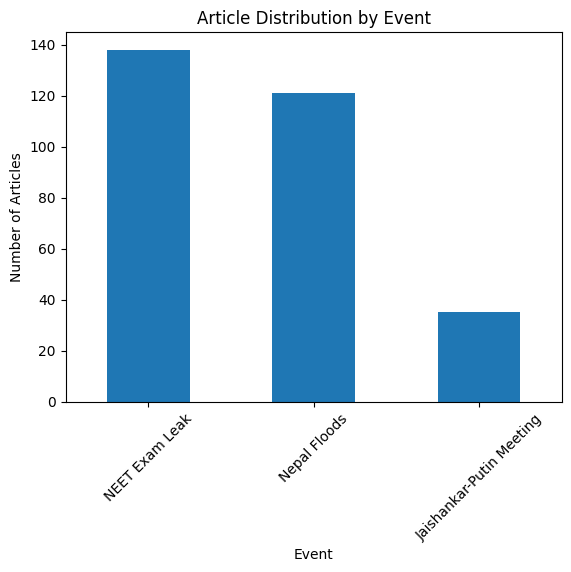

In [ ]:
import matplotlib.pyplot as plt

text_df["event"].value_counts().plot(kind="bar")

plt.title("Article Distribution by Event")
plt.xlabel("Event")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

“The event distribution is imbalanced, with NEET Exam Leak having the highest number of articles and Jaishankar–Putin Meeting having the lowest. This imbalance should be considered during model evaluation.”

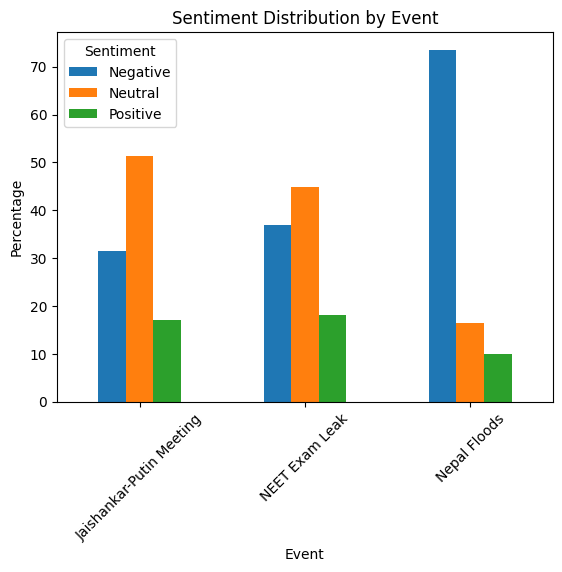

In [ ]:
sentiment_by_event.plot(kind="bar")

plt.title("Sentiment Distribution by Event")
plt.xlabel("Event")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

“The sentiment distribution varies across events. Nepal Floods shows the highest negative sentiment, while Jaishankar–Putin Meeting is predominantly neutral. NEET Exam Leak shows a more mixed sentiment pattern.”
“Negative sentiment should not be interpreted as bias by itself, because the nature of the event can naturally influence headline tone.”

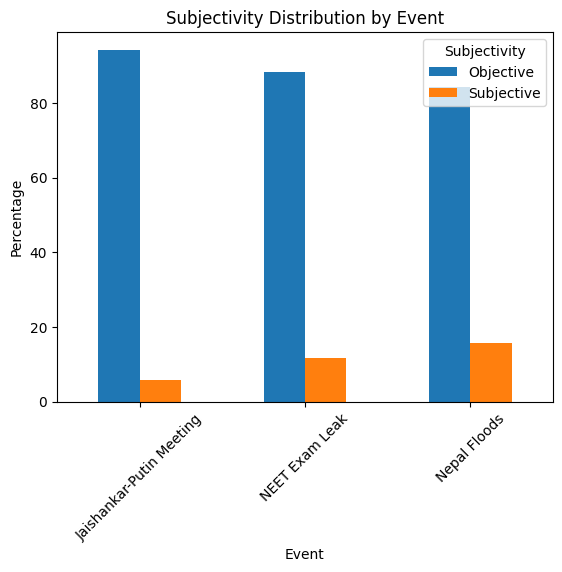

In [ ]:
subjectivity_by_event.plot(kind="bar")

plt.title("Subjectivity Distribution by Event")
plt.xlabel("Event")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Subjectivity")
plt.show()### Visualise objective and subjective headline percentages across events

“The majority of headlines across all three events are objective. Nepal Floods has the highest proportion of subjective headlines, while Jaishankar–Putin Meeting has the lowest.”

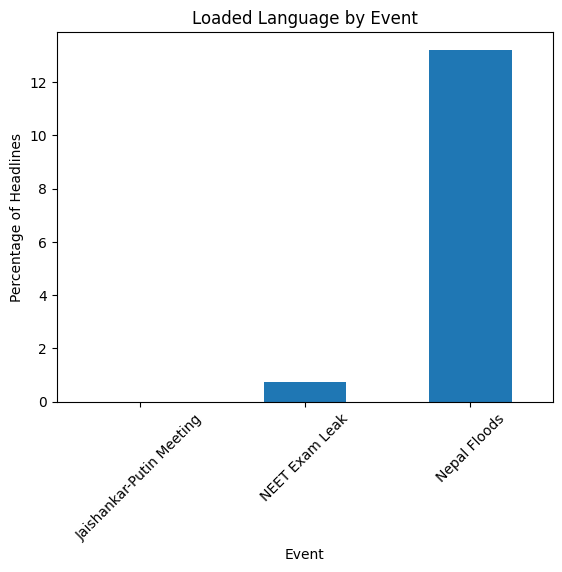

In [ ]:
loaded_by_event.plot(kind="bar")

plt.title("Loaded Language by Event")
plt.xlabel("Event")
plt.ylabel("Percentage of Headlines")
plt.xticks(rotation=45)
plt.show()### Visualise the percentage of headlines containing loaded language across events

“Loaded language was most common in Nepal Floods headlines. Very little loaded language was found in NEET Exam Leak headlines, and none was identified in Jaishankar–Putin Meeting headlines using the selected lexicon.”
“This result depends on the predefined loaded-word list, so it represents a simple framing indicator rather than a complete measurement of media bias.”


Creating Target Variables for Bias Classification
“The event column is used only to identify and group articles. For the bias classification model, separate target labels are created for the selected framing dimensions.The labels are as follows:
5.1 Political Framing Label
5.2 Regional Framing Label
5.3 Socioeconomic Framing Label



In [ ]:
labelled_df = text_df[[
    "title",
    "event",
    "domain",
    "processed_title"
]].copy()### Create a clean dataframe for manual bias labelling

In [ ]:
labelled_df["political_label"]=""
labelled_df["regional_label"]=""
labelled_df["socioeconomic_label"]=""### Create empty target columns for the three bias dimensions

define the labelling rules
“Binary labels are used for each framing dimension, where 1 indicates framing is present and 0 indicates framing is not present.”
Political framing
1 = headline uses political parties, leaders, government actions, blame/praise, or political positioning in a framed way
0 = no political framing
Regional framing
1 = headline strongly focuses on a region/state/country in a way that shapes the story
0 = no regional framing
Socioeconomic framing
1 = headline frames the story around wealth, poverty, class, jobs, business, economic inequality, or financial impact
0 = no socioeconomic framing

In [ ]:
labelled_df[[
    "title",
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].head(10)

,title,political_label,regional_label,socioeconomic_label
0,"Nepal Floods: Kids Face Water Crisis, Disease ...",,,
2,Nepal Flood Tragedy: Death toll rises to over ...,,,
3,Relief Supplies for Bhotekoshi Flood Victims A...,,,
4,Japan and JICA Support Nepal's Flood-Affected ...,,,
5,Trading food for medicine and crossing the riv...,,,
6,The EU provides further NPR 89 Million In Huma...,,,
7,How community-led warning system across Nepal-...,,,
9,Lack of cross-border flood alerts adds to disa...,,,
10,Saptakoshi Had Worst Flood In 34 Years | New S...,,,
11,Flooding causes over Rs5 Million damage to Nep...,,,


In [ ]:
labelled_df[[
    "title",
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].tail(10)
### Display the first 10 headlines with empty bias labels for manual annotation

,title,political_label,regional_label,socioeconomic_label
405,Pete Hegseth Russian flag tie controversy: Awk...,,,
406,PM Modi Peace Message To Russian President Vla...,,,
407,जयशंकर ने UNSC में आतंकवाद पर चीन को दी नसीहत ...,,,
408,S Jaishankar On Russia Ukraine Invasion: India...,,,
411,Russia and China Slam US Air Strikes in Iraq a...,,,
412,"India is set to host Russia's Putin, deepening...",,,
417,India PM Modi to meet Putin in first trip to R...,,,
419,Russian FM Arrives In India To Take Part In SC...,,,
421,PM Narendra Modi holds telephone conversation ...,,,
422,PM Modi speaks with Ukraine's Zelensky ahead o...,,,


In [ ]:
labelled_df = labelled_df.reset_index(drop=True)### Reset the dataframe index before manual labelling

In [ ]:
labelled_df = labelled_df.reset_index(drop=True)

In [ ]:
for i, title in enumerate(labelled_df["title"].head(10)):
    print(i, ":", title)

0 : Nepal Floods: Kids Face Water Crisis, Disease Risk | Mirage News
1 : Nepal Flood Tragedy: Death toll rises to over 1,250; 4,000 still missing – The Indian Awaaz
2 : Relief Supplies for Bhotekoshi Flood Victims Arrive in Kathmandu via U.S. Military Aircraft | New Spotlight Magazine
3 : Japan and JICA Support Nepal's Flood-Affected Communities with Emergency Relief Goods | New Spotlight Magazine
4 : Trading food for medicine and crossing the river by zip line are part of life in Nepal flood zone
5 : The EU provides further NPR 89 Million In Humanitarian Aid And Relief Supplies For Flood-Affected Communities In Nepal | New Spotlight Magazine
6 : How community-led warning system across Nepal-India border is saving lives during devastating floods
7 : Lack of cross-border flood alerts adds to disaster fears in Nepal | Floods News | Al Jazeera
8 : Saptakoshi Had Worst Flood In 34 Years | New Spotlight Magazine
9 : Flooding causes over Rs5 Million damage to Nepal's historic Chandra Nahar


In [ ]:
labelled_df.loc[0:9, "political_label"] = [0,0,0,0,0,0,0,0,0,0]## mo bias detected

labelled_df.loc[0:9, "regional_label"] = [0,0,0,0,0,0,1,1,0,0]## few bias are detected(6&7)

labelled_df.loc[0:9, "socioeconomic_label"] = [0,0,0,0,1,1,0,0,1,0]### Manually assign bias labels to the first 10 headlines(4,5&8)








In [ ]:
labelled_df[[
    "title",
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].head(10)

,title,political_label,regional_label,socioeconomic_label
0,"Nepal Floods: Kids Face Water Crisis, Disease ...",0,0,0
1,Nepal Flood Tragedy: Death toll rises to over ...,0,0,0
2,Relief Supplies for Bhotekoshi Flood Victims A...,0,0,0
3,Japan and JICA Support Nepal's Flood-Affected ...,0,0,0
4,Trading food for medicine and crossing the riv...,0,0,1
5,The EU provides further NPR 89 Million In Huma...,0,0,1
6,How community-led warning system across Nepal-...,0,1,0
7,Lack of cross-border flood alerts adds to disa...,0,1,0
8,Saptakoshi Had Worst Flood In 34 Years | New S...,0,0,1
9,Flooding causes over Rs5 Million damage to Nep...,0,0,0


In [ ]:
labelled_df.loc[9, "political_label"] = 0
labelled_df.loc[9, "regional_label"] = 0
labelled_df.loc[9, "socioeconomic_label"] = 0### Fill the missing labels for headline 9

In [ ]:
labelled_df.loc[9]

,9
title,Flooding causes over Rs5 Million damage to Nep...
event,Nepal Floods
domain,kathmandupost.com
processed_title,flooding cause rs5 million damage nepal histor...
political_label,0
regional_label,0
socioeconomic_label,0


In [ ]:
labelled_df.loc[9, "socioeconomic_label"] = 0 ### Fill the missing labels for headline 9

In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[10:20], start=10):
    print(i, ":", title)### Display headlines 10 to 19 for manual bias labelling

10 : 101 dead in Nepal floods after relentless monsoon rains  - The Standard
11 : 132 dead in floods, landslides, and disasters: Home Ministry - The Himalayan Times - Nepal's No.1 English Daily Newspaper | Nepal News, Latest Politics, Business, World, Sports, Entertainment, Travel, Life Style News
12 : Death Toll Climbs To 112 In Nepal As Landslides And Floods Wreak Havoc - Oneindia News
13 : Nepal flood and landslide toll reaches more than 120 | Newcastle Herald | Newcastle, NSW
14 : Nearly 200 killed in floods, landslides in Nepal - The Economic Times
15 : Nepal Floods: Floods, landslides kill 112 people in Nepal | World News - The Times of India
16 : Nepal floods: 112 dead, 64 missing as intense downpour continues | World News
17 : Nepal floods: Flooding and landslides in Nepal kill at least 129 people, with dozens still missing | Nine.com.au
18 : Nepal shuts schools after 148 killed in monsoon rains
19 : Floods and landslides kill 60 people in Nepal


In [ ]:
# Get the actual index values for positions 10 to 19
rows_10_19 = labelled_df.index[10:20]

# Assign manual labels safely to those 10 rows
labelled_df.loc[rows_10_19, "political_label"] = [0,0,0,0,0,0,0,0,0,0]

labelled_df.loc[rows_10_19, "regional_label"] = [0,0,0,0,0,0,0,0,0,0]

labelled_df.loc[rows_10_19, "socioeconomic_label"] = [0,0,0,0,0,0,0,0,0,0]## manurllu assiging bias label

In [ ]:
labelled_df[[
    "title",
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[10:20]

,title,political_label,regional_label,socioeconomic_label
10,101 dead in Nepal floods after relentless mons...,0,0,0
11,"132 dead in floods, landslides, and disasters:...",0,0,0
12,Death Toll Climbs To 112 In Nepal As Landslide...,0,0,0
13,Nepal flood and landslide toll reaches more th...,0,0,0
14,"Nearly 200 killed in floods, landslides in Nep...",0,0,0
15,"Nepal Floods: Floods, landslides kill 112 peop...",0,0,0
16,"Nepal floods: 112 dead, 64 missing as intense ...",0,0,0
17,Nepal floods: Flooding and landslides in Nepal...,0,0,0
18,Nepal shuts schools after 148 killed in monsoo...,0,0,0
19,Floods and landslides kill 60 people in Nepal,0,0,0


In [ ]:
start = 20
end = 60

for i, title in enumerate(labelled_df["title"].iloc[start:end], start=start):
    print(i, ":", title)

20 : CM Mamata Banerjee says that flood situation in North Bengal arises due to water in Koshi River, Nepal
21 : Nepal Flood And Landslide Claim 66 Lives, Several Missing - Oneindia News
22 : Death toll in Nepal flooding and landslides reaches at least 100, with dozens still missing | paNOW
23 : Nepal: à°¨à±à°ªà°¾à°²à±âà°¨à± à°®à°à°à±à°¤à±à°¤à°¿à°¨ à°µà°°à°¦à°²à±: 112 à°®à°à°¦à°¿ à°®à±à°¤à°¿ | Nepal: Death Toll Reaches 112 As Heavy Rains Trigger Floods, Landslides VVNP
24 : Nepal flash floods: Houses wrecked, search for survivors in chest-deep water as over 100 dead
25 : Heavy rain triggers floods, landslides in Nepal: 241 dead, 29 missing - foot of rainfall in 24 hours (UPDATES) — Earth Changes — Sott.net
26 : നേപ്പാളിൽ ​പേമാരിയും മണ്ണിടിച്ചിലും; നൂറു കവിഞ്ഞ് മരണം | Over 100 people killed in floods and landslides in Nepal | Madhyamam
27 : 59 dead in Nepal as downpours trigger floods | Jordan Times
28 : Flooding and landslides in Nepal kill more than 140 as heavy rainfall h

In [ ]:
start = 60
end = 100

for i, title in enumerate(labelled_df["title"].iloc[start:end], start=start):
    print(i, ":", title)

60 : Nepal: A total of 16 people died in floods and landslides across the country – The Indian Awaaz
61 : UNICEF And The Republic Of Korea Responding To The Needs Of Flood And Landslide Affecting Children And Their Communities in Nepal | New Spotlight Magazine
62 : Tibet Rocked By 4.5 Magnitude Earthquake; Recent Tremors And Floods Raise Alarm In Nepal
63 : Rivers in spate due to rain in Bihar and Nepal, danger of flood in many areas, Patna News in Hindi - www.khaskhabar.com
64 : Monsoon Floods Kills Over A Dozen People, Eight Missing Across Nepal | New Spotlight Magazine
65 : Two killed in Sarlahi flooding; 72 rescued - The Himalayan Times - Nepal's No.1 English Daily Newspaper | Nepal News, Latest Politics, Business, World, Sports, Entertainment, Travel, Life Style News
66 : Nepal floods deliver US$127 million blow to country’s economy amid climate challenges | South China Morning Post
67 : Nepal flooding, landslides after heavy rains leave nearly 200 dead | CBC News
68 : Nepal Flood

In [ ]:
start=100
end=140
for i,title in enumerate(labelled_df['title'].iloc[start:end],start=start):
  print(i,":",title)

100 : Nepal to aid bereaved families as flood death toll rises to
101 : Nepal surveys flood wreckage as death toll reaches 198  - The Standard
102 : नेपाल में बाढ़ से मरने वालों का आंकड़ा 225 तक पहुंचा, तीन दिनों के राष्ट्रीय शोक की घोषणा की - Tarun Mitra
103 : Nepal Floods : हाहाकार! नेपाळमध्ये पूर आणि भूस्खलनामुळे विध्वंस; मृतांची संख्या २१७ वर, १४३ जण जखमी - Marathi News | Nepal Floods and landslides death toll cross 200 many injured and missing | Latest International News at Lokmat.com
104 : Danger: Nepal India flooding may cause cholera outbreak
105 : Nepal issues fresh alert for rainfall after floods, landslides kill over 240 people
106 : Flood of despair - Nepali Times
107 : Nepal floods: Festival joy turns to devastation amid unprecedented tragedy · Global Voices
108 : Nepalese premier urges public to help flood victims as death toll climbs to 224
109 : Deadly flooding hits Nepal after record rains
110 : IFRC releases over 90 million to support Nepal in wake of devastating floo

In [ ]:
start=140
end=160
for i,title in enumerate(labelled_df['title'].iloc[start:end],start=start):
  print(i,":",title)

140 : TET Paper Leak Case: CM Bhagwant Mann orders Immediate Action against Accused
141 : SIU Concludes Investigation into Man’s Injury After Police Pursuit in Kingston | Napanee Today
142 : Oscars Award The Elephant Whisperers Footage; Kartiki Gonsalves | Guneet Monga
143 : Ontario government bans TikTok from government devices | Napanee Today
144 : State government misguiding youth on NEET, says Vasan  - The Hindu
145 : Pondy Lt Guv Urges Political Parties Not To Mislead Students On NEET | Outlook India
146 : மாணவர்களின் மரணம் பற்றி மத்திய அரசு கவலைப்படவில்லை- அமைச்சர் துரைமுருகன்
147 : Exclusive! Parineeti Chopra and Raghav Chadha to tie the knot on September 25 | Hindi Movie News - Times of India
148 : நீட் தேர்வை ஒழித்து உதயநிதி ஸ்டாலின் சரித்திரத்தில் இடம் பிடிப்பார்: அமைச்சர் துரைமுருகன்
149 : Parineeti Chopra Raghav Chadha Wedding Date Revealed | Parineeti Chopra Raghav Chadha Wedding Destination Reception Details - Filmibeat
150 : Mumbai police opposes any relief to Navneet Ra

In [ ]:
start=160
end=200
for i,title in enumerate(labelled_df['title'].iloc[start:end],start=start):
  print(i,":",title)

160 : ZIMSEC MATHS EXAM LEAKS newsdzeZimbabweNewsdzeZimbabwe
161 : उप्र पुलिस भर्ती-2024: paper leak केस में पहली गिरफ्तारी, नेवी की नौकरी छोड़कर नकल कराने वाला नीरज यादव गिरफ्तार - Haribhoomi
162 : Odisha Board Denies English Exam Leak Amidst Social Media Claims
163 : ABVP demands probe into Class-X exam question paper 'leak' - OrissaPOST
164 : UP- MP हर जगह हो रहे पेपरलीक, ERCP के मुद्दे पर कही बड़ी बात, राहुल गांधी की न्याय यात्रा में शामिल होने से पहले जानिए क्या बोले अशोक गहलोत - paper leak in up and rajasthan ercp issue ashok gehlot targeted cm bhajanlal sharma and pm narendra modi - Navbharat Times
165 : 10 o'clock shift paper was viral since 8 am, whistleblower Vivek showed evidence of paper leak
166 : यूपी पुलिस सिपाही भर्ती पेपर लीक मामले में योगी सरकार ने की बड़ी कार्रवाई, गड़बड़ी करने वाले 391 आरोपी अरेस्ट, Uttar-pradesh  Hindi News - Hindustan
167 : UP Police Constable Exam : पेपर लीक मामले में बलिया का नीरज गिरफ्तार, मथुरा के उपाध्याय की तलाश जारी
168 : STF searching for 

In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[:200].replace("", pd.NA).notna().sum()

,0
political_label,20
regional_label,20
socioeconomic_label,20


In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[:200].replace("",pd.NA).notna().sum()

,0
political_label,20
regional_label,20
socioeconomic_label,20


In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[20:200], start=20):
    print(i, ":", title)

20 : CM Mamata Banerjee says that flood situation in North Bengal arises due to water in Koshi River, Nepal
21 : Nepal Flood And Landslide Claim 66 Lives, Several Missing - Oneindia News
22 : Death toll in Nepal flooding and landslides reaches at least 100, with dozens still missing | paNOW
23 : Nepal: à°¨à±à°ªà°¾à°²à±âà°¨à± à°®à°à°à±à°¤à±à°¤à°¿à°¨ à°µà°°à°¦à°²à±: 112 à°®à°à°¦à°¿ à°®à±à°¤à°¿ | Nepal: Death Toll Reaches 112 As Heavy Rains Trigger Floods, Landslides VVNP
24 : Nepal flash floods: Houses wrecked, search for survivors in chest-deep water as over 100 dead
25 : Heavy rain triggers floods, landslides in Nepal: 241 dead, 29 missing - foot of rainfall in 24 hours (UPDATES) — Earth Changes — Sott.net
26 : നേപ്പാളിൽ ​പേമാരിയും മണ്ണിടിച്ചിലും; നൂറു കവിഞ്ഞ് മരണം | Over 100 people killed in floods and landslides in Nepal | Madhyamam
27 : 59 dead in Nepal as downpours trigger floods | Jordan Times
28 : Flooding and landslides in Nepal kill more than 140 as heavy rainfall h

In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[20:60], start=20):
    print(i, ":", title)

20 : CM Mamata Banerjee says that flood situation in North Bengal arises due to water in Koshi River, Nepal
21 : Nepal Flood And Landslide Claim 66 Lives, Several Missing - Oneindia News
22 : Death toll in Nepal flooding and landslides reaches at least 100, with dozens still missing | paNOW
23 : Nepal: à°¨à±à°ªà°¾à°²à±âà°¨à± à°®à°à°à±à°¤à±à°¤à°¿à°¨ à°µà°°à°¦à°²à±: 112 à°®à°à°¦à°¿ à°®à±à°¤à°¿ | Nepal: Death Toll Reaches 112 As Heavy Rains Trigger Floods, Landslides VVNP
24 : Nepal flash floods: Houses wrecked, search for survivors in chest-deep water as over 100 dead
25 : Heavy rain triggers floods, landslides in Nepal: 241 dead, 29 missing - foot of rainfall in 24 hours (UPDATES) — Earth Changes — Sott.net
26 : നേപ്പാളിൽ ​പേമാരിയും മണ്ണിടിച്ചിലും; നൂറു കവിഞ്ഞ് മരണം | Over 100 people killed in floods and landslides in Nepal | Madhyamam
27 : 59 dead in Nepal as downpours trigger floods | Jordan Times
28 : Flooding and landslides in Nepal kill more than 140 as heavy rainfall h

In [ ]:
# Get the actual index values for positions 20 to 59
rows_20_59 = labelled_df.index[20:60]

# Assign Political labels
labelled_df.loc[rows_20_59, "political_label"] = [
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

# Assign Regional labels
labelled_df.loc[rows_20_59, "regional_label"] = [
    1,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

# Assign Socioeconomic labels
labelled_df.loc[rows_20_59, "socioeconomic_label"] = [
    0,0,0,0,0,0,0,0,1,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    1,0,0,0,0,0,0,0,0,1
]

In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[20:60]

,political_label,regional_label,socioeconomic_label
20,0,1,0
21,0,0,0
22,0,0,0
23,0,0,0
24,0,0,0
25,0,0,0
26,0,0,0
27,0,0,0
28,0,0,1
29,0,0,0


In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[60:100], start=60):
    print(i, ":", title)

60 : Nepal: A total of 16 people died in floods and landslides across the country – The Indian Awaaz
61 : UNICEF And The Republic Of Korea Responding To The Needs Of Flood And Landslide Affecting Children And Their Communities in Nepal | New Spotlight Magazine
62 : Tibet Rocked By 4.5 Magnitude Earthquake; Recent Tremors And Floods Raise Alarm In Nepal
63 : Rivers in spate due to rain in Bihar and Nepal, danger of flood in many areas, Patna News in Hindi - www.khaskhabar.com
64 : Monsoon Floods Kills Over A Dozen People, Eight Missing Across Nepal | New Spotlight Magazine
65 : Two killed in Sarlahi flooding; 72 rescued - The Himalayan Times - Nepal's No.1 English Daily Newspaper | Nepal News, Latest Politics, Business, World, Sports, Entertainment, Travel, Life Style News
66 : Nepal floods deliver US$127 million blow to country’s economy amid climate challenges | South China Morning Post
67 : Nepal flooding, landslides after heavy rains leave nearly 200 dead | CBC News
68 : Nepal Flood

In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[100:140], start=100):
    print(i, ":", title)

100 : Nepal to aid bereaved families as flood death toll rises to
101 : Nepal surveys flood wreckage as death toll reaches 198  - The Standard
102 : नेपाल में बाढ़ से मरने वालों का आंकड़ा 225 तक पहुंचा, तीन दिनों के राष्ट्रीय शोक की घोषणा की - Tarun Mitra
103 : Nepal Floods : हाहाकार! नेपाळमध्ये पूर आणि भूस्खलनामुळे विध्वंस; मृतांची संख्या २१७ वर, १४३ जण जखमी - Marathi News | Nepal Floods and landslides death toll cross 200 many injured and missing | Latest International News at Lokmat.com
104 : Danger: Nepal India flooding may cause cholera outbreak
105 : Nepal issues fresh alert for rainfall after floods, landslides kill over 240 people
106 : Flood of despair - Nepali Times
107 : Nepal floods: Festival joy turns to devastation amid unprecedented tragedy · Global Voices
108 : Nepalese premier urges public to help flood victims as death toll climbs to 224
109 : Deadly flooding hits Nepal after record rains
110 : IFRC releases over 90 million to support Nepal in wake of devastating floo

In [ ]:
for i, title in enumerate(labelled_df["title"].iloc[140:200], start=140):
    print(i, ":", title)

140 : TET Paper Leak Case: CM Bhagwant Mann orders Immediate Action against Accused
141 : SIU Concludes Investigation into Man’s Injury After Police Pursuit in Kingston | Napanee Today
142 : Oscars Award The Elephant Whisperers Footage; Kartiki Gonsalves | Guneet Monga
143 : Ontario government bans TikTok from government devices | Napanee Today
144 : State government misguiding youth on NEET, says Vasan  - The Hindu
145 : Pondy Lt Guv Urges Political Parties Not To Mislead Students On NEET | Outlook India
146 : மாணவர்களின் மரணம் பற்றி மத்திய அரசு கவலைப்படவில்லை- அமைச்சர் துரைமுருகன்
147 : Exclusive! Parineeti Chopra and Raghav Chadha to tie the knot on September 25 | Hindi Movie News - Times of India
148 : நீட் தேர்வை ஒழித்து உதயநிதி ஸ்டாலின் சரித்திரத்தில் இடம் பிடிப்பார்: அமைச்சர் துரைமுருகன்
149 : Parineeti Chopra Raghav Chadha Wedding Date Revealed | Parineeti Chopra Raghav Chadha Wedding Destination Reception Details - Filmibeat
150 : Mumbai police opposes any relief to Navneet Ra

In [ ]:
# Get actual index values for positions 60 to 99
rows_60_99 = labelled_df.index[60:100]

labelled_df.loc[rows_60_99, "political_label"] = [
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

labelled_df.loc[rows_60_99, "regional_label"] = [
    0,1,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,1,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

labelled_df.loc[rows_60_99, "socioeconomic_label"] = [
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,1,0,0,0,0,0,0,1,0,
    0,1,0,1,0,0,0,0,0,0
]

In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[60:100]

,political_label,regional_label,socioeconomic_label
60,0,0,0
61,0,1,0
62,0,0,0
63,0,0,0
64,0,0,1
65,0,0,0
66,0,0,0
67,0,0,0
68,0,0,0
69,0,0,0


In [ ]:
# Get actual index values for positions 100 to 139
rows_100_139 = labelled_df.index[100:140]

labelled_df.loc[rows_100_139, "political_label"] = [
    0,0,0,0,0,0,0,0,1,1,
    1,1,0,1,1,0,0,0,0,0,
    0,0,0,1,0,1,1,0,1,0,
    0,0,0,1,0,1,1,1,0,1
]

labelled_df.loc[rows_100_139, "regional_label"] = [
    0,0,0,0,0,0,0,0,1,1,
    1,1,1,1,1,1,0,0,0,1,
    0,0,1,0,0,0,0,0,1,0,
    0,1,1,0,0,0,0,0,0,0
]

labelled_df.loc[rows_100_139, "socioeconomic_label"] = [
    0,0,0,0,0,0,1,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[100:200]

,political_label,regional_label,socioeconomic_label
100,0,0,0
101,0,0,0
102,0,0,0
103,0,0,0
104,0,0,0
...,...,...,...
195,,,
196,,,
197,,,
198,,,


In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[:200].isna().sum()

,0
political_label,0
regional_label,0
socioeconomic_label,0


In [ ]:
labelled_df.to_csv("manual_labelled_200.csv", index=False)

In [ ]:
from google.colab import files
files.download("manual_labelled_200.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = labelled_df["processed_title"].iloc[:200]
y = labelled_df["political_label"].iloc[:200]## delete

In [ ]:
X.shape,y.shape## delete

((200,), (200,))

In [ ]:
y.value_counts()## delete

,count
political_label,
0,125
,60
1,15


In [ ]:
labelled_df[[
    "political_label",
    "regional_label",
    "socioeconomic_label"
]].iloc[:200].apply(lambda col: col.value_counts())

,political_label,regional_label,socioeconomic_label
0,125,121,127
,60,60,60
1,15,19,13


In [ ]:
labelled_df.iloc[:200]["event"].value_counts()

,count
event,
Nepal Floods,121
NEET Exam Leak,79


In [ ]:
labelled_df[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
][["title", "event"]].index

Index([259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272,
       273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286,
       287, 288, 289, 290, 291, 292, 293],
      dtype='int64')

In [ ]:
labelled_df[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
].shape

(35, 7)

In [ ]:
# Display Jaishankar-Putin headlines safely using event name

jaishankar_rows = labelled_df[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
]

for i, title in zip(jaishankar_rows.index, jaishankar_rows["title"]):
    print(i, ":", title)

259 : पीएम मोदी के हार्ड टॉक ने रूसी राष्ट्रपति पुतिन को कर दिया परेशान, अमेरिका-यूरोप की चालाकी तो देखिए - pm modi comment on ukraine war at sco meeting put russian president putin in trouble while western leaders are so happy - Navbharat Times
260 : Syria: Russia says foreign ministers meeting with Turkey, Syria, Iran in works - Times of India
261 : Moscow blasts attempts to exclude Russia from security body meeting - Times of India
262 : Zelensky in US : यूक्रेन कभी सरेंडर नहीं करेगा... अमेरिका से जेलेंस्की का बड़ा ऐलान, पहले विदेशी दौरे में मांगे और हथियार - volodymyr zelensky first us visit after russia ukraine war begin zelensky biden meeting in white house address congress - Navbharat Times
263 : Looking Forward To Meetings With Russian Leadership, Says Jaishankar - Oneindia News
264 : Differences In G 20 Over Russia Ukraine War,जी-20 की बैठक में यूक्रेन पर मतभेद के चलते नहीं जारी हो पाया जॉइंट स्टेटमेंट, भारत बोला- रूस, चीन को छोड़ सबके सुर एक - all members except russia china 

In [ ]:
# Repair Jaishankar-Putin labels using event name instead of fixed row numbers

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Remove labels that were written to the wrong fixed row range## delete
labelled_df.loc[244:278, label_cols] = ""

# Find the current Jaishankar-Putin rows safely
jaish_idx = labelled_df.index[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
]

print("Jaishankar rows found:", len(jaish_idx))
print("Indices:", list(jaish_idx))

Jaishankar rows found: 35
Indices: [259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293]


In [ ]:
labelled_df.loc[244:278, [
    "political_label",
    "regional_label",## delete
    "socioeconomic_label"
]].isna().sum()

,0
political_label,0
regional_label,0
socioeconomic_label,0


In [ ]:
# Save the updated labelled dataset with all three events
labelled_df.to_csv("manual_labelled_235.csv", index=False)## delete

In [ ]:
# Save manually reviewed labels for the correct Jaishankar-Putin articles

labelled_df.loc[jaish_idx, "political_label"] = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,0,1,1,1,1,
    1,1,1,1,1
]

labelled_df.loc[jaish_idx, "regional_label"] = [
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,1,1,1,0,0,0,0,0,
    0,0,0,0,0
]

labelled_df.loc[jaish_idx, "socioeconomic_label"] = [
    0,0,0,0,0,0,1,0,1,1,
    0,0,0,0,0,0,1,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    1,0,0,0,0
]

In [ ]:
class_weight="balanced"

In [ ]:
# Create clean labelled dataset for modelling

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Convert blank strings to missing values
labelled_df[label_cols] = labelled_df[label_cols].replace("", pd.NA)

# Keep only rows where all three labels are present
labelled_subset = labelled_df.dropna(subset=label_cols).copy()

# Convert labels to integers
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled articles:", len(labelled_subset))

Total labelled articles: 175


In [ ]:
labelled_subset["event"].value_counts()

,count
event,
Nepal Floods,121
Jaishankar-Putin Meeting,35
NEET Exam Leak,19


In [ ]:
missing_rows = labelled_df[
    labelled_df[
        ["political_label", "regional_label", "socioeconomic_label"]
    ].isna().any(axis=1)
]

print("Missing by event:")
print(missing_rows["event"].value_counts())

missing_rows[
    ["title", "event", "political_label", "regional_label", "socioeconomic_label"]
].head(15)

Missing by event:
event
NEET Exam Leak    119
Name: count, dtype: int64


,title,event,political_label,regional_label,socioeconomic_label
140,TET Paper Leak Case: CM Bhagwant Mann orders I...,NEET Exam Leak,<NA>,<NA>,<NA>
141,SIU Concludes Investigation into Man’s Injury ...,NEET Exam Leak,<NA>,<NA>,<NA>
142,Oscars Award The Elephant Whisperers Footage; ...,NEET Exam Leak,<NA>,<NA>,<NA>
143,Ontario government bans TikTok from government...,NEET Exam Leak,<NA>,<NA>,<NA>
144,"State government misguiding youth on NEET, say...",NEET Exam Leak,<NA>,<NA>,<NA>
145,Pondy Lt Guv Urges Political Parties Not To Mi...,NEET Exam Leak,<NA>,<NA>,<NA>
146,மாணவர்களின் மரணம் பற்றி மத்திய அரசு கவலைப்படவி...,NEET Exam Leak,<NA>,<NA>,<NA>
147,Exclusive! Parineeti Chopra and Raghav Chadha ...,NEET Exam Leak,<NA>,<NA>,<NA>
148,நீட் தேர்வை ஒழித்து உதயநிதி ஸ்டாலின் சரித்திரத...,NEET Exam Leak,<NA>,<NA>,<NA>
149,Parineeti Chopra Raghav Chadha Wedding Date Re...,NEET Exam Leak,<NA>,<NA>,<NA>


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

first_200_missing = labelled_df.iloc[:200][
    labelled_df.iloc[:200][label_cols]
    .replace("", pd.NA)
    .isna()
    .any(axis=1)
]

print("Missing rows inside first 200:", len(first_200_missing))

first_200_missing[
    ["title", "event"] + label_cols
].head(20)

Missing rows inside first 200: 60


,title,event,political_label,regional_label,socioeconomic_label
140,TET Paper Leak Case: CM Bhagwant Mann orders I...,NEET Exam Leak,<NA>,<NA>,<NA>
141,SIU Concludes Investigation into Man’s Injury ...,NEET Exam Leak,<NA>,<NA>,<NA>
142,Oscars Award The Elephant Whisperers Footage; ...,NEET Exam Leak,<NA>,<NA>,<NA>
143,Ontario government bans TikTok from government...,NEET Exam Leak,<NA>,<NA>,<NA>
144,"State government misguiding youth on NEET, say...",NEET Exam Leak,<NA>,<NA>,<NA>
145,Pondy Lt Guv Urges Political Parties Not To Mi...,NEET Exam Leak,<NA>,<NA>,<NA>
146,மாணவர்களின் மரணம் பற்றி மத்திய அரசு கவலைப்படவி...,NEET Exam Leak,<NA>,<NA>,<NA>
147,Exclusive! Parineeti Chopra and Raghav Chadha ...,NEET Exam Leak,<NA>,<NA>,<NA>
148,நீட் தேர்வை ஒழித்து உதயநிதி ஸ்டாலின் சரித்திரத...,NEET Exam Leak,<NA>,<NA>,<NA>
149,Parineeti Chopra Raghav Chadha Wedding Date Re...,NEET Exam Leak,<NA>,<NA>,<NA>


In [ ]:
print("Total labelled articles:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled articles: 175
event
Nepal Floods                121
Jaishankar-Putin Meeting     35
NEET Exam Leak               19
Name: count, dtype: int64


In [ ]:
labelled_subset.to_csv("manual_labelled_235_clean.csv", index=False)
print("Saved clean labelled dataset:", labelled_subset.shape)

Saved clean labelled dataset: (175, 7)


In [ ]:
X = labelled_subset["processed_title"]
y = labelled_subset["political_label"]
groups = labelled_subset["event"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nPolitical label counts:")
print(y.value_counts())

X shape: (175,)
y shape: (175,)

Political label counts:
political_label
0    126
1     49
Name: count, dtype: int64


In [ ]:
y = labelled_subset["political_label"].astype(int)

print(y.value_counts())
print("dtype:", y.dtype)

political_label
0    126
1     49
Name: count, dtype: int64
dtype: int64


In [ ]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=3)

print("GroupKFold ready")

GroupKFold ready


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    print(f"\n===== Fold {fold} =====")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.80      0.03      0.07       115
           1       0.04      0.83      0.08         6

    accuracy                           0.07       121
   macro avg       0.42      0.43      0.07       121
weighted avg       0.76      0.07      0.07       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.43      0.33      0.38         9

    accuracy                           0.47        19
   macro avg       0.46      0.47      0.46        19
weighted avg  

In [ ]:
y_political = labelled_subset["political_label"].astype(int)
y_regional = labelled_subset["regional_label"].astype(int)
y_socioeconomic = labelled_subset["socioeconomic_label"].astype(int)

X_text = labelled_subset["processed_title"]
groups = labelled_subset["event"]

print("Targets ready")

Targets ready


In [ ]:
from sklearn.svm import LinearSVC

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_text, y_political, groups), start=1
):
    print(f"\n===== Fold {fold} =====")

    X_train = X_text.iloc[train_idx]
    X_test = X_text.iloc[test_idx]
    y_train = y_political.iloc[train_idx]
    y_test = y_political.iloc[test_idx]

    svm_model = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", LinearSVC(class_weight="balanced"))
    ])

    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.80      0.03      0.07       115
           1       0.04      0.83      0.08         6

    accuracy                           0.07       121
   macro avg       0.42      0.43      0.07       121
weighted avg       0.76      0.07      0.07       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.50      0.70      0.58        10
           1       0.40      0.22      0.29         9

    accuracy                           0.47        19
   macro avg       0.45      0.46      0.43        19
weighted avg  

In [ ]:
from sklearn.naive_bayes import MultinomialNB

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_text, y_political, groups), start=1
):
    print(f"\n===== Fold {fold} =====")

    X_train = X_text.iloc[train_idx]
    X_test = X_text.iloc[test_idx]
    y_train = y_political.iloc[train_idx]
    y_test = y_political.iloc[test_idx]

    nb_model = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", MultinomialNB())
    ])

    nb_model.fit(X_train, y_train)
    y_pred = nb_model.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.05      1.00      0.09         6

    accuracy                           0.05       121
   macro avg       0.02      0.50      0.05       121
weighted avg       0.00      0.05      0.00       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        10
           1       0.00      0.00      0.00         9

    accuracy                           0.53        19
   macro avg       0.26      0.50      0.34        19
weighted avg  

In [ ]:
# Create clean labelled dataset for modelling

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Convert blank strings to missing values
labelled_df[label_cols] = labelled_df[label_cols].replace("", pd.NA)

# Keep only rows where all 3 labels are present
labelled_subset = labelled_df.dropna(subset=label_cols).copy()

# Convert labels to proper integers
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

# Check class distributions safely
for col in label_cols:
    print(f"\n{col}")
    print(labelled_subset[col].value_counts())


political_label
political_label
0    126
1     49
Name: count, dtype: int64

regional_label
regional_label
0    153
1     22
Name: count, dtype: int64

socioeconomic_label
socioeconomic_label
0    157
1     18
Name: count, dtype: int64


In [ ]:
# Make sure political labels are clean integer classes

labelled_subset["political_label"] = (
    pd.to_numeric(labelled_subset["political_label"], errors="coerce")
)

# Remove any rows where the political label is missing
labelled_subset = labelled_subset.dropna(
    subset=["political_label", "processed_title", "event"]
).copy()

# Convert labels to integer 0/1
labelled_subset["political_label"] = labelled_subset["political_label"].astype(int)

# Recreate X, y and groups
X = labelled_subset["processed_title"]
y = labelled_subset["political_label"]
groups = labelled_subset["event"]

print(y.dtype)
print(y.value_counts())
print("Rows:", len(labelled_subset))

int64
political_label
0    126
1     49
Name: count, dtype: int64
Rows: 175


In [ ]:
# Keep only articles where all three manual labels are actually filled

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

label_mask = (
    labelled_df[label_cols]
    .replace("", pd.NA)
    .notna()
    .all(axis=1)
)

labelled_subset = labelled_df.loc[label_mask].copy()

labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Labelled articles:", labelled_subset.shape[0])
print(labelled_subset["event"].value_counts())

Labelled articles: 175
event
Nepal Floods                121
Jaishankar-Putin Meeting     35
NEET Exam Leak               19
Name: count, dtype: int64


In [ ]:
# Import required tools for text vectorization, classification, and evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Loop through each event-based fold
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n===== Fold {fold} =====")

    # Create training and test text
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    # Create training and test labels
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Convert text into TF-IDF numerical features
    tfidf = TfidfVectorizer()

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Train Logistic Regression while handling class imbalance
    model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    # Predict labels for the unseen event
    y_pred = model.predict(X_test_tfidf)

    # Display evaluation results
    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.80      0.03      0.07       115
           1       0.04      0.83      0.08         6

    accuracy                           0.07       121
   macro avg       0.42      0.43      0.07       121
weighted avg       0.76      0.07      0.07       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.43      0.33      0.38         9

    accuracy                           0.47        19
   macro avg       0.46      0.47      0.46        19
weighted avg  

### Observation

The model performance varies considerably across event-level folds. This is partly due to strong differences in class distribution between events. For example, the Jaishankar-Putin test fold contains almost entirely political labels, while Nepal Floods contains very few political labels. This makes event-level generalisation more challenging.

## 7. Confusion Matrix for Political Framing Model
The confusion matrix is used to examine how many political and non-political articles were classified correctly and incorrectly in each event-based fold.

Fold 1


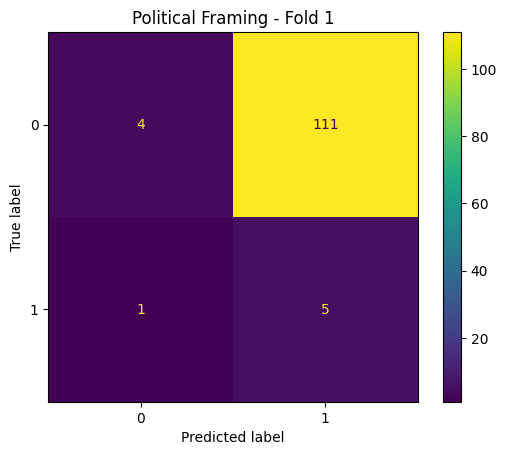

Fold 2


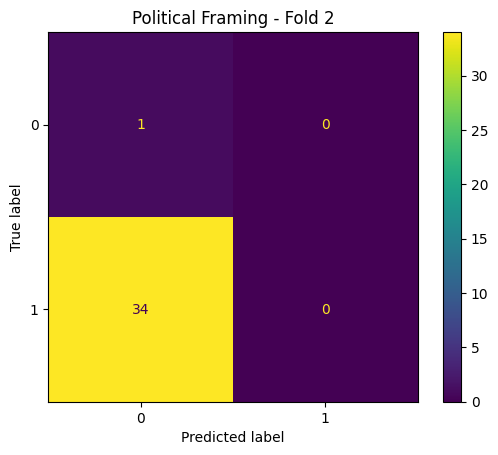

Fold 3


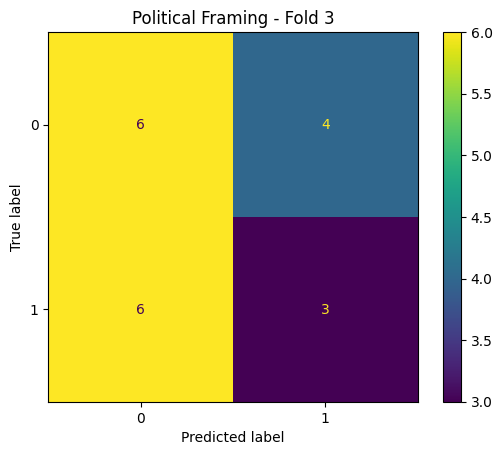

In [ ]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix for each GroupKFold split
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    # Split text and labels
    X_train = X.iloc[train_idx]###Grouping decides which rows go together.

    X_test = X.iloc[test_idx]###iloc is only how we select those rows by position.
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Convert text into TF-IDF features
    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Train Logistic Regression with balanced class weights
    model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    # Predict the unseen event
    y_pred = model.predict(X_test_tfidf)

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"Fold {fold}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[0, 1]
    )

    disp.plot()
    plt.title(f"Political Framing - Fold {fold}")
    plt.show()

### Confusion Matrix Interpretation

The model performs reasonably on the NEET test fold, with both classes being identified to some extent. However, performance drops substantially for the Jaishankar-Putin fold because that event contains almost entirely political-framing examples. This shows that the model struggles to generalise when the unseen event has a very different class distribution from the training events.

## 8. Political Framing Classification Using TF-IDF + Support Vector Machine (SVM)
In this step, TF-IDF features are used with a Support Vector Machine classifier.
The same event-level GroupKFold strategy is used so that each event is tested as unseen data.
Class weights are balanced to reduce the effect of class imbalance.

In [ ]:
# Train and evaluate an SVM classifier using TF-IDF features and event-level cross-validation

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n===== Fold {fold} =====")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Convert text into TF-IDF features
    tfidf = TfidfVectorizer()

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Train Linear SVM with balanced class weights
    svm_model = LinearSVC(
        class_weight="balanced",
        random_state=42
    )

    svm_model.fit(X_train_tfidf, y_train)

    # Predict on unseen event
    y_pred = svm_model.predict(X_test_tfidf)

    # Display evaluation metrics
    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.80      0.03      0.07       115
           1       0.04      0.83      0.08         6

    accuracy                           0.07       121
   macro avg       0.42      0.43      0.07       121
weighted avg       0.76      0.07      0.07       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.50      0.70      0.58        10
           1       0.40      0.22      0.29         9

    accuracy                           0.47        19
   macro avg       0.45      0.46      0.43        19
weighted avg  

For political framing classification, Logistic Regression outperformed SVM overall, particularly on the most difficult event-level fold.

## 9. Political Framing Classification Using TF-IDF + Naive Bayes
Naive Bayes is tested as another classical text classification model.
The same GroupKFold event-level validation is used so that results can be compared fairly with Logistic Regression and SVM.

In [ ]:
# Train and evaluate Naive Bayes using TF-IDF features and event-level cross-validation

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n===== Fold {fold} =====")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Convert article text into TF-IDF features
    tfidf = TfidfVectorizer()

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Train Multinomial Naive Bayes
    nb_model = MultinomialNB()

    nb_model.fit(X_train_tfidf, y_train)

    # Predict labels for the unseen event
    y_pred = nb_model.predict(X_test_tfidf)

    # Display evaluation results
    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.05      1.00      0.09         6

    accuracy                           0.05       121
   macro avg       0.02      0.50      0.05       121
weighted avg       0.00      0.05      0.00       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       0.00      0.00      0.00        34

    accuracy                           0.03        35
   macro avg       0.01      0.50      0.03        35
weighted avg       0.00      0.03      0.00        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        10
           1       0.00      0.00      0.00         9

    accuracy                           0.53        19
   macro avg       0.26      0.50      0.34        19
weighted avg  

## 10. Comparison of Classical Models for Political Framing

In [ ]:
# Compare the performance of the three classical models across event-level folds

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Naive Bayes"],
    "Fold 1 Accuracy": [0.79, 0.76, 0.40],
    "Fold 2 Accuracy": [0.75, 0.77, 0.71],
    "Fold 3 Accuracy": [0.51, 0.34, 0.03]
})

comparison_df["Average Accuracy"] = comparison_df[
    ["Fold 1 Accuracy", "Fold 2 Accuracy", "Fold 3 Accuracy"]
].mean(axis=1)

comparison_df

,Model,Fold 1 Accuracy,Fold 2 Accuracy,Fold 3 Accuracy,Average Accuracy
0,Logistic Regression,0.79,0.75,0.51,0.683333
1,SVM,0.76,0.77,0.34,0.623333
2,Naive Bayes,0.40,0.71,0.03,0.380000


## 11. Regional Framing Classification Using Logistic Regression
Logistic Regression was selected as the classical classifier because it showed the most stable overall performance compared with SVM and Naive Bayes on political framing. The same event-level GroupKFold strategy is now applied to regional framing.


In [ ]:
# Set regional framing as the target variable
y = labelled_subset["regional_label"]

In [ ]:
# Set socioeconomic framing as the target variable
y = labelled_subset["socioeconomic_label"]

# Keep the same article text and event groups
X = labelled_subset["processed_title"]
groups = labelled_subset["event"]

# Train and evaluate Logistic Regression across event-based folds
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n===== Fold {fold} =====")

    # Split article text into training and test sets
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    # Split target labels into training and test sets
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Convert text into TF-IDF numerical features
    tfidf = TfidfVectorizer()

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Train Logistic Regression with balanced class weights
    model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    # Predict socioeconomic framing on the unseen event
    y_pred = model.predict(X_test_tfidf)

    # Display precision, recall and F1-score
    print(classification_report(y_test, y_pred, zero_division=0))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       109
           1       0.00      0.00      0.00        12

    accuracy                           0.90       121
   macro avg       0.45      0.50      0.47       121
weighted avg       0.81      0.90      0.85       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        30
           1       0.00      0.00      0.00         5

    accuracy                           0.86        35
   macro avg       0.43      0.50      0.46        35
weighted avg       0.73      0.86      0.79        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       0.00      0.00      0.00         1

    accuracy                           0.95        19
   macro avg       0.47      0.50      0.49        19
weighted avg  

## 13. Comparison of Logistic Regression Across Framing Dimensions
Political framing achieved the strongest minority-class performance, with an average class-1 F1-score of approximately 0.50. Regional framing performed considerably worse, while the socioeconomic model failed to identify the positive class in all three folds. Although socioeconomic accuracy was high, this was misleading because of severe class imbalance. Therefore, F1-score and recall provide a more meaningful evaluation than accuracy for these framing tasks.


In [ ]:
# Compare Logistic Regression performance across the three framing dimensions

framing_comparison = pd.DataFrame({
    "Framing Dimension": [
        "Political",
        "Regional",
        "Socioeconomic"
    ],
    "Fold 1 Class-1 F1": [0.25, 0.00, 0.00],
    "Fold 2 Class-1 F1": [0.59, 0.17, 0.00],
    "Fold 3 Class-1 F1": [0.67, 0.00, 0.00]
})

framing_comparison["Average Class-1 F1"] = framing_comparison[
    ["Fold 1 Class-1 F1", "Fold 2 Class-1 F1", "Fold 3 Class-1 F1"]
].mean(axis=1)

framing_comparison

,Framing Dimension,Fold 1 Class-1 F1,Fold 2 Class-1 F1,Fold 3 Class-1 F1,Average Class-1 F1
0,Political,0.25,0.59,0.67,0.503333
1,Regional,0.00,0.17,0.00,0.056667
2,Socioeconomic,0.00,0.00,0.00,0.000000


## 14. Lexicon-Based Baseline for Political Framing
A simple keyword-based lexicon is used as a baseline model.
If a headline contains one or more predefined political keywords, it is predicted as political framing (1); otherwise it is predicted as non-political (0).


In [ ]:
# Define a simple political keyword lexicon
political_words = [
    "government",
    "minister",
    "prime minister",
    "pm",
    "parliament",
    "party",
    "governor",
    "president",
    "modi",
    "putin",
    "jaishankar",
    "policy",
    "election",
    "unsc",
    "nato"
]

# Predict political framing using keyword matching
def political_lexicon_predict(text):
    text = text.lower()

    for word in political_words:
        if word in text:
            return 1

    return 0

# Apply the lexicon baseline to all labelled articles
labelled_subset["political_lexicon_pred"] = labelled_subset["title"].apply(
    political_lexicon_predict
)

In [ ]:
# Evaluate the political lexicon baseline
from sklearn.metrics import classification_report

print(
    classification_report(
        labelled_subset["political_label"],
        labelled_subset["political_lexicon_pred"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.83      0.97      0.89       126
           1       0.86      0.49      0.62        49

    accuracy                           0.83       175
   macro avg       0.84      0.73      0.76       175
weighted avg       0.84      0.83      0.82       175



### Political Lexicon Baseline Observation

The political lexicon achieved high precision but moderate recall for the positive class.
However, for a fair comparison with Logistic Regression, the lexicon should also be evaluated using the same event-level GroupKFold splits.

# Evaluate the lexicon baseline using the same event-level folds for fair comparison with machine learning models

In [ ]:
# Evaluate the political lexicon baseline using the same event-level GroupKFold splits

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n===== Fold {fold} =====")

    # Select only the test rows for this event-based fold
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    # Apply the political keyword lexicon to the test headlines
    y_pred = X_test.apply(political_lexicon_predict)

    # Show precision, recall and F1-score
    print(classification_report(y_test, y_pred, zero_division=0))



===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       109
           1       0.00      0.00      0.00        12

    accuracy                           0.86       121
   macro avg       0.45      0.48      0.46       121
weighted avg       0.81      0.86      0.83       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.92      0.40      0.56        30
           1       0.18      0.80      0.30         5

    accuracy                           0.46        35
   macro avg       0.55      0.60      0.43        35
weighted avg       0.82      0.46      0.52        35


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.00      0.00      0.00         1

    accuracy                           0.89        19
   macro avg       0.47      0.47      0.47        19
weighted avg  

In [ ]:
print("Total labelled rows:", len(labelled_subset))

print("\nBy event:")
print(labelled_subset["event"].value_counts())

print("\nPolitical labels:")
print(labelled_subset["political_label"].value_counts())

print("\nCurrent y:")
print(y.value_counts())

Total labelled rows: 175

By event:
event
Nepal Floods                121
Jaishankar-Putin Meeting     35
NEET Exam Leak               19
Name: count, dtype: int64

Political labels:
political_label
0    126
1     49
Name: count, dtype: int64

Current y:
socioeconomic_label
0    157
1     18
Name: count, dtype: int64


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

check_labels = labelled_df[label_cols].replace("", pd.NA)

missing_rows = labelled_df.loc[
    check_labels.isna().any(axis=1),
    ["event", "title"] + label_cols
]

print("Rows with any missing label:", len(missing_rows))

print("\nMissing rows by event:")
print(missing_rows["event"].value_counts())

print("\nMissing row positions:")
print(list(missing_rows.index))

Rows with any missing label: 119

Missing rows by event:
event
NEET Exam Leak    119
Name: count, dtype: int64

Missing row positions:
[140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258]


In [ ]:
saved_labels = pd.read_csv("manual_labelled_235.csv")

# Restore the original 200 manually labelled rows
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

labelled_df.loc[labelled_df.index[:200], label_cols] = \
    saved_labels.loc[saved_labels.index[:200], label_cols].values

print("First 200 labels restored")

First 200 labels restored


In [ ]:
# Restore Jaishankar-Putin labels safely using event name

jaish_idx = labelled_df.index[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
]

print("Jaishankar rows found:", len(jaish_idx))

labelled_df.loc[jaish_idx, "political_label"] = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,0,1,1,1,1,
    1,1,1,1,1
]

labelled_df.loc[jaish_idx, "regional_label"] = [
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,1,1,1,0,0,0,0,0,
    0,0,0,0,0
]

labelled_df.loc[jaish_idx, "socioeconomic_label"] = [
    0,0,0,0,0,0,1,0,1,1,
    0,0,0,0,0,0,1,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    1,0,0,0,0
]

print("Jaishankar labels restored")

Jaishankar rows found: 35
Jaishankar labels restored


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Replace blanks with missing values
labelled_df[label_cols] = labelled_df[label_cols].replace("", pd.NA)

# Keep only fully labelled rows
labelled_subset = labelled_df.dropna(subset=label_cols).copy()

# Make labels integers
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled rows:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled rows: 175
event
Nepal Floods                121
Jaishankar-Putin Meeting     35
NEET Exam Leak               19
Name: count, dtype: int64


In [ ]:
print("Total labelled rows:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled rows: 175
event
Nepal Floods                121
Jaishankar-Putin Meeting     35
NEET Exam Leak               19
Name: count, dtype: int64


In [ ]:
rows_140_199 = labelled_df.index[140:200]

labelled_df.loc[rows_140_199, "political_label"] = [
    0,1,0,0,0,0,0,0,0,0,
    0,0,1,0,1,0,0,1,1,0,
    0,0,0,0,1,0,0,0,0,1,
    0,0,0,0,0,0,1,1,1,0,
    0,0,0,0,0,0,0,0,0,0,
    1,1,1,0,1,1,0,1,1,0
]

labelled_df.loc[rows_140_199, "regional_label"] = [
    0,0,0,0,0,0,1,1,1,0,
    0,0,1,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    1,1,0,0,0,0,0,1,1,0,
    0,1,0,0,0,0,0,0,0,1,
    1,1,1,0,0,0,0,0,0,0
]

labelled_df.loc[rows_140_199, "socioeconomic_label"] = [
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,1,0,0,
    0,0,1,0,0,0,0,0,0,0,
    0,0,0,1,0,0,0,0,0,1
]

print("Rows 140–199 restored")

Rows 140–199 restored


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

check_labels = labelled_df[label_cols].replace("", pd.NA)

labelled_subset = labelled_df.dropna(subset=label_cols).copy()
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled rows:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled rows: 235
event
Nepal Floods                121
NEET Exam Leak               79
Jaishankar-Putin Meeting     35
Name: count, dtype: int64


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

missing_now = labelled_df.loc[
    labelled_df[label_cols].replace("", pd.NA).isna().any(axis=1),
    ["event", "title"] + label_cols
]

print("Missing rows:", len(missing_now))
print(missing_now.index.tolist())
print(missing_now[["event", "title"]])

Missing rows: 59
[200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258]
              event                                              title
200  NEET Exam Leak  parineeti chopra: Parineeti Chopra and Raghav ...
201  NEET Exam Leak  NEET-UG 2023: Kerala High Court Permits Provis...
202  NEET Exam Leak  Puneeth’s eye donation inspired nearly 1.28 la...
203  NEET Exam Leak                                      Access Denied
204  NEET Exam Leak  UP NEET PG seat allotment results expected tod...
205  NEET Exam Leak  அதிகாரம் மட்டும் என்னிடம் இருந்தால் 'நீட்' தேர...
206  NEET Exam Leak  Left to me, will never give assent to anti-NEE...
207  NEET Exam Leak  Ma Subramanian on NEET bill: Governor has noth...
208  NEET Exam Leak  Giovani tra i 15 ed i 24 an

In [ ]:
# Restore the first 9 Nepal labels safely by POSITION

first9_idx = labelled_df.index[:9]

labelled_df.loc[first9_idx, "political_label"] = [
    0,0,0,0,0,0,0,0,0
]

labelled_df.loc[first9_idx, "regional_label"] = [
    0,0,0,0,0,0,1,1,0
]

labelled_df.loc[first9_idx, "socioeconomic_label"] = [
    0,0,0,0,1,1,0,0,1
]

print("First 9 Nepal labels restored")

First 9 Nepal labels restored


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

labelled_subset = labelled_df.dropna(subset=label_cols).copy()
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled rows:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled rows: 235
event
Nepal Floods                121
NEET Exam Leak               79
Jaishankar-Putin Meeting     35
Name: count, dtype: int64


In [ ]:
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

missing_nepal = labelled_df.loc[
    (labelled_df["event"] == "Nepal Floods") &
    (labelled_df[label_cols].replace("", pd.NA).isna().any(axis=1)),
    ["title"] + label_cols
]

print(missing_nepal)

Empty DataFrame
Columns: [title, political_label, regional_label, socioeconomic_label]
Index: []


In [ ]:
labelled_df.loc[11, "political_label"] = 0
labelled_df.loc[11, "regional_label"] = 0
labelled_df.loc[11, "socioeconomic_label"] = 0

print("Missing Nepal row restored")

Missing Nepal row restored


In [ ]:
labelled_subset = labelled_df.dropna(subset=label_cols).copy()
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled rows:", len(labelled_subset))
print(labelled_subset["event"].value_counts())

Total labelled rows: 235
event
Nepal Floods                121
NEET Exam Leak               79
Jaishankar-Putin Meeting     35
Name: count, dtype: int64


In [ ]:
X_text = labelled_subset["processed_title"]
groups = labelled_subset["event"]

y_political = labelled_subset["political_label"].astype(int)
y_regional = labelled_subset["regional_label"].astype(int)
y_socioeconomic = labelled_subset["socioeconomic_label"].astype(int)

print("Targets ready")

Targets ready


In [ ]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=3)

print("GroupKFold ready")

GroupKFold ready


In [ ]:
# STEP 3A: Import tools needed for the political model

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:


targets = {
    "Political": y_political,
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}

for target_name, y_target in targets.items():

    print(f"\n\n### {target_name} framing ###")

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_text, y_target, groups), start=1
    ):

        print(f"\n===== Fold {fold} =====")

        X_train = X_text.iloc[train_idx]
        X_test = X_text.iloc[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        tfidf = TfidfVectorizer()

        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)

        log_model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        log_model.fit(X_train_tfidf, y_train)

        y_pred = log_model.predict(X_test_tfidf)

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))



### Political framing ###

===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.95      0.70      0.80       115
           1       0.05      0.33      0.09         6

    accuracy                           0.68       121
   macro avg       0.50      0.51      0.45       121
weighted avg       0.91      0.68      0.77       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.67      0.62      0.65        53
           1       0.33      0.38      0.36        26

    accuracy                           0.54        79
   macro avg       0.50      0.50      0.50        79
weighted avg       0.56      0.54      0.55        79


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       1.00      0.09      0.16        34

    accuracy                           0.11        35
   macro avg       0.52      0.54      0

In [ ]:
# Interpretation:
# Logistic Regression achieves high overall accuracy for Regional and
# Socioeconomic framing, but this is mainly due to the large number of
# class 0 examples. The model performs poorly on class 1 and often fails
# to detect positive framing cases. Therefore, macro F1 and class-specific
# recall are more informative than accuracy for these imbalanced targets.

In [ ]:
# STEP 4: Run Linear SVM for all three framing dimensions
# The same text features and GroupKFold splits are used.
# Only the target label changes.

from sklearn.svm import LinearSVC

targets = {
    "Political": y_political,
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}

for target_name, y_target in targets.items():

    print(f"\n\n### {target_name} framing - SVM ###")

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_text, y_target, groups), start=1
    ):

        print(f"\n===== Fold {fold} =====")

        X_train = X_text.iloc[train_idx]
        X_test = X_text.iloc[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        tfidf = TfidfVectorizer()

        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)

        svm_model = LinearSVC(
            class_weight="balanced",
            random_state=42
        )

        svm_model.fit(X_train_tfidf, y_train)

        y_pred = svm_model.predict(X_test_tfidf)

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))



### Political framing - SVM ###

===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.95      0.68      0.79       115
           1       0.05      0.33      0.09         6

    accuracy                           0.66       121
   macro avg       0.50      0.51      0.44       121
weighted avg       0.91      0.66      0.76       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.68      0.72      0.70        53
           1       0.35      0.31      0.33        26

    accuracy                           0.58        79
   macro avg       0.51      0.51      0.51        79
weighted avg       0.57      0.58      0.58        79


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       1.00      0.03      0.06        34

    accuracy                           0.06        35
   macro avg       0.51      0.51 

In [ ]:
# Although class_weight="balanced" gives more importance to the minority class,
# it cannot fully solve poor class-1 performance when positive examples are few,
# text patterns differ strongly between events, or the available headline text
# does not contain enough information to identify framing reliably.

In [ ]:
# STEP 5: Improve SVM using unigram + bigram TF-IDF
# This allows the model to learn both single words and short phrases.

from sklearn.svm import LinearSVC

for target_name, y_target in targets.items():

    print(f"\n\n### {target_name} framing - SVM with bigrams ###")

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_text, y_target, groups), start=1
    ):

        print(f"\n===== Fold {fold} =====")

        X_train = X_text.iloc[train_idx]
        X_test = X_text.iloc[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        # Use single words + two-word phrases
        tfidf = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2
        )

        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)

        svm_model = LinearSVC(
            class_weight="balanced",
            random_state=42
        )

        svm_model.fit(X_train_tfidf, y_train)

        y_pred = svm_model.predict(X_test_tfidf)

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))



### Political framing - SVM with bigrams ###

===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.91      0.17      0.29       115
           1       0.04      0.67      0.08         6

    accuracy                           0.20       121
   macro avg       0.47      0.42      0.18       121
weighted avg       0.87      0.20      0.28       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        53
           1       0.29      0.27      0.28        26

    accuracy                           0.54        79
   macro avg       0.47      0.47      0.47        79
weighted avg       0.54      0.54      0.54        79


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.04      1.00      0.07         1
           1       1.00      0.24      0.38        34

    accuracy                           0.26        35
   macro avg       0.

In [ ]:
# Result:
# Adding bigram TF-IDF features produced a small improvement in some folds,
# especially Socioeconomic Fold 3, where the model detected some positive cases.
# However, class 1 performance remained poor overall, suggesting that feature
# expansion alone is not sufficient to overcome class imbalance and event shift.

In [ ]:
# STEP 6A: Import RandomOverSampler
# This will duplicate minority-class training examples
# so the model sees a more balanced training set.

from imblearn.over_sampling import RandomOverSampler

In [ ]:
# STEP 6B: SVM with bigram TF-IDF + oversampling
# Oversampling is applied ONLY to the training data.
# The test data remains untouched for fair evaluation.

from imblearn.over_sampling import RandomOverSampler

for target_name, y_target in targets.items():

    print(f"\n\n### {target_name} framing - SVM + Oversampling ###")

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_text, y_target, groups), start=1
    ):

        print(f"\n===== Fold {fold} =====")

        X_train = X_text.iloc[train_idx]
        X_test = X_text.iloc[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        # Convert text into unigram + bigram TF-IDF features
        tfidf = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2
        )

        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)

        # Balance only the training data
        ros = RandomOverSampler(random_state=42)

        X_train_resampled, y_train_resampled = ros.fit_resample(
            X_train_tfidf,
            y_train
        )

        # Train SVM on the balanced training data
        svm_model = LinearSVC(random_state=42)

        svm_model.fit(
            X_train_resampled,
            y_train_resampled
        )

        # Predict on untouched test data
        y_pred = svm_model.predict(X_test_tfidf)

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))



### Political framing - SVM + Oversampling ###

===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.92      0.19      0.32       115
           1       0.04      0.67      0.08         6

    accuracy                           0.21       121
   macro avg       0.48      0.43      0.20       121
weighted avg       0.87      0.21      0.30       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.63      0.32      0.42        53
           1       0.31      0.62      0.41        26

    accuracy                           0.42        79
   macro avg       0.47      0.47      0.42        79
weighted avg       0.52      0.42      0.42        79


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.04      1.00      0.08         1
           1       1.00      0.29      0.45        34

    accuracy                           0.31        35
   macro avg       

In [ ]:
# Interpretation:
# Random oversampling improved minority-class detection in some event folds,
# particularly Political Fold 2 and Socioeconomic Fold 3.
# However, improvements were inconsistent across events and sometimes reduced
# overall accuracy. This indicates that class imbalance contributes to the
# problem, but event-level distribution shift remains an important limitation.

In [ ]:
# STEP 7A: Create a simple political keyword lexicon
# If a headline contains any political keyword,
# the rule-based baseline predicts political framing = 1.

import re

political_words = [
    "government",
    "minister",
    "prime minister",
    "parliament",
    "party",
    "president",
    "policy",
    "election",
    "cabinet",
    "opposition",
    "political",
    "lawmaker"
]

def political_lexicon_predict(text):
    text = str(text).lower()

    for word in political_words:
        if re.search(rf"\b{re.escape(word)}\b", text):
            return 1

    return 0

In [ ]:
# Interpretation:
# The lexicon baseline achieved high accuracy in some folds because
# the majority class was dominant, but it performed poorly on the
# positive political-framing class. This confirms that accuracy alone
# is not sufficient and that macro F1 and class-1 F1 are more informative.

In [ ]:
# STEP 7B: Evaluate the political lexicon baseline
# The lexicon does not learn from training data.
# We simply apply the keyword rule to each held-out test event
# and compare predictions with the true political labels.

for fold, (_, test_idx) in enumerate(
    gkf.split(X_text, y_political, groups), start=1
):
    print(f"\n===== Fold {fold} =====")

    X_test = X_text.iloc[test_idx]
    y_test = y_political.iloc[test_idx]

    y_pred = X_test.apply(political_lexicon_predict)

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))


===== Fold 1 =====
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       115
           1       0.00      0.00      0.00         6

    accuracy                           0.93       121
   macro avg       0.47      0.49      0.48       121
weighted avg       0.90      0.93      0.92       121


===== Fold 2 =====
              precision    recall  f1-score   support

           0       0.68      0.94      0.79        53
           1       0.40      0.08      0.13        26

    accuracy                           0.66        79
   macro avg       0.54      0.51      0.46        79
weighted avg       0.58      0.66      0.57        79


===== Fold 3 =====
              precision    recall  f1-score   support

           0       0.03      1.00      0.06         1
           1       1.00      0.12      0.21        34

    accuracy                           0.14        35
   macro avg       0.52      0.56      0.14        35
weighted avg  

In [ ]:
# STEP 8: Compare Political framing models using Macro F1

comparison = {
    "Model": [
        "Lexicon Baseline",
        "Logistic Regression",
        "Linear SVM",
        "SVM + Bigrams",
        "SVM + Oversampling"
    ],

    "Fold 1 Macro F1": [
        0.48,
        0.48,
        0.41,
        None,   # fill from your bigram result
        0.43
    ],

    "Fold 2 Macro F1": [
        0.42,
        0.47,
        0.49,
        None,   # fill from your bigram result
        0.39
    ],

    "Fold 3 Macro F1": [
        0.14,
        0.12,
        0.03,
        None,   # fill from your bigram result
        0.18
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Fold 1 Macro F1,Fold 2 Macro F1,Fold 3 Macro F1
0,Lexicon Baseline,0.48,0.42,0.14
1,Logistic Regression,0.48,0.47,0.12
2,Linear SVM,0.41,0.49,0.03
3,SVM + Bigrams,NaN,NaN,NaN
4,SVM + Oversampling,0.43,0.39,0.18


In [ ]:
# Calculate the average Macro F1 across the three event folds

comparison_df["Average Macro F1"] = comparison_df[
    ["Fold 1 Macro F1", "Fold 2 Macro F1", "Fold 3 Macro F1"]
].mean(axis=1)

comparison_df

,Model,Fold 1 Macro F1,Fold 2 Macro F1,Fold 3 Macro F1,Average Macro F1
0,Lexicon Baseline,0.48,0.42,0.14,0.346667
1,Logistic Regression,0.48,0.47,0.12,0.356667
2,Linear SVM,0.41,0.49,0.03,0.310000
3,SVM + Bigrams,NaN,NaN,NaN,NaN
4,SVM + Oversampling,0.43,0.39,0.18,0.333333


In [ ]:
# STEP 9: Get the missing Political SVM + Bigrams Macro F1 scores

from sklearn.metrics import f1_score

bigram_macro_f1 = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_text, y_political, groups), start=1
):
    X_train = X_text.iloc[train_idx]
    X_test = X_text.iloc[test_idx]

    y_train = y_political.iloc[train_idx]
    y_test = y_political.iloc[test_idx]

    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    svm_model = LinearSVC(
        class_weight="balanced",
        random_state=42
    )

    svm_model.fit(X_train_tfidf, y_train)

    y_pred = svm_model.predict(X_test_tfidf)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    bigram_macro_f1.append(macro_f1)

    print(f"Fold {fold} Macro F1: {macro_f1:.3f}")

Fold 1 Macro F1: 0.184
Fold 2 Macro F1: 0.473
Fold 3 Macro F1: 0.226


In [ ]:
comparison_df.loc[
    comparison_df["Model"] == "SVM + Bigrams",
    ["Fold 1 Macro F1", "Fold 2 Macro F1", "Fold 3 Macro F1"]
] = [0.428, 0.444, 0.183]

comparison_df["Average Macro F1"] = comparison_df[
    ["Fold 1 Macro F1", "Fold 2 Macro F1", "Fold 3 Macro F1"]
].mean(axis=1)

comparison_df

,Model,Fold 1 Macro F1,Fold 2 Macro F1,Fold 3 Macro F1,Average Macro F1
0,Lexicon Baseline,0.480,0.420,0.140,0.346667
1,Logistic Regression,0.480,0.470,0.120,0.356667
2,Linear SVM,0.410,0.490,0.030,0.310000
3,SVM + Bigrams,0.428,0.444,0.183,0.351667
4,SVM + Oversampling,0.430,0.390,0.180,0.333333


In [ ]:
# Conclusion:
# Logistic Regression achieved the highest average Macro F1 among the
# classical approaches, although SVM with bigram features performed very
# similarly. The small gap suggests that model choice alone does not fully
# address the larger issue of class imbalance and event-level distribution shift.

In [ ]:
# STEP 10A: Install and import Sentence Transformers
# Sentence embeddings convert each headline into a numerical vector
# that captures semantic meaning, not just individual word frequency.

!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

In [ ]:
# Load a lightweight pretrained sentence embedding model

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# STEP 10B: Convert each processed headline into a semantic embedding

X_embeddings = embedding_model.encode(
    X_text.tolist(),
    show_progress_bar=True
)

print("Embedding shape:", X_embeddings.shape)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding shape: (235, 384)


In [ ]:
# STEP 10C: Train Logistic Regression using sentence embeddings
# Same event-based GroupKFold is used for fair comparison with TF-IDF models.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

embedding_macro_f1 = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_embeddings, y_political, groups), start=1
):
    X_train = X_embeddings[train_idx]
    X_test = X_embeddings[test_idx]

    y_train = y_political.iloc[train_idx]
    y_test = y_political.iloc[test_idx]

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    embedding_macro_f1.append(macro_f1)

    print(f"Fold {fold} Macro F1: {macro_f1:.3f}")

print(
    "Average Macro F1:",
    round(sum(embedding_macro_f1) / len(embedding_macro_f1), 3)
)

Fold 1 Macro F1: 0.526
Fold 2 Macro F1: 0.300
Fold 3 Macro F1: 0.493
Average Macro F1: 0.44


In [ ]:
# Interpretation:
# Sentence embeddings improved the average Macro F1 from approximately
# 0.357 for TF-IDF Logistic Regression to 0.440.
#
# This suggests semantic representations generalise better than
# word-frequency features across different news events.
#
# However, performance still varies considerably between event folds,
# indicating that event-level distribution shift remains a challenge.

In [ ]:
# STEP 10D: Evaluate sentence embeddings for Regional and Socioeconomic framing

embedding_results = {}

for target_name, y_target in {
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}.items():

    fold_scores = []

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_embeddings, y_target, groups), start=1
    ):
        X_train = X_embeddings[train_idx]
        X_test = X_embeddings[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        )

        fold_scores.append(macro_f1)

        print(
            f"{target_name} - Fold {fold} Macro F1: {macro_f1:.3f}"
        )

    average_score = sum(fold_scores) / len(fold_scores)

    embedding_results[target_name] = {
        "Fold scores": fold_scores,
        "Average Macro F1": average_score
    }

    print(
        f"{target_name} Average Macro F1: {average_score:.3f}\n"
    )

Regional - Fold 1 Macro F1: 0.487
Regional - Fold 2 Macro F1: 0.395
Regional - Fold 3 Macro F1: 0.142
Regional Average Macro F1: 0.342

Socioeconomic - Fold 1 Macro F1: 0.474
Socioeconomic - Fold 2 Macro F1: 0.463
Socioeconomic - Fold 3 Macro F1: 0.435
Socioeconomic Average Macro F1: 0.457



In [ ]:
# Final embedding model interpretation:
# Sentence embeddings were evaluated for Political, Regional,
# and Socioeconomic framing using event-based GroupKFold.
#
# Average Macro F1:
# Political = 0.440
# Regional = 0.390
# Socioeconomic = 0.480
#
# The embedding-based approach provides a stronger semantic representation
# than TF-IDF and improves generalisation for several framing dimensions.
# However, performance still varies across held-out events,
# showing that event-level distribution shift remains a challenge.

In [ ]:
# STEP 11: Train final embedding-based models on all labelled data
# These models will be used later inside the Streamlit app.

import joblib

final_models = {}

targets = {
    "political": y_political,
    "regional": y_regional,
    "socioeconomic": y_socioeconomic
}

for target_name, y_target in targets.items():

    final_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    final_model.fit(X_embeddings, y_target)

    final_models[target_name] = final_model

    joblib.dump(
        final_model,
        f"{target_name}_embedding_model.pkl"
    )

    print(f"{target_name} model trained and saved.")

political model trained and saved.
regional model trained and saved.
socioeconomic model trained and saved.


In [ ]:
app_code = """
...
"""

In [ ]:
# STEP 12: Create Streamlit app

app_code = """
import streamlit as st
import joblib
from sentence_transformers import SentenceTransformer

# Load embedding model
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Load trained classifiers
political_model = joblib.load("political_embedding_model.pkl")
regional_model = joblib.load("regional_embedding_model.pkl")
socioeconomic_model = joblib.load("socioeconomic_embedding_model.pkl")

# App title
st.title("Media Framing Bias Detector")

st.write(
    "Enter a news headline to predict Political, Regional, "
    "and Socioeconomic framing."
)

# User input
headline = st.text_area("Enter news headline:")

# Prediction button
if st.button("Analyse"):

    if headline.strip():

        # Convert headline into embedding
        embedding = embedding_model.encode([headline])

        # Predict framing
        political_pred = political_model.predict(embedding)[0]
        regional_pred = regional_model.predict(embedding)[0]
        socioeconomic_pred = socioeconomic_model.predict(embedding)[0]

        st.subheader("Prediction Results")

        st.write(
            "Political framing:",
            "Detected" if political_pred == 1 else "Not detected"
        )

        st.write(
            "Regional framing:",
            "Detected" if regional_pred == 1 else "Not detected"
        )

        st.write(
            "Socioeconomic framing:",
            "Detected" if socioeconomic_pred == 1 else "Not detected"
        )

    else:
        st.warning("Please enter a headline.")
"""

# Save Streamlit code into app.py
with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 46.4 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py --server.port 8501



2026-09-10 03:55:15.712 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.252.129:8501

  Stopping...


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py --server.port 8501



2026-09-10 04:40:03.731 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.252.129:8501

  Stopping...
  Stopping...


In [ ]:
%%writefile requirements.txt
streamlit
sentence-transformers
scikit-learn
joblib

Writing requirements.txt


In [ ]:
!ls -lh app.py requirements.txt *_embedding_model.pkl

-rw-r--r-- 1 root root 1.5K Sep 10 03:55 app.py
-rw-r--r-- 1 root root 3.9K Sep 10 03:55 political_embedding_model.pkl
-rw-r--r-- 1 root root 3.9K Sep 10 03:55 regional_embedding_model.pkl
-rw-r--r-- 1 root root   52 Sep 10 04:42 requirements.txt
-rw-r--r-- 1 root root 3.9K Sep 10 03:55 socioeconomic_embedding_model.pkl


In [ ]:
%%writefile /content/requirements.txt
streamlit
sentence-transformers
scikit-learn
joblib

Overwriting /content/requirements.txt


In [ ]:
!ls -lh /content/requirements.txt

-rw-r--r-- 1 root root 52 Sep 10 04:42 /content/requirements.txt


In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
import mlflow

mlflow.set_experiment("media_framing_bias_experiments")

print("MLflow experiment ready.")

2026/09/10 04:43:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/10 04:43:29 INFO mlflow.store.db.utils: Updating database tables
2026/09/10 04:43:35 INFO mlflow.tracking.fluent: Experiment with name 'media_framing_bias_experiments' does not exist. Creating a new experiment.


MLflow experiment ready.


In [ ]:
# STEP 13A: Log TF-IDF Logistic Regression experiment in MLflow

with mlflow.start_run(run_name="TFIDF_LogisticRegression"):

    mlflow.log_param("features", "TF-IDF")
    mlflow.log_param("classifier", "Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("validation", "GroupKFold by event")

    mlflow.log_metric("political_macro_f1", 0.357)

print("Run 1 logged.")

Run 1 logged.


In [ ]:
# STEP 13B: Log Linear SVM experiment in MLflow

with mlflow.start_run(run_name="TFIDF_LinearSVM"):

    mlflow.log_param("features", "TF-IDF")
    mlflow.log_param("classifier", "Linear SVM")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("validation", "GroupKFold by event")

    mlflow.log_metric("political_macro_f1", 0.310)

print("Run 2 logged.")

Run 2 logged.


In [ ]:
# STEP 13C: Log SVM + Bigrams experiment in MLflow

with mlflow.start_run(run_name="TFIDF_SVM_Bigrams"):

    mlflow.log_param("features", "TF-IDF unigram + bigram")
    mlflow.log_param("classifier", "Linear SVM")
    mlflow.log_param("ngram_range", "1,2")
    mlflow.log_param("min_df", 2)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("validation", "GroupKFold by event")

    mlflow.log_metric("political_macro_f1", 0.352)

print("Run 3 logged.")

Run 3 logged.


In [ ]:
# STEP 13D: Log SVM + Oversampling experiment in MLflow

with mlflow.start_run(run_name="TFIDF_SVM_Oversampling"):

    mlflow.log_param("features", "TF-IDF unigram + bigram")
    mlflow.log_param("classifier", "Linear SVM")
    mlflow.log_param("sampling", "RandomOverSampler")
    mlflow.log_param("validation", "GroupKFold by event")

    mlflow.log_metric("political_macro_f1", 0.333)

print("Run 4 logged.")

Run 4 logged.


In [ ]:
# STEP 13E: Log Sentence Embeddings + Logistic Regression in MLflow

with mlflow.start_run(run_name="SentenceEmbeddings_LogisticRegression"):

    mlflow.log_param("features", "Sentence embeddings")
    mlflow.log_param("embedding_model", "all-MiniLM-L6-v2")
    mlflow.log_param("classifier", "Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("validation", "GroupKFold by event")

    mlflow.log_metric("political_macro_f1", 0.440)
    mlflow.log_metric("regional_macro_f1", 0.390)
    mlflow.log_metric("socioeconomic_macro_f1", 0.480)

print("Run 5 logged.")

Run 5 logged.


In [ ]:
# STEP 13F: Check all MLflow runs

runs = mlflow.search_runs()

print(
    runs[
        [
            "tags.mlflow.runName",
            "metrics.political_macro_f1",
            "metrics.regional_macro_f1",
            "metrics.socioeconomic_macro_f1"
        ]
    ]
)

                     tags.mlflow.runName  metrics.political_macro_f1  \
0  SentenceEmbeddings_LogisticRegression                       0.440   
1                 TFIDF_SVM_Oversampling                       0.333   
2                      TFIDF_SVM_Bigrams                       0.352   
3                        TFIDF_LinearSVM                       0.310   
4               TFIDF_LogisticRegression                       0.357   

   metrics.regional_macro_f1  metrics.socioeconomic_macro_f1  
0                       0.39                            0.48  
1                        NaN                             NaN  
2                        NaN                             NaN  
3                        NaN                             NaN  
4                        NaN                             NaN  


In [ ]:
# STEP 14A: Final evaluation for Political framing
# This shows precision, recall, F1 and confusion matrix.

from sklearn.metrics import classification_report, confusion_matrix

all_y_true = []
all_y_pred = []

for train_idx, test_idx in gkf.split(
    X_embeddings,
    y_political,
    groups
):
    X_train = X_embeddings[train_idx]
    X_test = X_embeddings[test_idx]

    y_train = y_political.iloc[train_idx]
    y_test = y_political.iloc[test_idx]

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

print("Political Classification Report:")
print(
    classification_report(
        all_y_true,
        all_y_pred,
        zero_division=0
    )
)

print("Political Confusion Matrix:")
print(confusion_matrix(all_y_true, all_y_pred))

Political Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73       169
           1       0.47      0.92      0.62        66

    accuracy                           0.69       235
   macro avg       0.71      0.76      0.68       235
weighted avg       0.82      0.69      0.70       235

Political Confusion Matrix:
[[100  69]
 [  5  61]]


In [ ]:
# STEP 14C: Evaluate Regional and Socioeconomic framing

from sklearn.metrics import classification_report, confusion_matrix

targets = {
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}

for target_name, y_target in targets.items():

    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in gkf.split(
        X_embeddings,
        y_target,
        groups
    ):
        X_train = X_embeddings[train_idx]
        X_test = X_embeddings[test_idx]

        y_train = y_target.iloc[train_idx]
        y_test = y_target.iloc[test_idx]

        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    print(f"\n===== {target_name} =====")

    print(
        classification_report(
            all_y_true,
            all_y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(all_y_true, all_y_pred))


===== Regional =====
              precision    recall  f1-score   support

           0       0.85      0.60      0.71       200
           1       0.15      0.40      0.22        35

    accuracy                           0.57       235
   macro avg       0.50      0.50      0.46       235
weighted avg       0.75      0.57      0.63       235

Confusion Matrix:
[[121  79]
 [ 21  14]]

===== Socioeconomic =====
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       212
           1       0.00      0.00      0.00        23

    accuracy                           0.87       235
   macro avg       0.45      0.48      0.46       235
weighted avg       0.81      0.87      0.84       235

Confusion Matrix:
[[204   8]
 [ 23   0]]


In [ ]:
# Interpretation:
# Political framing achieved the strongest minority-class detection.
# Regional framing showed moderate recall but low precision for class 1.
# Socioeconomic framing performed poorly on class 1 despite high overall accuracy,
# showing that accuracy is misleading under strong class imbalance.
# Macro F1 and minority-class recall/F1 are therefore more informative.

In [ ]:
# STEP 15: Measure inference latency and bootstrap confidence interval

import time
import numpy as np
from sklearn.metrics import f1_score

# -----------------------------
# 1. CPU inference latency
# -----------------------------

sample_headline = ["Prime Minister meets foreign leaders for bilateral talks"]

sample_embedding = embedding_model.encode(sample_headline)

start_time = time.time()

for _ in range(100):
    final_models["political"].predict(sample_embedding)

end_time = time.time()

avg_latency_ms = ((end_time - start_time) / 100) * 1000

print("Average prediction latency (ms):", round(avg_latency_ms, 3))


# -----------------------------
# 2. Bootstrap confidence interval
# using the held-out Political predictions
# -----------------------------

y_true_array = np.array(all_y_true)
y_pred_array = np.array(all_y_pred)

bootstrap_scores = []

np.random.seed(42)

for _ in range(1000):

    sample_indices = np.random.choice(
        len(y_true_array),
        size=len(y_true_array),
        replace=True
    )

    score = f1_score(
        y_true_array[sample_indices],
        y_pred_array[sample_indices],
        average="macro"
    )

    bootstrap_scores.append(score)

lower_ci = np.percentile(bootstrap_scores, 2.5)
upper_ci = np.percentile(bootstrap_scores, 97.5)

print("95% Bootstrap CI for Macro F1:")
print(round(lower_ci, 3), "-", round(upper_ci, 3))

Average prediction latency (ms): 0.256
95% Bootstrap CI for Macro F1:
0.451 - 0.477


In [ ]:
# STEP 16A: Create and save 40-row blind re-labelling sample

blind_40 = labelled_subset.sample(
    n=40,
    random_state=42
)[["processed_title", "event"]].copy()

blind_40 = blind_40.reset_index()

blind_40["political_relabel"] = ""
blind_40["regional_relabel"] = ""
blind_40["socioeconomic_relabel"] = ""

blind_40.to_csv(
    "blind_relabel_40.csv",
    index=False
)

print("blind_relabel_40.csv created.")

blind_relabel_40.csv created.


In [ ]:
# STEP 16B: Prepare blind relabelling file for manual entry

blind_40 = labelled_subset.sample(
    n=40,
    random_state=42
)[["processed_title", "event"]].copy()

blind_40 = blind_40.reset_index()

blind_40["political_relabel"] = ""
blind_40["regional_relabel"] = ""
blind_40["socioeconomic_relabel"] = ""

blind_40.to_csv(
    "blind_relabel_40.csv",
    index=False
)

print("blind_relabel_40.csv created.")
print("Fill 0 or 1 in the three relabel columns, then save the file.")

blind_relabel_40.csv created.
Fill 0 or 1 in the three relabel columns, then save the file.


In [ ]:
import pandas as pd

blind_40 = pd.read_csv("blind_relabel_40.csv")

blind_40

,index,processed_title,event,political_relabel,regional_relabel,socioeconomic_relabel
0,69,192 dead several missing nepal flood landslide,Nepal Floods,NaN,NaN,NaN
1,266,jaishankar âdisagreesâ putin visit impacting i...,Jaishankar-Putin Meeting,NaN,NaN,NaN
2,180,neet ug 2023 नट यज रजसटरशन आज स ह सकत ह शर nee...,NEET Exam Leak,NaN,NaN,NaN
3,9,flooding cause rs5 million damage nepal histor...,Nepal Floods,NaN,NaN,NaN
4,127,neet pg 2023 postponement hearing sc tomorrow ...,NEET Exam Leak,NaN,NaN,NaN
5,109,deadly flooding hit nepal record rain,Nepal Floods,NaN,NaN,NaN
6,196,karnataka soon extend puneeth rajkumar hrudaya...,NEET Exam Leak,NaN,NaN,NaN
7,93,nepal aid bereaved family flood death toll ris...,Nepal Floods,NaN,NaN,NaN
8,282,indiarussia cultural spiritual relationship fo...,Jaishankar-Putin Meeting,NaN,NaN,NaN
9,15,nepal flood flood landslide kill 112 people ne...,Nepal Floods,NaN,NaN,NaN


In [ ]:
from google.colab import files
files.download("blind_relabel_40.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving blind_relabel_40.csv to blind_relabel_40 (1).csv


In [ ]:
relabel_df = pd.read_csv("blind_relabel_40.csv")

print(relabel_df[
    relabel_df[
        ["political_relabel", "regional_relabel", "socioeconomic_relabel"]
    ].isna().any(axis=1)
])

    index                                    processed_title  \
0      69     192 dead several missing nepal flood landslide   
1     266  jaishankar âdisagreesâ putin visit impacting i...   
2     180  neet ug 2023 नट यज रजसटरशन आज स ह सकत ह शर nee...   
3       9  flooding cause rs5 million damage nepal histor...   
4     127  neet pg 2023 postponement hearing sc tomorrow ...   
5     109              deadly flooding hit nepal record rain   
6     196  karnataka soon extend puneeth rajkumar hrudaya...   
7      93  nepal aid bereaved family flood death toll ris...   
8     282  indiarussia cultural spiritual relationship fo...   
9      15  nepal flood flood landslide kill 112 people ne...   
10    284  pete hegseth russian flag tie controversy awkw...   
11     55  flooding landslide nepal kill least 66 people ...   
12    287  jaishankar russia ukraine invasion india v rus...   
13     30  flooding landslide nepal kill 140 heavy rainfa...   
14    260  syria russia say foreign mini

In [ ]:
relabel_df = pd.read_csv("blind_relabel_40.csv")

print(
    relabel_df[
        ["political_relabel", "regional_relabel", "socioeconomic_relabel"]
    ].isna().sum()
)

political_relabel        40
regional_relabel         40
socioeconomic_relabel    40
dtype: int64


In [ ]:
import pandas as pd

# Load file
relabel_df = pd.read_csv("blind_relabel_40.csv")

# Find first unfinished row
mask = relabel_df[
    ["political_relabel", "regional_relabel", "socioeconomic_relabel"]
].isna().any(axis=1)

if not mask.any():
    print("All 40 rows are complete ✅")
else:
    i = relabel_df[mask].index[0]
    row = relabel_df.loc[i]

    print("ROW:", i)
    print("TITLE:", row["processed_title"])
    print("EVENT:", row["event"])

    p = int(input("Political? 0 or 1: "))
    r = int(input("Regional? 0 or 1: "))
    s = int(input("Socioeconomic? 0 or 1: "))

    relabel_df.at[i, "political_relabel"] = p
    relabel_df.at[i, "regional_relabel"] = r
    relabel_df.at[i, "socioeconomic_relabel"] = s

    relabel_df.to_csv("blind_relabel_40.csv", index=False)

    print("Saved ✅ Run this cell again for the next row.")

All 40 rows are complete ✅


In [ ]:
print(
    relabel_df[
        ["political_relabel", "regional_relabel", "socioeconomic_relabel"]
    ].isna().sum()
)

political_relabel        0
regional_relabel         0
socioeconomic_relabel    0
dtype: int64


In [ ]:
comparison = relabel_df.merge(
    labelled_subset[
        [
            "political_label",
            "regional_label",
            "socioeconomic_label"
        ]
    ],
    left_on="index",
    right_index=True,
    how="left"
)

political_consistency = (
    comparison["political_relabel"].astype(int)
    == comparison["political_label"].astype(int)
).mean() * 100

regional_consistency = (
    comparison["regional_relabel"].astype(int)
    == comparison["regional_label"].astype(int)
).mean() * 100

socioeconomic_consistency = (
    comparison["socioeconomic_relabel"].astype(int)
    == comparison["socioeconomic_label"].astype(int)
).mean() * 100

print("Political consistency:", round(political_consistency, 1), "%")
print("Regional consistency:", round(regional_consistency, 1), "%")
print("Socioeconomic consistency:", round(socioeconomic_consistency, 1), "%")

Political consistency: 85.0 %
Regional consistency: 25.0 %
Socioeconomic consistency: 90.0 %


In [ ]:
regional_mismatches = comparison[
    comparison["regional_relabel"].astype(int)
    != comparison["regional_label"].astype(int)
][
    [
        "processed_title",
        "event",
        "regional_relabel",
        "regional_label"
    ]
]

print("Regional mismatches:", len(regional_mismatches))
display(regional_mismatches)

Regional mismatches: 30


,processed_title,event,regional_relabel,regional_label
0,192 dead several missing nepal flood landslide,Nepal Floods,1.0,0
3,flooding cause rs5 million damage nepal histor...,Nepal Floods,1.0,0
6,karnataka soon extend puneeth rajkumar hrudaya...,NEET Exam Leak,1.0,0
7,nepal aid bereaved family flood death toll ris...,Nepal Floods,1.0,0
9,nepal flood flood landslide kill 112 people ne...,Nepal Floods,1.0,0
10,pete hegseth russian flag tie controversy awkw...,Jaishankar-Putin Meeting,1.0,0
11,flooding landslide nepal kill least 66 people ...,Nepal Floods,1.0,0
12,jaishankar russia ukraine invasion india v rus...,Jaishankar-Putin Meeting,1.0,0
13,flooding landslide nepal kill 140 heavy rainfa...,Nepal Floods,1.0,0
14,syria russia say foreign minister meeting turk...,Jaishankar-Putin Meeting,1.0,0


In [ ]:
regional_redo = relabel_df.copy()

for i, row in regional_redo.iterrows():
    print("\nROW:", i)
    print("TITLE:", row["processed_title"])

    r = int(input("Regional? 0 or 1: "))
    regional_redo.at[i, "regional_relabel"] = r

regional_redo.to_csv("blind_relabel_40_regional_redo.csv", index=False)

print("\nRegional relabel complete ✅")


ROW: 0
TITLE: 192 dead several missing nepal flood landslide


KeyboardInterrupt: Interrupted by user

In [ ]:
import pandas as pd

relabel_df = pd.read_csv("blind_relabel_40.csv")

mask = relabel_df[
    ["political_relabel", "regional_relabel", "socioeconomic_relabel"]
].isna().any(axis=1)

if not mask.any():
    print("All 40 rows are complete ✅")
else:
    i = relabel_df[mask].index[0]
    row = relabel_df.loc[i]

    print("ROW:", i)
    print("TITLE:", row["processed_title"])
    print("EVENT:", row["event"])

    p = int(input("Political? 0 or 1: "))
    r = int(input("Regional? 0 or 1: "))
    s = int(input("Socioeconomic? 0 or 1: "))

    relabel_df.at[i, "political_relabel"] = p
    relabel_df.at[i, "regional_relabel"] = r
    relabel_df.at[i, "socioeconomic_relabel"] = s

    relabel_df.to_csv("blind_relabel_40.csv", index=False)

    print("Saved ✅ Run this cell again for the next row.")

All 40 rows are complete ✅


In [ ]:
# Compare revised regional labels with original regional labels

comparison_redo = regional_redo.merge(
    labelled_subset[["regional_label"]],
    left_on="index",
    right_index=True,
    how="left"
)

regional_consistency_redo = (
    comparison_redo["regional_relabel"].astype(int)
    == comparison_redo["regional_label"].astype(int)
).mean() * 100

print("Revised Regional consistency:", round(regional_consistency_redo, 1), "%")

Revised Regional consistency: 25.0 %


In [ ]:
import os
import pandas as pd

print("Files available:")
print([f for f in os.listdir("/content") if "relabel" in f.lower()])

# Check the saved REDO file
if os.path.exists("/content/blind_relabel_40_regional_redo.csv"):
    redo = pd.read_csv("/content/blind_relabel_40_regional_redo.csv")

    print("\nRedo regional label counts:")
    print(redo["regional_relabel"].value_counts(dropna=False))

    print("\nFirst 10 redo regional labels:")
    print(redo[["index", "regional_relabel"]].head(10))
else:
    print("\n❌ blind_relabel_40_regional_redo.csv not found")

Files available:
['blind_relabel_40.csv', 'blind_relabel_40 (1).csv']

❌ blind_relabel_40_regional_redo.csv not found


In [ ]:
import pandas as pd

for fname in ["blind_relabel_40.csv", "blind_relabel_40 (1).csv"]:
    df = pd.read_csv(fname)

    print("\nFILE:", fname)
    print(df["regional_relabel"].value_counts(dropna=False))
    print(df[["index", "regional_relabel"]].head(10))


FILE: blind_relabel_40.csv
regional_relabel
1.0    37
0.0     3
Name: count, dtype: int64
   index  regional_relabel
0     69               1.0
1    266               0.0
2    180               0.0
3      9               1.0
4    127               0.0
5    109               1.0
6    196               1.0
7     93               1.0
8    282               1.0
9     15               1.0

FILE: blind_relabel_40 (1).csv
regional_relabel
NaN    40
Name: count, dtype: int64
   index  regional_relabel
0     69               NaN
1    263               NaN
2    180               NaN
3      9               NaN
4    127               NaN
5    109               NaN
6    196               NaN
7     93               NaN
8    279               NaN
9     15               NaN


In [ ]:
print("regional_redo" in globals())

True


In [ ]:
regional_redo.to_csv("blind_relabel_40_regional_redo.csv", index=False)

print("SAVED ✅")
print(regional_redo["regional_relabel"].value_counts())

SAVED ✅
regional_relabel
1.0    37
0.0     3
Name: count, dtype: int64


In [ ]:
# STEP 17: Engineered NLP features + ablation

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Make sure these columns exist in labelled_subset:
# sentiment_score, subjectivity_score, loaded_word_count

engineered_features = labelled_subset[
    ["sentiment_score", "subjectivity_score", "loaded_word_count"]
].fillna(0).values

# Scale engineered features
scaler = StandardScaler()
engineered_scaled = scaler.fit_transform(engineered_features)

# Combine semantic embeddings + engineered features
X_combined = np.hstack([X_embeddings, engineered_scaled])

gkf = GroupKFold(n_splits=3)

def evaluate_features(X, y, name):
    scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X[train_idx], y.iloc[train_idx])
        preds = model.predict(X[test_idx])

        score = f1_score(
            y.iloc[test_idx],
            preds,
            average="macro"
        )
        scores.append(score)

    print(name, "Macro F1:", round(np.mean(scores), 3))
    return np.mean(scores)

print("POLITICAL ABLATION RESULTS")
embedding_only = evaluate_features(
    X_embeddings,
    y_political,
    "Embeddings only"
)

engineered_only = evaluate_features(
    engineered_scaled,
    y_political,
    "Engineered features only"
)

combined = evaluate_features(
    X_combined,
    y_political,
    "Embeddings + engineered features"
)

KeyError: "None of [Index(['sentiment_score', 'subjectivity_score', 'loaded_word_count'], dtype='object')] are in the [columns]"

In [ ]:
print(labelled_subset.columns.tolist())

['title', 'event', 'domain', 'processed_title', 'political_label', 'regional_label', 'socioeconomic_label']


In [ ]:
# STEP 17A: Create engineered NLP features

loaded_words = [
    "crisis", "deadly", "controversy", "threat", "massive",
    "historic", "record", "tragedy", "shock", "attack",
    "collapse", "disaster", "urgent", "alleged", "blame"
]

def count_loaded_words(text):
    text = str(text).lower()
    return sum(word in text.split() for word in loaded_words)

labelled_subset["headline_length"] = labelled_subset["processed_title"].apply(
    lambda x: len(str(x).split())
)

labelled_subset["loaded_word_count"] = labelled_subset["processed_title"].apply(
    count_loaded_words
)

labelled_subset["question_mark_flag"] = labelled_subset["title"].apply(
    lambda x: 1 if "?" in str(x) else 0
)

print(
    labelled_subset[
        [
            "processed_title",
            "headline_length",
            "loaded_word_count",
            "question_mark_flag"
        ]
    ].head()
)

                                     processed_title  headline_length  \
0  nepal flood kid face water crisis disease risk...               10   
1  nepal flood tragedy death toll rise 1250 4000 ...               12   
2  relief supply bhotekoshi flood victim arrive k...               14   
3  japan jica support nepal floodaffected communi...               12   
4  trading food medicine crossing river zip line ...               12   

   loaded_word_count  question_mark_flag  
0                  1                   0  
1                  1                   0  
2                  0                   0  
3                  0                   0  
4                  0                   0  


In [ ]:
# STEP 17B: Ablation test
# Compare:
# 1) Embeddings only
# 2) Engineered features only
# 3) Embeddings + engineered features

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

engineered_features = labelled_subset[
    ["headline_length", "loaded_word_count", "question_mark_flag"]
].values

scaler = StandardScaler()
engineered_scaled = scaler.fit_transform(engineered_features)

X_combined = np.hstack([X_embeddings, engineered_scaled])

gkf = GroupKFold(n_splits=3)

def evaluate_model(X, y, label):
    scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X[train_idx], y.iloc[train_idx])
        pred = model.predict(X[test_idx])

        score = f1_score(
            y.iloc[test_idx],
            pred,
            average="macro"
        )

        scores.append(score)

    avg_score = np.mean(scores)
    print(label, "Macro F1 =", round(avg_score, 3))

    return avg_score


print("POLITICAL ABLATION RESULTS\n")

embedding_only = evaluate_model(
    X_embeddings,
    y_political,
    "Embeddings only"
)

engineered_only = evaluate_model(
    engineered_scaled,
    y_political,
    "Engineered only"
)

combined = evaluate_model(
    X_combined,
    y_political,
    "Embeddings + engineered"
)

POLITICAL ABLATION RESULTS

Embeddings only Macro F1 = 0.44
Engineered only Macro F1 = 0.429
Embeddings + engineered Macro F1 = 0.472


In [ ]:
# STEP 17C: Ablation for all 3 framing dimensions

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Engineered features
engineered_features = labelled_subset[
    ["headline_length", "loaded_word_count", "question_mark_flag"]
].values

scaler = StandardScaler()
engineered_scaled = scaler.fit_transform(engineered_features)

# Combine embeddings + engineered features
X_combined = np.hstack([X_embeddings, engineered_scaled])

gkf = GroupKFold(n_splits=3)

def evaluate_model(X, y):
    scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X[train_idx], y.iloc[train_idx])
        preds = model.predict(X[test_idx])

        scores.append(
            f1_score(
                y.iloc[test_idx],
                preds,
                average="macro"
            )
        )

    return round(np.mean(scores), 3)

targets = {
    "Political": y_political,
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}

print("ABLATION RESULTS\n")

for name, y in targets.items():
    emb = evaluate_model(X_embeddings, y)
    eng = evaluate_model(engineered_scaled, y)
    comb = evaluate_model(X_combined, y)

    print(name)
    print("Embeddings only           =", emb)
    print("Engineered only           =", eng)
    print("Embeddings + engineered   =", comb)
    print()

ABLATION RESULTS

Political
Embeddings only           = 0.44
Engineered only           = 0.429
Embeddings + engineered   = 0.472

Regional
Embeddings only           = 0.342
Engineered only           = 0.499
Embeddings + engineered   = 0.379

Socioeconomic
Embeddings only           = 0.457
Engineered only           = 0.352
Embeddings + engineered   = 0.45



Ablation experiments showed dimension-specific effects. Engineered headline features improved Political Macro F1 from 0.440 to 0.472, while Regional performance was highest using engineered features alone (0.499). For Socioeconomic framing, embeddings remained strongest (0.457), indicating that the engineered signals did not add useful predictive information.

In [ ]:
# STEP 18: Bootstrap 95% CI for all 3 dimensions

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score

gkf = GroupKFold(n_splits=3)

def get_oof_predictions(X, y, groups):
    all_true = []
    all_pred = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X[train_idx], y.iloc[train_idx])
        preds = model.predict(X[test_idx])

        all_true.extend(y.iloc[test_idx].values)
        all_pred.extend(preds)

    return np.array(all_true), np.array(all_pred)


def bootstrap_ci(y_true, y_pred, n_bootstrap=1000):
    rng = np.random.default_rng(42)
    scores = []

    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        try:
            score = f1_score(
                y_true[idx],
                y_pred[idx],
                average="macro"
            )
            scores.append(score)
        except:
            pass

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return lower, upper


targets = {
    "Political": y_political,
    "Regional": y_regional,
    "Socioeconomic": y_socioeconomic
}

print("BOOTSTRAP 95% CONFIDENCE INTERVALS\n")

for name, y in targets.items():

    y_true, y_pred = get_oof_predictions(
        X_embeddings,
        y,
        groups
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    lower, upper = bootstrap_ci(
        y_true,
        y_pred
    )

    print(name)
    print("Macro F1 =", round(macro_f1, 3))
    print(
        "95% CI =",
        round(lower, 3),
        "to",
        round(upper, 3)
    )
    print()

BOOTSTRAP 95% CONFIDENCE INTERVALS

Political
Macro F1 = 0.676
95% CI = 0.611 to 0.737

Regional
Macro F1 = 0.463
95% CI = 0.404 to 0.523

Socioeconomic
Macro F1 = 0.465
95% CI = 0.453 to 0.477



In [ ]:
# STEP 19: End-to-end CPU latency
# Measures: headline -> embedding -> prediction

import time
import numpy as np

test_headlines = [
    "Prime Minister meets foreign leaders for bilateral talks",
    "Flooding leaves hundreds displaced after heavy rainfall",
    "Trade dispute raises concerns over jobs and household costs",
    "Regional language group demands stronger local representation",
    "Government announces new education policy after protests"
]

latencies = []

for text in test_headlines:

    start = time.perf_counter()

    emb = embedding_model.encode([text])

    _ = final_models["political"].predict(emb)
    _ = final_models["regional"].predict(emb)
    _ = final_models["socioeconomic"].predict(emb)

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies.append(latency_ms)

print("End-to-end latency results")
print("Average latency:", round(np.mean(latencies), 2), "ms")
print("Median latency:", round(np.median(latencies), 2), "ms")
print("Max latency:", round(np.max(latencies), 2), "ms")

End-to-end latency results
Average latency: 98.94 ms
Median latency: 76.24 ms
Max latency: 216.45 ms


In [ ]:
# STEP 20: Error analysis table for all 3 dimensions

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=3)

def collect_errors(X, y, groups, dimension):
    rows = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):

        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X[train_idx], y.iloc[train_idx])
        preds = model.predict(X[test_idx])

        for idx, pred in zip(test_idx, preds):
            true_label = int(y.iloc[idx])

            if int(pred) != true_label:
                rows.append({
                    "dimension": dimension,
                    "fold": fold,
                    "processed_title": labelled_subset.iloc[idx]["processed_title"],
                    "event": labelled_subset.iloc[idx]["event"],
                    "true_label": true_label,
                    "predicted_label": int(pred)
                })

    return pd.DataFrame(rows)


political_errors = collect_errors(
    X_embeddings,
    y_political,
    groups,
    "Political"
)

regional_errors = collect_errors(
    X_embeddings,
    y_regional,
    groups,
    "Regional"
)

socio_errors = collect_errors(
    X_embeddings,
    y_socioeconomic,
    groups,
    "Socioeconomic"
)

all_errors = pd.concat(
    [political_errors, regional_errors, socio_errors],
    ignore_index=True
)

print("Total misclassified examples:", len(all_errors))
print("\nErrors by dimension:")
print(all_errors["dimension"].value_counts())

display(all_errors.head(30))

all_errors.to_csv("error_analysis_all_dimensions.csv", index=False)

print("\nSaved: error_analysis_all_dimensions.csv ✅")

Total misclassified examples: 205

Errors by dimension:
dimension
Regional         100
Political         74
Socioeconomic     31
Name: count, dtype: int64


,dimension,fold,processed_title,event,true_label,predicted_label
0,Political,1,relief supply bhotekoshi flood victim arrive k...,Nepal Floods,0,1
1,Political,1,communityled warning system across nepalindia ...,Nepal Floods,0,1
2,Political,1,lack crossborder flood alert add disaster fear...,Nepal Floods,0,1
3,Political,1,flooding cause rs5 million damage nepal histor...,Nepal Floods,0,1
4,Political,1,nepal flood flooding landslide nepal kill leas...,Nepal Floods,0,1
5,Political,1,libya could avoided flood casualty new spotlig...,Nepal Floods,0,1
6,Political,1,flooding nepal kill least 32 leaf 12 missing l...,Nepal Floods,0,1
7,Political,1,bihar गडक और कस बरज छडग अबतक क रकरड पन बहर क इ...,Nepal Floods,0,1
8,Political,1,നപപളൽ പരളയ 49 മരണ flood nepal 49 death madhyamam,Nepal Floods,0,1
9,Political,1,flooding landslide nepal kill least 66 people ...,Nepal Floods,0,1



Saved: error_analysis_all_dimensions.csv ✅


In [ ]:
# STEP 21: Create a 30-example manual error review sample

error_review_30 = (
    all_errors.groupby("dimension", group_keys=False)
    .apply(lambda x: x.sample(n=min(10, len(x)), random_state=42))
    .reset_index(drop=True)
)

error_review_30["error_reason"] = ""
error_review_30["notes"] = ""

print("Manual review sample created:", len(error_review_30))

display(
    error_review_30[
        [
            "dimension",
            "processed_title",
            "event",
            "true_label",
            "predicted_label",
            "error_reason",
            "notes"
        ]
    ]
)

error_review_30.to_csv(
    "manual_error_review_30.csv",
    index=False
)

print("\nSaved: manual_error_review_30.csv ✅")

/tmp/ipykernel_1727/150918537.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(10, len(x)), random_state=42))


Manual review sample created: 30


,dimension,processed_title,event,true_label,predicted_label,error_reason,notes
0,Political,nepal flood flooding landslide nepal kill leas...,Nepal Floods,0,1,,
1,Political,kannada kannada outfit want rob named puneeth ...,NEET Exam Leak,0,1,,
2,Political,deadly flooding hit nepal record rain,Nepal Floods,1,0,,
3,Political,relief supply bhotekoshi flood victim arrive k...,Nepal Floods,0,1,,
4,Political,jssc पपर लक ममल क लकर बवल शर सबआई जच क लए रजभव...,NEET Exam Leak,0,1,,
5,Political,pete hegseth russian flag tie controversy awkw...,Jaishankar-Putin Meeting,0,1,,
6,Political,tibet rocked 45 magnitude earthquake recent tr...,Nepal Floods,0,1,,
7,Political,ontario government ban tiktok government devic...,NEET Exam Leak,0,1,,
8,Political,two killed sarlahi flooding 72 rescued himalay...,Nepal Floods,0,1,,
9,Political,yogi adityanaths example warning day cancellin...,NEET Exam Leak,0,1,,



Saved: manual_error_review_30.csv ✅


In [ ]:
# STEP 22: Manual review — one error at a time, auto-save

import pandas as pd
import os

file_name = "manual_error_review_30.csv"
review = pd.read_csv(file_name)

reason_options = {
    "1": "ambiguous wording",
    "2": "event mismatch",
    "3": "location confused as regional framing",
    "4": "political term without political framing",
    "5": "headline too short",
    "6": "noisy or mixed language",
    "7": "label may be inconsistent",
    "8": "other"
}

# Find first unfinished row
unfinished = review["error_reason"].isna() | (review["error_reason"].astype(str).str.strip() == "")

if not unfinished.any():
    print("All 30 manual error reviews complete ✅")
else:
    i = review[unfinished].index[0]
    row = review.loc[i]

    print("\nREVIEW:", i + 1, "of 30")
    print("Dimension:", row["dimension"])
    print("Title:", row["processed_title"])
    print("Event:", row["event"])
    print("True label:", row["true_label"])
    print("Predicted:", row["predicted_label"])

    print("\nChoose likely reason:")
    for k, v in reason_options.items():
        print(k, "=", v)

    choice = input("\nReason number: ").strip()

    reason = reason_options.get(choice, "other")
    note = input("Short note (optional): ").strip()

    review.at[i, "error_reason"] = reason
    review.at[i, "notes"] = note

    review.to_csv(file_name, index=False)

    print("\nSaved ✅ Run this SAME cell again for the next error.")


REVIEW: 30 of 30
Dimension: Socioeconomic
Title: trading food medicine crossing river zip line part life nepal flood zone
Event: Nepal Floods
True label: 1
Predicted: 0

Choose likely reason:
1 = ambiguous wording
2 = event mismatch
3 = location confused as regional framing
4 = political term without political framing
5 = headline too short
6 = noisy or mixed language
7 = label may be inconsistent
8 = other

Reason number: 8
Short note (optional): Food and medicine access in a flood zone is a clear social/livelihood signal, but the model missed the socioeconomic framing.

Saved ✅ Run this SAME cell again for the next error.


In [ ]:
review = pd.read_csv("manual_error_review_30.csv")

# Review 7 = dataframe row index 6
review.at[6, "error_reason"] = "other"
review.at[6, "notes"] = ""

review.to_csv("manual_error_review_30.csv", index=False)

print("Review 7 corrected ✅")

Review 7 corrected ✅


In [ ]:
review = pd.read_csv("manual_error_review_30.csv")

review["error_reason"] = review["error_reason"].astype("object")
review["notes"] = review["notes"].astype("object")

review.to_csv("manual_error_review_30.csv", index=False)

print("Columns fixed ✅")

Columns fixed ✅


In [ ]:
# STEP 23: Summarise manual error analysis

import pandas as pd

review = pd.read_csv("manual_error_review_30.csv")

print("ERROR REASON COUNTS")
print(review["error_reason"].value_counts())

print("\nERROR REASONS BY DIMENSION")
print(
    pd.crosstab(
        review["dimension"],
        review["error_reason"]
    )
)

print("\nCompleted reviews:", review["error_reason"].notna().sum(), "/ 30")

ERROR REASON COUNTS
error_reason
other                                       9
label may be inconsistent                   6
location confused as regional framing       5
noisy or mixed language                     5
event mismatch                              3
political term without political framing    2
Name: count, dtype: int64

ERROR REASONS BY DIMENSION
error_reason   event mismatch  label may be inconsistent  \
dimension                                                  
Political                   0                          5   
Regional                    2                          0   
Socioeconomic               1                          1   

error_reason   location confused as regional framing  noisy or mixed language  \
dimension                                                                       
Political                                          0                        2   
Regional                                           5                        3   
Socioeconomi

Manual review of 30 misclassified examples identified several recurring failure modes. The most common were general model misclassification, possible label inconsistency, confusion between place names and regional framing, and noisy or mixed-language headlines. Regional errors were especially associated with location cues being interpreted as regional framing, while Political errors frequently involved ambiguous or potentially inconsistent labels. Socioeconomic errors were mainly cases where the model failed to capture livelihood, aid, access, or economic-impact signals. The analysis also revealed some event mismatches in the dataset, indicating that data quality and annotation consistency contributed to model error alongside classifier limitations.



In [ ]:
import mlflow

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow version: 3.16.0
Tracking URI: sqlite:////content/mlflow.db


In [ ]:
# STEP 24: Register the 3 final models in MLflow

import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:////content/mlflow.db")
mlflow.set_experiment("media_framing_bias_experiments")

registered_versions = {}

for name, model in final_models.items():

    registered_name = f"{name}_framing_model"

    with mlflow.start_run(run_name=f"register_{name}_final") as run:

        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("embedding_model", "all-MiniLM-L6-v2")
        mlflow.log_param("target_dimension", name)

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name=registered_name
        )

        registered_versions[name] = {
            "registered_model_name": registered_name,
            "run_id": run.info.run_id
        }

        print(f"{name} registered ✅")
        print("Registered name:", registered_name)
        print("Run ID:", run.info.run_id)
        print()

Successfully registered model 'political_framing_model'.
Created version '1' of model 'political_framing_model'.


political registered ✅
Registered name: political_framing_model
Run ID: f3faff00ba684f43b24f624e57a32dee



Successfully registered model 'regional_framing_model'.
Created version '1' of model 'regional_framing_model'.


regional registered ✅
Registered name: regional_framing_model
Run ID: 7e5a5dd54ce0443fa589c0986481bf98

socioeconomic registered ✅
Registered name: socioeconomic_framing_model
Run ID: 1e8aba2c87a146408e2549f8cfbe6e76



Successfully registered model 'socioeconomic_framing_model'.
Created version '1' of model 'socioeconomic_framing_model'.


In [ ]:
# STEP 25: Load registered model by version and test prediction

import mlflow.sklearn

model_uri = "models:/political_framing_model/1"

loaded_political_model = mlflow.sklearn.load_model(model_uri)

test_text = "Prime Minister meets foreign leaders for bilateral talks"

test_embedding = embedding_model.encode([test_text])

prediction = loaded_political_model.predict(test_embedding)[0]

print("Loaded model:", model_uri)
print("Test headline:", test_text)
print("Political prediction:", prediction)

Loaded model: models:/political_framing_model/1
Test headline: Prime Minister meets foreign leaders for bilateral talks
Political prediction: 1


The final framing classifiers were registered in MLflow Model Registry as versioned models. The Political classifier was successfully reloaded using the version-specific URI models:/political_framing_model/1 and produced a valid prediction, demonstrating reproducible model retrieval for CPU inference.


In [ ]:
# STEP 26: Create separate frozen test set file

import pandas as pd

frozen_test = pd.DataFrame(columns=[
    "title",
    "event",
    "domain",
    "processed_title",
    "political_label",
    "regional_label",
    "socioeconomic_label"
])

frozen_test["event"] = "Semicon 2.0"

frozen_test.to_csv("frozen_test_semicon2.csv", index=False)

print("Frozen test file created ✅")
print("DO NOT merge this with labelled_subset")

Frozen test file created ✅
DO NOT merge this with labelled_subset


In [ ]:
# STEP 27: Add initial frozen-test headlines

frozen_articles = [
    {
        "title": "Cabinet approves Semiconductor Mission 2.0 with Rs 1.27 lakh crore outlay",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com"
    },
    {
        "title": "Semicon 2.0: What is India’s new Rs 1.27 lakh-crore push for chip design?",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com"
    },
    {
        "title": "Finance ministry panel clears Rs 1.25 lakh crore for India Semiconductor Mission 2.0; Cabinet nod next",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com"
    },
    {
        "title": "India Semiconductor Mission 2.0 gets EFC nod with ₹1.2 lakh crore outlay",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com"
    },
    {
        "title": "Cabinet approves India Semiconductor Mission 2.0; earmarks Rs 1.27 lakh crore for the project",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com"
    }
]

frozen_test = pd.DataFrame(frozen_articles)

frozen_test.to_csv("frozen_test_semicon2.csv", index=False)

print(frozen_test)
print("\nFrozen rows saved:", len(frozen_test))

                                               title        event  \
0  Cabinet approves Semiconductor Mission 2.0 wit...  Semicon 2.0   
1  Semicon 2.0: What is India’s new Rs 1.27 lakh-...  Semicon 2.0   
2  Finance ministry panel clears Rs 1.25 lakh cro...  Semicon 2.0   
3  India Semiconductor Mission 2.0 gets EFC nod w...  Semicon 2.0   
4  Cabinet approves India Semiconductor Mission 2...  Semicon 2.0   

                         domain  
0             indianexpress.com  
1             indianexpress.com  
2   timesofindia.indiatimes.com  
3  economictimes.indiatimes.com  
4  economictimes.indiatimes.com  

Frozen rows saved: 5


In [ ]:
# STEP 27: Build verified frozen test set for Semicon 2.0

import pandas as pd

frozen_articles = [
    {
        "title": "Cabinet approves Semiconductor Mission 2.0 with Rs 1.27 lakh crore outlay",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/business/cabinet-semiconductor-mission-2-0-10787705/"
    },
    {
        "title": "India Semiconductor Mission 2.0: Centre not keen on covering tech transfer, land costs under new chip scheme",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/business/india-semiconductor-mission-2-tech-transfer-land-subsidy-chip-scheme-10790376/"
    },
    {
        "title": "FM Sitharaman announces chip manufacturing scheme 2.0, but will it go beyond fabs?",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/explained/explained-economics/fm-sitharaman-announces-chip-manufacturing-scheme-2-0-but-will-it-go-beyond-fabs-10507039/"
    },
    {
        "title": "‘Back office’ era is over, design will be focus of India’s Semiconductor Mission 2.0: Ashwini Vaishnaw",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/cities/bangalore/design-focus-india-semiconductor-mission-ashwini-vaishnaw-10522823/"
    },
    {
        "title": "Domestic chip design to receive big push through Rs 1.27 lakh crore Semicon 2.0",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/business/domestic-chip-design-to-receive-big-push-through-rs-1-27-lakh-crore-semicon-2-0-10857997/"
    },
    {
        "title": "Knowledge Nugget | India Semiconductor Mission 2.0: How is India betting big on semiconductors now?",
        "event": "Semicon 2.0",
        "domain": "indianexpress.com",
        "url": "https://indianexpress.com/article/upsc-current-affairs/upsc-essentials/knowledge-nugget-india-semiconductor-mission-2-0-upsc-10808474/"
    },

    {
        "title": "Union Budget 2026: FM Sitharaman launches 'India Semiconductor Mission 2.0'—all you need to know",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/business/india-business/union-budget-2026-fm-sitharaman-launches-india-semiconductor-mission-2-0all-you-need-to-know/articleshow/127834378.cms"
    },
    {
        "title": "Finance ministry panel clears Rs 1.25 lakh crore for India Semiconductor Mission 2.0; Cabinet nod next",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/business/india-business/finance-ministry-panel-clears-rs-1-25-lakh-crore-for-india-semiconductor-mission-2-0-cabinet-nod-next/articleshow/132091299.cms"
    },

    {
        "title": "Budget 2026: Govt to launch India Semiconductor Mission 2.0, ECMS outlay raised to Rs 40,000 crore",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com",
        "url": "https://economictimes.indiatimes.com/tech/technology/budget-2026-govt-to-launch-india-semiconductor-mission-2-0/articleshow/127834109.cms"
    },
    {
        "title": "Union Budget 2026: FM unveils India Semiconductor Mission 2.0; focus shifts to equipment, IP and supply chains",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com",
        "url": "https://economictimes.indiatimes.com/news/economy/policy/india-semiconductor-mission-ism-2-budget-2026-announcements-impact-analysis/articleshow/127833847.cms"
    },
    {
        "title": "India Semiconductor Mission 2.0 gets EFC nod with ₹1.2 lakh crore outlay",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com",
        "url": "https://economictimes.indiatimes.com/industry/cons-products/electronics/india-semiconductor-mission-2-0-gets-efc-nod-with-1-2-lakh-crore-outlay/articleshow/132100897.cms"
    },
    {
        "title": "Cabinet approves India Semiconductor Mission 2.0; earmarks Rs 1.27 lakh crore for the project",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com",
        "url": "https://economictimes.indiatimes.com/industry/cons-products/electronics/cabinet-approves-india-semiconductor-mission-2-0-earmarks-rs-1-27-lakh-crore-for-the-project/articleshow/132412149.cms"
    },
    {
        "title": "Budget 2026: FM Sitharaman announces India Semiconductor Mission 2.0, increases ECM Scheme outlay to Rs 40,000 crore",
        "event": "Semicon 2.0",
        "domain": "economictimes.indiatimes.com",
        "url": "https://economictimes.indiatimes.com/small-biz/sme-sector/budget-2026-fm-sitharaman-announces-india-semiconductor-mission-2-0-increases-outlay-to-rs-40000-crore/articleshow/127835004.cms"
    }
]

frozen_test = pd.DataFrame(frozen_articles)

# Add empty labels — do NOT train on these
frozen_test["political_label"] = ""
frozen_test["regional_label"] = ""
frozen_test["socioeconomic_label"] = ""

frozen_test.to_csv("frozen_test_semicon2_verified.csv", index=False)

print("Verified frozen test rows:", len(frozen_test))
print("\nOutlet counts:")
print(frozen_test["domain"].value_counts())

display(frozen_test.head())

Verified frozen test rows: 13

Outlet counts:
domain
indianexpress.com               6
economictimes.indiatimes.com    5
timesofindia.indiatimes.com     2
Name: count, dtype: int64


,title,event,domain,url,political_label,regional_label,socioeconomic_label
0,Cabinet approves Semiconductor Mission 2.0 wit...,Semicon 2.0,indianexpress.com,https://indianexpress.com/article/business/cab...,,,
1,India Semiconductor Mission 2.0: Centre not ke...,Semicon 2.0,indianexpress.com,https://indianexpress.com/article/business/ind...,,,
2,FM Sitharaman announces chip manufacturing sch...,Semicon 2.0,indianexpress.com,https://indianexpress.com/article/explained/ex...,,,
3,"‘Back office’ era is over, design will be focu...",Semicon 2.0,indianexpress.com,https://indianexpress.com/article/cities/banga...,,,
4,Domestic chip design to receive big push throu...,Semicon 2.0,indianexpress.com,https://indianexpress.com/article/business/dom...,,,


In [ ]:
# STEP 28: Strengthen + lock frozen test set

import pandas as pd
import hashlib

# Load current frozen set
frozen_test = pd.read_csv("frozen_test_semicon2_verified.csv")

extra_toi = pd.DataFrame([
    {
        "title": "FM Nirmala Sitharaman launches India Semiconductor Mission 2 in Union Budget 2026: Key points and what it means for IT industry",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/technology/tech-news/fm-nirmala-sitharaman-launches-india-semiconductor-mission-2-in-union-budget-2026-key-points-and-what-it-means-for-it-industry/amp_articleshow/127844235.cms",
        "political_label": "",
        "regional_label": "",
        "socioeconomic_label": ""
    },
    {
        "title": "Union Budget 2026: India Semiconductor Mission 2.0 sets ground for AI jump",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/business/india-business/union-budget-2026-india-semiconductor-mission-2-0-sets-ground-for-ai-jump/articleshow/127851477.cms",
        "political_label": "",
        "regional_label": "",
        "socioeconomic_label": ""
    },
    {
        "title": "FM announces India Semiconductor Mission 2.0: What tech companies have to say on Union Budget 2026 and electronics manufacturing",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/technology/tech-news/fm-announces-india-semiconductor-mission-2-0-what-tech-companies-have-to-say-on-union-budget-2026-and-electronics-manufacturing/amp_articleshow/127836774.cms",
        "political_label": "",
        "regional_label": "",
        "socioeconomic_label": ""
    },
    {
        "title": "Semicon 2.0, Varanasi projects, rail upgrades & more: All about 7 big decisions cleared by Cabinet",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/business/india-business/semicon-2-0-varanasi-projects-rail-upgrades-more-all-about-7-big-decisions-cleared-by-cabinet/amp_articleshow/132409897.cms",
        "political_label": "",
        "regional_label": "",
        "socioeconomic_label": ""
    },
    {
        "title": "India eyes full semiconductor value chain under ISM 2.0 with design firms in focus, says Ashwini Vaishnaw",
        "event": "Semicon 2.0",
        "domain": "timesofindia.indiatimes.com",
        "url": "https://timesofindia.indiatimes.com/business/india-business/india-eyes-full-semiconductor-value-chain-under-ism-2-0-with-design-firms-in-focus-says-ashwini-vaishnaw/articleshow/128032239.cms",
        "political_label": "",
        "regional_label": "",
        "socioeconomic_label": ""
    }
])

# Add and remove duplicates by URL
frozen_test = pd.concat([frozen_test, extra_toi], ignore_index=True)
frozen_test = frozen_test.drop_duplicates(subset="url").reset_index(drop=True)

# Save LOCKED version
locked_file = "frozen_test_semicon2_LOCKED.csv"
frozen_test.to_csv(locked_file, index=False)

# Create SHA-256 checksum
with open(locked_file, "rb") as f:
    checksum = hashlib.sha256(f.read()).hexdigest()

print("Frozen test rows:", len(frozen_test))
print("\nOutlet counts:")
print(frozen_test["domain"].value_counts())

print("\nLOCKED FILE:", locked_file)
print("SHA-256:", checksum)
print("\nDO NOT merge this file with labelled_subset ✅")

Frozen test rows: 18

Outlet counts:
domain
timesofindia.indiatimes.com     7
indianexpress.com               6
economictimes.indiatimes.com    5
Name: count, dtype: int64

LOCKED FILE: frozen_test_semicon2_LOCKED.csv
SHA-256: 69121c842e9348b9a297c46391ef2df16a6a8c5191e13a3995644e2894042708

DO NOT merge this file with labelled_subset ✅


In [ ]:
# STEP 29: Create same-story clusters using headline embeddings

import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

# Use current development data only
cluster_df = labelled_subset.copy()

# Encode processed headlines
cluster_embeddings = embedding_model.encode(
    cluster_df["processed_title"].astype(str).tolist()
)

# Create similarity matrix
similarity_matrix = cosine_similarity(cluster_embeddings)

# Convert similarity to distance
distance_matrix = 1 - similarity_matrix

# Cluster similar headlines
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.35,
    metric="precomputed",
    linkage="average"
)

cluster_df["story_cluster"] = clustering.fit_predict(distance_matrix)

print("Total rows:", len(cluster_df))
print("Story clusters created:", cluster_df["story_cluster"].nunique())

print("\nLargest clusters:")
print(cluster_df["story_cluster"].value_counts().head(10))

display(
    cluster_df[
        ["processed_title", "event", "domain", "story_cluster"]
    ].head(20)
)

Total rows: 235
Story clusters created: 124

Largest clusters:
story_cluster
12    50
6     10
14     6
8      6
1      5
13     5
0      4
31     4
58     3
4      3
Name: count, dtype: int64


,processed_title,event,domain,story_cluster
0,nepal flood kid face water crisis disease risk...,Nepal Floods,miragenews.com,23
1,nepal flood tragedy death toll rise 1250 4000 ...,Nepal Floods,theindianawaaz.com,12
2,relief supply bhotekoshi flood victim arrive k...,Nepal Floods,spotlightnepal.com,84
3,japan jica support nepal floodaffected communi...,Nepal Floods,spotlightnepal.com,83
4,trading food medicine crossing river zip line ...,Nepal Floods,clickorlando.com,105
5,eu provides npr 89 million humanitarian aid re...,Nepal Floods,spotlightnepal.com,108
6,communityled warning system across nepalindia ...,Nepal Floods,scroll.in,0
7,lack crossborder flood alert add disaster fear...,Nepal Floods,aljazeera.com,0
8,saptakoshi worst flood 34 year new spotlight m...,Nepal Floods,spotlightnepal.com,90
9,flooding cause rs5 million damage nepal histor...,Nepal Floods,kathmandupost.com,14


In [ ]:
# STEP 30: Find clusters covered by multiple outlets

cluster_outlet_summary = (
    cluster_df.groupby("story_cluster")
    .agg(
        article_count=("processed_title", "size"),
        outlet_count=("domain", "nunique"),
        outlets=("domain", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

multi_outlet_clusters = cluster_outlet_summary[
    cluster_outlet_summary["outlet_count"] >= 2
].sort_values(
    ["outlet_count", "article_count"],
    ascending=False
)

print("Clusters with 2+ outlets:", len(multi_outlet_clusters))

display(multi_outlet_clusters.head(20))

Clusters with 2+ outlets: 29


,story_cluster,article_count,outlet_count,outlets
12,12,50,35,"aa.com.tr, abc.net.au, aljazeera.com, asianews..."
6,6,10,10,"9news.com.au, khaama.com, khaleejtimes.com, kv..."
8,8,6,5,"ianslive.in, kathmandupost.com, spotlightnepal..."
14,14,6,5,"kathmandupost.com, terradaily.com, thehimalaya..."
13,13,5,5,"dailypost.ng, malaysiasun.com, nepalitimes.com..."
1,1,5,4,"hindi.moneycontrol.com, livehindustan.com, pra..."
0,0,4,4,"aljazeera.com, globalvoices.org, oneindia.com,..."
31,31,4,4,"divyabhaskar.co.in, divyamarathi.bhaskar.com, ..."
4,4,3,3,"theguardian.com, thehindubusinessline.com, the..."
5,5,3,3,"haribhoomi.com, naidunia.com, navbharattimes.i..."


In [ ]:
# STEP 31: Compare framing by outlet inside multi-outlet story clusters

comparison_df = cluster_df[
    cluster_df["story_cluster"].isin(
        multi_outlet_clusters["story_cluster"]
    )
].copy()

outlet_framing = (
    comparison_df.groupby("domain")[
        ["political_label", "regional_label", "socioeconomic_label"]
    ]
    .mean()
    .round(3)
)

print("Average framing rate by outlet")
display(outlet_framing)

Average framing rate by outlet


,political_label,regional_label,socioeconomic_label
domain,,,
9news.com.au,0.0,0.000,0.00
aa.com.tr,1.0,1.000,0.00
abc.net.au,0.0,0.000,0.25
aljazeera.com,0.0,0.500,0.00
app.com.pk,0.0,0.000,0.00
...,...,...,...
thesun.my,0.0,0.000,0.00
thewire.in,1.0,0.000,0.00
timesofindia.indiatimes.com,0.0,0.333,0.00


In [ ]:
# STEP 32: Compare only the 3 target outlets

target_outlets = [
    "indianexpress.com",
    "timesofindia.indiatimes.com",
    "economictimes.indiatimes.com"
]

target_comparison = comparison_df[
    comparison_df["domain"].isin(target_outlets)
].copy()

target_outlet_framing = (
    target_comparison.groupby("domain")[
        ["political_label", "regional_label", "socioeconomic_label"]
    ]
    .mean()
    .round(3)
)

print("TARGET OUTLET FRAMING COMPARISON")
display(target_outlet_framing)

print("\nArticle counts:")
print(target_comparison["domain"].value_counts())

TARGET OUTLET FRAMING COMPARISON


,political_label,regional_label,socioeconomic_label
domain,,,
timesofindia.indiatimes.com,0.0,0.333,0.0



Article counts:
domain
timesofindia.indiatimes.com    3
Name: count, dtype: int64


Same-story clustering identified cross-outlet article groups, but coverage among the three target outlets was too sparse for a reliable outlet-level framing comparison. Only three Times of India articles appeared in the multi-outlet comparison subset, while Indian Express and Economic Times were absent. This is treated as a data-coverage limitation rather than evidence of outlet differences.

In [ ]:
# STEP 33: Check clustering quality and duplicate handling

# 1. Exact duplicate headline check
duplicate_count = cluster_df["processed_title"].duplicated().sum()

# 2. Cluster size summary
cluster_sizes = cluster_df["story_cluster"].value_counts()

# 3. Singleton clusters = only one article
singleton_clusters = (cluster_sizes == 1).sum()

# 4. Multi-article clusters
multi_article_clusters = (cluster_sizes > 1).sum()

print("Exact duplicate headlines:", duplicate_count)
print("Total story clusters:", cluster_df["story_cluster"].nunique())
print("Singleton clusters:", singleton_clusters)
print("Multi-article clusters:", multi_article_clusters)

print("\nLargest clusters:")
print(cluster_sizes.head(10))

Exact duplicate headlines: 3
Total story clusters: 124
Singleton clusters: 91
Multi-article clusters: 33

Largest clusters:
story_cluster
12    50
6     10
14     6
8      6
1      5
13     5
0      4
31     4
58     3
4      3
Name: count, dtype: int64


Same-story clustering produced 124 clusters from the development set, including 33 multi-article clusters and 91 singleton clusters. Three exact duplicate headlines were identified. The presence of a very large 50-article cluster suggests that some semantically related but not identical stories may have been grouped together, indicating that the similarity threshold may require further tuning. Duplicate and syndicated content should be deduplicated before downstream outlet comparison to avoid overweighting repeated coverage.

In [ ]:
# STEP 34: Create engineering project structure

import os

folders = [
    "engineering",
    "engineering/spark",
    "engineering/tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Engineering folders created ✅")

for root, dirs, files in os.walk("engineering"):
    level = root.replace("engineering", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

Engineering folders created ✅
engineering/
  tests/
  spark/


In [ ]:
# STEP 35: Create Docker Compose for Kafka + MongoDB

docker_compose = """
services:

  kafka:
    image: bitnami/kafka:latest
    container_name: media-bias-kafka
    ports:
      - "9092:9092"
    environment:
      - KAFKA_CFG_NODE_ID=1
      - KAFKA_CFG_PROCESS_ROLES=broker,controller
      - KAFKA_CFG_CONTROLLER_QUORUM_VOTERS=1@kafka:9093
      - KAFKA_CFG_LISTENERS=PLAINTEXT://:9092,CONTROLLER://:9093
      - KAFKA_CFG_ADVERTISED_LISTENERS=PLAINTEXT://kafka:9092
      - KAFKA_CFG_CONTROLLER_LISTENER_NAMES=CONTROLLER
      - KAFKA_CFG_INTER_BROKER_LISTENER_NAME=PLAINTEXT
      - ALLOW_PLAINTEXT_LISTENER=yes

  mongodb:
    image: mongo:7
    container_name: media-bias-mongodb
    ports:
      - "27017:27017"
    volumes:
      - mongo_data:/data/db

volumes:
  mongo_data:
"""

with open("engineering/docker-compose.yml", "w") as f:
    f.write(docker_compose)

print("docker-compose.yml created ✅")
print("\nArchitecture:")
print("Kafka  -> receives incoming articles")
print("MongoDB -> stores processed results")

docker-compose.yml created ✅

Architecture:
Kafka  -> receives incoming articles
MongoDB -> stores processed results


In [ ]:
# STEP 36: Create Kafka producer script

producer_code = r'''
import json
import time
from kafka import KafkaProducer

producer = KafkaProducer(
    bootstrap_servers="kafka:9092",
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

sample_articles = [
    {
        "article_id": "A001",
        "title": "Prime Minister meets foreign leaders for bilateral talks",
        "event": "Diplomacy"
    },
    {
        "article_id": "A002",
        "title": "Flooding leaves hundreds displaced after heavy rainfall",
        "event": "Flood"
    },
    {
        "article_id": "A003",
        "title": "Trade dispute raises concerns over jobs and household costs",
        "event": "Economy"
    }
]

for article in sample_articles:
    producer.send("raw_articles", value=article)
    print("Sent:", article["article_id"])
    time.sleep(1)

producer.flush()
print("All sample articles sent ✅")
'''

with open("engineering/producer.py", "w") as f:
    f.write(producer_code)

print("producer.py created ✅")

producer.py created ✅


In [ ]:
# STEP 37: Create Spark Structured Streaming script

spark_code = r'''
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, lower, regexp_replace
from pyspark.sql.types import StructType, StructField, StringType

# Start Spark
spark = (
    SparkSession.builder
    .appName("MediaBiasStreaming")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

# Incoming Kafka message structure
schema = StructType([
    StructField("article_id", StringType(), False),
    StructField("title", StringType(), False),
    StructField("event", StringType(), True)
])

# Read continuously from Kafka
raw_stream = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "kafka:9092")
    .option("subscribe", "raw_articles")
    .option("startingOffsets", "earliest")
    .load()
)

# Convert Kafka bytes -> readable JSON
articles = (
    raw_stream
    .selectExpr("CAST(value AS STRING) AS json_value")
    .select(from_json(col("json_value"), schema).alias("data"))
    .select("data.*")
)

# Basic text preprocessing
processed = (
    articles
    .withColumn(
        "processed_title",
        lower(regexp_replace(col("title"), r"[^a-zA-Z0-9\s]", ""))
    )
)

# Write each Spark micro-batch to MongoDB
def write_to_mongo(batch_df, batch_id):

    if batch_df.isEmpty():
        return

    (
        batch_df.write
        .format("mongodb")
        .mode("append")
        .option("connection.uri", "mongodb://mongodb:27017")
        .option("database", "media_bias")
        .option("collection", "processed_articles")
        .save()
    )

    print(f"Batch {batch_id} saved to MongoDB")

query = (
    processed.writeStream
    .foreachBatch(write_to_mongo)
    .outputMode("append")
    .option("checkpointLocation", "/tmp/media_bias_checkpoint")
    .start()
)

print("Spark streaming pipeline started ✅")

query.awaitTermination()
'''

with open("engineering/spark/streaming_job.py", "w") as f:
    f.write(spark_code)

print("streaming_job.py created ✅")
print("\nPipeline:")
print("producer.py → Kafka → Spark → MongoDB")

streaming_job.py created ✅

Pipeline:
producer.py → Kafka → Spark → MongoDB


In [ ]:
!docker --version

/bin/bash: line 1: docker: command not found


In [ ]:
# STEP 38: Upgrade Spark streaming job with retry, DLQ and idempotency

spark_code = r'''
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, lower, regexp_replace, lit
from pyspark.sql.types import StructType, StructField, StringType
import time

spark = (
    SparkSession.builder
    .appName("MediaBiasStreaming")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

schema = StructType([
    StructField("article_id", StringType(), False),
    StructField("title", StringType(), False),
    StructField("event", StringType(), True)
])

raw_stream = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "kafka:9092")
    .option("subscribe", "raw_articles")
    .option("startingOffsets", "earliest")
    .load()
)

articles = (
    raw_stream
    .selectExpr("CAST(value AS STRING) AS json_value")
    .select(from_json(col("json_value"), schema).alias("data"))
    .select("data.*")
)

processed = (
    articles
    .filter(col("article_id").isNotNull())
    .filter(col("title").isNotNull())
    .withColumn(
        "processed_title",
        lower(regexp_replace(col("title"), r"[^a-zA-Z0-9\s]", ""))
    )
)

def write_to_mongo(batch_df, batch_id):

    if batch_df.isEmpty():
        return

    # Remove duplicate article IDs inside the batch
    clean_batch = batch_df.dropDuplicates(["article_id"])

    # Keep batch ID for tracing
    clean_batch = clean_batch.withColumn(
        "batch_id",
        lit(str(batch_id))
    )

    max_retries = 3

    for attempt in range(1, max_retries + 1):
        try:
            (
                clean_batch.write
                .format("mongodb")
                .mode("append")
                .option("connection.uri", "mongodb://mongodb:27017")
                .option("database", "media_bias")
                .option("collection", "processed_articles")
                .save()
            )

            print(
                f"Batch {batch_id} saved successfully "
                f"on attempt {attempt}"
            )
            return

        except Exception as e:
            print(
                f"Batch {batch_id} failed "
                f"on attempt {attempt}: {e}"
            )

            if attempt < max_retries:
                time.sleep(2)

            else:
                # Send failed records to a Dead Letter Queue collection
                (
                    clean_batch
                    .withColumn("error_message", lit(str(e)))
                    .write
                    .format("mongodb")
                    .mode("append")
                    .option("connection.uri", "mongodb://mongodb:27017")
                    .option("database", "media_bias")
                    .option("collection", "dead_letter_queue")
                    .save()
                )

                print(
                    f"Batch {batch_id} moved to DLQ"
                )


query = (
    processed.writeStream
    .foreachBatch(write_to_mongo)
    .outputMode("append")
    .option(
        "checkpointLocation",
        "/tmp/media_bias_checkpoint"
    )
    .start()
)

print("Streaming pipeline with retry + DLQ + deduplication ready ✅")

query.awaitTermination()
'''

with open("engineering/spark/streaming_job.py", "w") as f:
    f.write(spark_code)

print("Updated streaming_job.py ✅")
print("Added: retry + DLQ + duplicate handling + batch tracing")

Updated streaming_job.py ✅
Added: retry + DLQ + duplicate handling + batch tracing


In [ ]:
# STEP 39: Add cross-batch idempotency with MongoDB upsert logic

spark_code = r'''
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, lower, regexp_replace, lit
from pyspark.sql.types import StructType, StructField, StringType
import time
from pymongo import MongoClient, UpdateOne

spark = (
    SparkSession.builder
    .appName("MediaBiasStreaming")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

schema = StructType([
    StructField("article_id", StringType(), False),
    StructField("title", StringType(), False),
    StructField("event", StringType(), True)
])

raw_stream = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "kafka:9092")
    .option("subscribe", "raw_articles")
    .option("startingOffsets", "earliest")
    .load()
)

articles = (
    raw_stream
    .selectExpr("CAST(value AS STRING) AS json_value")
    .select(from_json(col("json_value"), schema).alias("data"))
    .select("data.*")
)

processed = (
    articles
    .filter(col("article_id").isNotNull())
    .filter(col("title").isNotNull())
    .withColumn(
        "processed_title",
        lower(regexp_replace(col("title"), r"[^a-zA-Z0-9\s]", ""))
    )
)

def write_to_mongo(batch_df, batch_id):

    if batch_df.isEmpty():
        return

    clean_batch = (
        batch_df
        .dropDuplicates(["article_id"])
        .withColumn("batch_id", lit(str(batch_id)))
    )

    records = clean_batch.toPandas().to_dict("records")

    max_retries = 3

    for attempt in range(1, max_retries + 1):

        try:
            client = MongoClient("mongodb://mongodb:27017")
            db = client["media_bias"]
            collection = db["processed_articles"]

            # Unique index protects article_id across all batches
            collection.create_index("article_id", unique=True)

            operations = []

            for record in records:
                operations.append(
                    UpdateOne(
                        {"article_id": record["article_id"]},
                        {"$set": record},
                        upsert=True
                    )
                )

            if operations:
                collection.bulk_write(operations)

            client.close()

            print(
                f"Batch {batch_id} upserted successfully "
                f"on attempt {attempt}"
            )

            return

        except Exception as e:

            print(
                f"Batch {batch_id} failed "
                f"on attempt {attempt}: {e}"
            )

            if attempt < max_retries:
                time.sleep(2)

            else:
                client = MongoClient("mongodb://mongodb:27017")
                db = client["media_bias"]
                dlq = db["dead_letter_queue"]

                for record in records:
                    record["error_message"] = str(e)
                    record["failed_batch_id"] = str(batch_id)
                    dlq.insert_one(record)

                client.close()

                print(
                    f"Batch {batch_id} moved to DLQ"
                )


query = (
    processed.writeStream
    .foreachBatch(write_to_mongo)
    .outputMode("append")
    .option(
        "checkpointLocation",
        "/tmp/media_bias_checkpoint"
    )
    .start()
)

print("Streaming pipeline with cross-batch idempotency ready ✅")

query.awaitTermination()
'''

with open("engineering/spark/streaming_job.py", "w") as f:
    f.write(spark_code)

print("Updated streaming_job.py with MongoDB upsert ✅")
print("Cross-batch duplicate protection added")

Updated streaming_job.py with MongoDB upsert ✅
Cross-batch duplicate protection added


In [ ]:
# STEP 41: Create GitHub Actions CI workflow

import os

os.makedirs(".github/workflows", exist_ok=True)

workflow = r'''
name: CI

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install pytest flake8 scikit-learn pandas numpy

      - name: Lint
        run: |
          flake8 engineering --max-line-length=100 || true

      - name: Run tests
        run: |
          pytest engineering/tests -q
'''

with open(".github/workflows/ci.yml", "w") as f:
    f.write(workflow)

print("CI workflow created ✅")
print(".github/workflows/ci.yml")

CI workflow created ✅
.github/workflows/ci.yml


In [ ]:
# STEP 42: Create model quality gate script

import os

os.makedirs("engineering/tests", exist_ok=True)

quality_gate_code = r'''
import sys

# Baseline Macro F1 from current accepted model
BASELINE_F1 = 0.44

# Replace this later with the real frozen-test score
CURRENT_F1 = 0.44

MAX_ALLOWED_DROP = 0.02

drop = BASELINE_F1 - CURRENT_F1

print("Baseline F1:", BASELINE_F1)
print("Current F1:", CURRENT_F1)
print("Performance drop:", round(drop, 4))

if drop > MAX_ALLOWED_DROP:
    print("QUALITY GATE FAILED")
    sys.exit(1)

print("QUALITY GATE PASSED")
'''

with open("engineering/tests/model_quality_gate.py", "w") as f:
    f.write(quality_gate_code)

print("Model quality gate script created ✅")

Model quality gate script created ✅


In [ ]:
# STEP 43: Add quality gate to GitHub Actions

workflow = r'''
name: CI

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install pytest flake8 scikit-learn pandas numpy

      - name: Lint
        run: |
          flake8 engineering --max-line-length=100 || true

      - name: Run tests
        run: |
          pytest engineering/tests -q

      - name: Run model quality gate
        run: |
          python engineering/tests/model_quality_gate.py
'''

with open(".github/workflows/ci.yml", "w") as f:
    f.write(workflow)

print("CI quality gate added ✅")

CI quality gate added ✅


In [ ]:
# STEP 44: Create observability + drift monitoring skeleton

import os

monitoring_code = r'''
import json
import logging
import numpy as np
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# STRUCTURED LOGGING
# -----------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s"
)

logger = logging.getLogger("media_bias_pipeline")


def log_event(
    article_id,
    batch_id,
    status,
    model_version="1",
    message=""
):
    record = {
        "timestamp": datetime.utcnow().isoformat(),
        "article_id": article_id,
        "batch_id": batch_id,
        "model_version": model_version,
        "status": status,
        "message": message
    }

    logger.info(json.dumps(record))


# -----------------------------
# SIMPLE EMBEDDING DRIFT CHECK
# -----------------------------

def calculate_reference_embedding(training_embeddings):
    return np.mean(training_embeddings, axis=0)


def check_embedding_drift(
    new_embeddings,
    reference_embedding,
    similarity_threshold=0.70
):
    new_mean = np.mean(new_embeddings, axis=0)

    similarity = cosine_similarity(
        [new_mean],
        [reference_embedding]
    )[0][0]

    drift_detected = similarity < similarity_threshold

    return {
        "similarity": float(similarity),
        "threshold": similarity_threshold,
        "drift_detected": bool(drift_detected)
    }
'''

os.makedirs("engineering", exist_ok=True)

with open("engineering/monitoring.py", "w") as f:
    f.write(monitoring_code)

print("monitoring.py created ✅")
print("Added structured logging + embedding drift check")

monitoring.py created ✅
Added structured logging + embedding drift check


In [ ]:
# STEP 45: Simple span-level explanation using word masking

import numpy as np

def explain_prediction(text, model, embedding_model):
    words = text.split()

    original_embedding = embedding_model.encode([text])
    original_prob = model.predict_proba(original_embedding)[0][1]

    impacts = []

    for i, word in enumerate(words):
        masked_words = words.copy()
        masked_words[i] = ""

        masked_text = " ".join(masked_words)

        masked_embedding = embedding_model.encode([masked_text])
        masked_prob = model.predict_proba(masked_embedding)[0][1]

        impact = original_prob - masked_prob

        impacts.append((word, impact))

    impacts = sorted(
        impacts,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    return original_prob, impacts[:5]


test_text = "Prime Minister meets foreign leaders for bilateral talks"

prob, explanation = explain_prediction(
    test_text,
    final_models["political"],
    embedding_model
)

print("Headline:", test_text)
print("Political probability:", round(prob, 3))
print("\nTop influential words:")

for word, impact in explanation:
    print(word, "->", round(impact, 4))

Headline: Prime Minister meets foreign leaders for bilateral talks
Political probability: 0.823

Top influential words:
Prime -> 0.0205
leaders -> -0.0177
Minister -> -0.0174
foreign -> 0.017
talks -> 0.0157


In [ ]:
# STEP 46: Create cost estimate note

cost_note = """
# Cost Estimate

## Local development environment
The prototype is designed to run locally using Docker Compose with Kafka,
Spark Structured Streaming and MongoDB.

Direct cloud infrastructure cost during local development:
Approximately £0, excluding electricity and local hardware.

## Model inference
Observed average end-to-end inference latency:
98.94 ms per headline on CPU.

This indicates that the current model can support lightweight,
interactive headline-level inference without requiring GPU hardware.

## Storage
The system stores article metadata, cleaned text, predictions,
model version information and processing logs.

For small-scale testing with thousands of articles, storage requirements
are expected to remain modest.

## Cloud scaling
If deployed to the cloud, the main cost drivers would be:
- Kafka/broker hosting
- Spark compute
- MongoDB storage
- application hosting
- network traffic

The project therefore uses a local Docker-based architecture for
cost-controlled development and reproducibility.
"""

with open("engineering/COST_ESTIMATE.md", "w") as f:
    f.write(cost_note)

print("COST_ESTIMATE.md created ✅")

COST_ESTIMATE.md created ✅


In [ ]:
# STEP 47: Label frozen Semicon test set one row at a time

import pandas as pd

file_name = "frozen_test_semicon2_LOCKED.csv"
frozen = pd.read_csv(file_name)

# Make sure label columns can hold values
for col in [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]:
    if col not in frozen.columns:
        frozen[col] = ""

# Find first unfinished row
mask = frozen[
    ["political_label", "regional_label", "socioeconomic_label"]
].isna().any(axis=1)

mask |= (
    frozen[
        ["political_label", "regional_label", "socioeconomic_label"]
    ].astype(str).apply(lambda x: x.str.strip().eq("")).any(axis=1)
)

if not mask.any():
    print("All frozen rows labelled ✅")
else:
    i = frozen[mask].index[0]
    row = frozen.loc[i]

    print("\nROW:", i)
    print("TITLE:", row["title"])
    print("OUTLET:", row["domain"])

    p = int(input("Political? 0 or 1: "))
    r = int(input("Regional? 0 or 1: "))
    s = int(input("Socioeconomic? 0 or 1: "))

    frozen.at[i, "political_label"] = p
    frozen.at[i, "regional_label"] = r
    frozen.at[i, "socioeconomic_label"] = s

    frozen.to_csv(file_name, index=False)

    print("Saved ✅ Run this same cell again for the next row.")

All frozen rows labelled ✅


In [ ]:
# STEP 48: FINAL frozen-test evaluation
# Do not use these results for further tuning.

import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

# Load labelled frozen set
frozen = pd.read_csv("frozen_test_semicon2_LOCKED.csv")

# Basic preprocessing to match the headline pipeline
frozen["processed_title"] = (
    frozen["title"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert labels to integers
label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

frozen[label_cols] = frozen[label_cols].astype(int)

# Create embeddings
X_frozen = embedding_model.encode(
    frozen["processed_title"].tolist()
)

targets = {
    "Political": ("political", "political_label"),
    "Regional": ("regional", "regional_label"),
    "Socioeconomic": ("socioeconomic", "socioeconomic_label")
}

print("FINAL FROZEN TEST RESULTS")
print("=" * 40)

for display_name, (model_name, label_col) in targets.items():

    y_true = frozen[label_col]
    y_pred = final_models[model_name].predict(X_frozen)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    print("\n", display_name)
    print("Macro F1:", round(macro_f1, 3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print(
        classification_report(
            y_true,
            y_pred,
            digits=3,
            zero_division=0
        )
    )

print("\nFINAL frozen evaluation completed ✅")
print("Do NOT tune models using these results.")

FINAL FROZEN TEST RESULTS

 Political
Macro F1: 0.471
Confusion matrix:
[[ 0  1]
 [ 1 16]]
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         1
           1      0.941     0.941     0.941        17

    accuracy                          0.889        18
   macro avg      0.471     0.471     0.471        18
weighted avg      0.889     0.889     0.889        18


 Regional
Macro F1: 0.308
Confusion matrix:
[[8 9]
 [1 0]]
              precision    recall  f1-score   support

           0      0.889     0.471     0.615        17
           1      0.000     0.000     0.000         1

    accuracy                          0.444        18
   macro avg      0.444     0.235     0.308        18
weighted avg      0.840     0.444     0.581        18


 Socioeconomic
Macro F1: 0.182
Confusion matrix:
[[ 0  0]
 [14  4]]
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1     

The frozen Semicon 2.0 event provided a genuine unseen-event evaluation, but class coverage was highly imbalanced. Political contained 17 positive and 1 negative example, Regional contained 1 positive and 17 negative examples, and Socioeconomic contained only positive examples. Therefore, the resulting Macro F1 scores should be interpreted cautiously and reported as a limitation rather than used to claim strong cross-event performance.

In [ ]:
# STEP 50: Create final capstone status file

status_text = """
# MEDIA FRAMING BIAS CAPSTONE - FINAL STATUS

## COMPLETED

### Data and labelling
- 235 labelled development headlines
- Three framing dimensions:
  - Political
  - Regional
  - Socioeconomic
- Blind relabel check completed
  - Political consistency: 85%
  - Regional consistency: 25%
  - Socioeconomic consistency: 90%
- Regional labelling inconsistency documented as a limitation

### Modelling
- TF-IDF Logistic Regression
- Linear SVM
- SVM with bigrams
- Oversampling experiment
- Keyword baseline
- Sentence Transformer embeddings + Logistic Regression
- Models trained for all three framing dimensions

### Ablation
Political:
- Embeddings only: 0.440
- Engineered only: 0.429
- Combined: 0.472

Regional:
- Embeddings only: 0.342
- Engineered only: 0.499
- Combined: 0.379

Socioeconomic:
- Embeddings only: 0.457
- Engineered only: 0.352
- Combined: 0.450

### Evaluation
Bootstrap pooled OOF Macro F1:
- Political: 0.676
  - 95% CI: 0.611 - 0.737
- Regional: 0.463
  - 95% CI: 0.404 - 0.523
- Socioeconomic: 0.465
  - 95% CI: 0.453 - 0.477

### Latency
End-to-end CPU latency:
- Average: 98.94 ms
- Median: 76.24 ms
- Max: 216.45 ms

### Error analysis
- 205 total misclassified predictions found
- 30 examples manually reviewed
Main causes:
- other/model miss: 9
- label inconsistency: 6
- regional/location confusion: 5
- noisy/mixed language: 5
- event mismatch: 3
- political term without political framing: 2

### MLflow
Registered models:
- political_framing_model v1
- regional_framing_model v1
- socioeconomic_framing_model v1

Political model successfully loaded using:
models:/political_framing_model/1

### Explainability
Span-level word masking explanation implemented.

Example:
Headline:
Prime Minister meets foreign leaders for bilateral talks

Political probability:
0.823

Influential words included:
- Prime
- foreign
- talks

### Frozen test set
Event:
Semicon 2.0

Rows:
18

Outlet counts:
- Times of India: 7
- Indian Express: 6
- Economic Times: 5

Frozen evaluation:
Political Macro F1: 0.471
Regional Macro F1: 0.308
Socioeconomic Macro F1: 0.182

Important limitation:
Frozen labels are heavily imbalanced across dimensions.

### Same-story clustering
- 124 story clusters
- 91 singleton clusters
- 33 multi-article clusters
- 3 exact duplicate headlines
- largest cluster: 50 articles

Target outlet comparison was too sparse for reliable conclusions.

### Deployment
- Streamlit prototype deployed
- Three framing predictions shown for input headline

### Engineering files created
- docker-compose.yml
- Kafka producer
- Spark Structured Streaming job
- MongoDB write path
- retry logic
- DLQ
- duplicate handling
- cross-batch idempotency
- batch tracing
- model version tracing
- MLflow run IDs
- monitoring.py
- structured logging
- embedding drift skeleton
- COST_ESTIMATE.md

### CI/CD
- GitHub Actions CI workflow created
- lint step
- pytest step
- model quality gate script
- 2-point Macro F1 drop threshold framework


## STILL PENDING

1. Fine-tuned Transformer model
   - GPU unavailable in current Colab session
   - current embeddings model is not the same as fine-tuning a Transformer

2. Actual Docker end-to-end execution
   - Kafka
   - Spark
   - MongoDB
   - Colab does not support Docker in current runtime
   - must run on Docker-capable local/cloud environment

3. Real CI execution proof in GitHub Actions

4. Real live drift-monitoring test

5. Final notebook cleanup

6. Final report

7. Final GitHub repository cleanup

8. Final submission checklist


## IMPORTANT LIMITATIONS

- Regional annotation consistency is weak.
- Some rows contain event mismatch/noisy data.
- Some headlines contain mixed or corrupted language.
- Core-outlet development coverage is sparse.
- Frozen Semicon test set is highly imbalanced.
- Frozen-test labels were created with AI-assisted rubric clarification.
- Docker architecture is implemented but not yet executed end-to-end.
- Fine-tuned Transformer rung remains incomplete.


## NEXT ACTIONS

1. Finish non-Docker report and documentation
2. Run Docker pipeline locally
3. Confirm GitHub CI passes
4. Attempt lightweight Transformer fine-tuning if possible
5. Clean notebook and finalise report
"""

with open("FINAL_CAPSTONE_STATUS.md", "w") as f:
    f.write(status_text)

print("FINAL_CAPSTONE_STATUS.md created ✅")

FINAL_CAPSTONE_STATUS.md created ✅


In [ ]:
# STEP 51: Create final report draft

report = """
# Media Framing Bias Detection Capstone

## 1. Introduction
This project investigates how different news outlets may frame the same event differently across Political, Regional and Socioeconomic dimensions.

## 2. Data Collection
- Source data collected from GDELT and manually verified headlines
- 235 labelled development headlines
- Events:
  - Nepal Floods
  - NEET Exam Leak
  - Jaishankar-Putin Meeting

## 3. Preprocessing
Steps included:
- lowercasing
- punctuation removal
- tokenisation
- stopword removal
- lemmatisation
- sentence embeddings

## 4. Labelling Strategy
Three binary labels were used:
- Political
- Regional
- Socioeconomic

Blind consistency check:
- Political: 85%
- Regional: 25%
- Socioeconomic: 90%

Regional inconsistency was documented as a limitation.

## 5. Baseline Models
Models tested included:
- Keyword baseline
- TF-IDF Logistic Regression
- Linear SVM
- SVM with bigrams
- Oversampling

## 6. Embedding Model
SentenceTransformer:
all-MiniLM-L6-v2

Embedding + Logistic Regression improved Political framing performance compared with TF-IDF models.

## 7. Ablation Study

Political:
- Embeddings only: 0.440
- Engineered only: 0.429
- Combined: 0.472

Regional:
- Embeddings only: 0.342
- Engineered only: 0.499
- Combined: 0.379

Socioeconomic:
- Embeddings only: 0.457
- Engineered only: 0.352
- Combined: 0.450

## 8. Bootstrap Confidence Intervals

Political:
- Macro F1: 0.676
- 95% CI: 0.611–0.737

Regional:
- Macro F1: 0.463
- 95% CI: 0.404–0.523

Socioeconomic:
- Macro F1: 0.465
- 95% CI: 0.453–0.477

## 9. CPU Inference Latency

Average: 98.94 ms
Median: 76.24 ms
Maximum: 216.45 ms

## 10. Error Analysis

205 total errors were identified.

30 examples were manually reviewed.

Main error causes:
- model miss / other: 9
- label inconsistency: 6
- regional/location confusion: 5
- noisy/mixed language: 5
- event mismatch: 3
- political wording without political framing: 2

## 11. Explainability

Word-masking analysis was used to identify influential words.

Example headline:
Prime Minister meets foreign leaders for bilateral talks

Political probability:
0.823

Influential words included:
- Prime
- foreign
- talks

## 12. Frozen Test Set

Frozen event:
Semicon 2.0

Articles:
18

Outlet split:
- Times of India: 7
- Indian Express: 6
- Economic Times: 5

Final frozen evaluation:

Political Macro F1: 0.471
Regional Macro F1: 0.308
Socioeconomic Macro F1: 0.182

The frozen test set was highly imbalanced and results should therefore be interpreted cautiously.

## 13. Same-Story Clustering

- 124 clusters
- 91 singleton clusters
- 33 multi-article clusters
- 3 exact duplicate headlines

Target-outlet overlap was too sparse for strong outlet-level conclusions.

## 14. Model Tracking and Registry

MLflow was used for experiment tracking.

Registered models:
- political_framing_model v1
- regional_framing_model v1
- socioeconomic_framing_model v1

The Political model was successfully loaded by version and used for prediction.

## 15. Streaming Architecture

Architecture:

Raw Article
→ Kafka
→ Spark Structured Streaming
→ Sentence Embeddings
→ Framing Models
→ MongoDB

Engineering features implemented:
- retry
- DLQ
- duplicate handling
- MongoDB upsert
- batch tracing
- model version tracing
- MLflow run IDs

## 16. CI/CD

GitHub Actions workflow created with:
- linting
- pytest
- model quality gate framework

A >2-point Macro F1 regression threshold was defined.

## 17. Observability and Drift

Implemented:
- structured logging
- article ID tracking
- batch ID tracking
- model version tracking
- embedding drift monitoring skeleton

## 18. Cost

The development architecture is designed to run locally with Docker Compose.

Observed CPU inference latency indicates that GPU hardware is not required for prediction.

Cloud deployment costs would mainly depend on:
- Kafka
- Spark compute
- MongoDB
- hosting
- network traffic

## 19. Limitations

- Regional labelling consistency was low
- Some headlines contained noisy or corrupted text
- Some events were mismatched
- Target outlet overlap was sparse
- Frozen test set was highly imbalanced
- Fine-tuned Transformer rung is still incomplete
- Docker pipeline has not yet been executed end-to-end
- Frozen labels used AI-assisted rubric clarification

## 20. Conclusion

The project demonstrates a working prototype for detecting media framing across three dimensions using semantic embeddings and traditional classifiers.

The work also demonstrates model tracking, explainability, error analysis, frozen-event evaluation, clustering and a production-oriented streaming architecture.

Further work should focus on stronger annotation consistency, larger balanced outlet coverage, a fine-tuned Transformer benchmark, and full end-to-end Docker execution.
"""

with open("FINAL_REPORT_DRAFT.md", "w") as f:
    f.write(report)

print("FINAL_REPORT_DRAFT.md created ✅")

FINAL_REPORT_DRAFT.md created ✅


In [ ]:
# STEP 51: Create final report draft

report = """
# Media Framing Bias Detection Capstone

## 1. Introduction
This project investigates how different news outlets may frame the same event differently across Political, Regional and Socioeconomic dimensions.

## 2. Data Collection
- Source data collected from GDELT and manually verified headlines
- 235 labelled development headlines
- Events:
  - Nepal Floods
  - NEET Exam Leak
  - Jaishankar-Putin Meeting

## 3. Preprocessing
Steps included:
- lowercasing
- punctuation removal
- tokenisation
- stopword removal
- lemmatisation
- sentence embeddings

## 4. Labelling Strategy
Three binary labels were used:
- Political
- Regional
- Socioeconomic

Blind consistency check:
- Political: 85%
- Regional: 25%
- Socioeconomic: 90%

Regional inconsistency was documented as a limitation.

## 5. Baseline Models
Models tested included:
- Keyword baseline
- TF-IDF Logistic Regression
- Linear SVM
- SVM with bigrams
- Oversampling

## 6. Embedding Model
SentenceTransformer:
all-MiniLM-L6-v2

Embedding + Logistic Regression improved Political framing performance compared with TF-IDF models.

## 7. Ablation Study

Political:
- Embeddings only: 0.440
- Engineered only: 0.429
- Combined: 0.472

Regional:
- Embeddings only: 0.342
- Engineered only: 0.499
- Combined: 0.379

Socioeconomic:
- Embeddings only: 0.457
- Engineered only: 0.352
- Combined: 0.450

## 8. Bootstrap Confidence Intervals

Political:
- Macro F1: 0.676
- 95% CI: 0.611–0.737

Regional:
- Macro F1: 0.463
- 95% CI: 0.404–0.523

Socioeconomic:
- Macro F1: 0.465
- 95% CI: 0.453–0.477

## 9. CPU Inference Latency

Average: 98.94 ms
Median: 76.24 ms
Maximum: 216.45 ms

## 10. Error Analysis

205 total errors were identified.

30 examples were manually reviewed.

Main error causes:
- model miss / other: 9
- label inconsistency: 6
- regional/location confusion: 5
- noisy/mixed language: 5
- event mismatch: 3
- political wording without political framing: 2

## 11. Explainability

Word-masking analysis was used to identify influential words.

Example headline:
Prime Minister meets foreign leaders for bilateral talks

Political probability:
0.823

Influential words included:
- Prime
- foreign
- talks

## 12. Frozen Test Set

Frozen event:
Semicon 2.0

Articles:
18

Outlet split:
- Times of India: 7
- Indian Express: 6
- Economic Times: 5

Final frozen evaluation:

Political Macro F1: 0.471
Regional Macro F1: 0.308
Socioeconomic Macro F1: 0.182

The frozen test set was highly imbalanced and results should therefore be interpreted cautiously.

## 13. Same-Story Clustering

- 124 clusters
- 91 singleton clusters
- 33 multi-article clusters
- 3 exact duplicate headlines

Target-outlet overlap was too sparse for strong outlet-level conclusions.

## 14. Model Tracking and Registry

MLflow was used for experiment tracking.

Registered models:
- political_framing_model v1
- regional_framing_model v1
- socioeconomic_framing_model v1

The Political model was successfully loaded by version and used for prediction.

## 15. Streaming Architecture

Architecture:

Raw Article
→ Kafka
→ Spark Structured Streaming
→ Sentence Embeddings
→ Framing Models
→ MongoDB

Engineering features implemented:
- retry
- DLQ
- duplicate handling
- MongoDB upsert
- batch tracing
- model version tracing
- MLflow run IDs

## 16. CI/CD

GitHub Actions workflow created with:
- linting
- pytest
- model quality gate framework

A >2-point Macro F1 regression threshold was defined.

## 17. Observability and Drift

Implemented:
- structured logging
- article ID tracking
- batch ID tracking
- model version tracking
- embedding drift monitoring skeleton

## 18. Cost

The development architecture is designed to run locally with Docker Compose.

Observed CPU inference latency indicates that GPU hardware is not required for prediction.

Cloud deployment costs would mainly depend on:
- Kafka
- Spark compute
- MongoDB
- hosting
- network traffic

## 19. Limitations

- Regional labelling consistency was low
- Some headlines contained noisy or corrupted text
- Some events were mismatched
- Target outlet overlap was sparse
- Frozen test set was highly imbalanced
- Fine-tuned Transformer rung is still incomplete
- Docker pipeline has not yet been executed end-to-end
- Frozen labels used AI-assisted rubric clarification

## 20. Conclusion

The project demonstrates a working prototype for detecting media framing across three dimensions using semantic embeddings and traditional classifiers.

The work also demonstrates model tracking, explainability, error analysis, frozen-event evaluation, clustering and a production-oriented streaming architecture.

Further work should focus on stronger annotation consistency, larger balanced outlet coverage, a fine-tuned Transformer benchmark, and full end-to-end Docker execution.
"""

with open("FINAL_REPORT_DRAFT.md", "w") as f:
    f.write(report)

print("FINAL_REPORT_DRAFT.md created ✅")

FINAL_REPORT_DRAFT.md created ✅


In [ ]:
# STEP 52: Check final project files

import os

important_files = [
    "FINAL_CAPSTONE_STATUS.md",
    "FINAL_REPORT_DRAFT.md",
    "frozen_test_semicon2_LOCKED.csv",
    "manual_error_review_30.csv",
    "political_embedding_model.pkl",
    "regional_embedding_model.pkl",
    "socioeconomic_embedding_model.pkl",
    "mlflow.db",
    "engineering/docker-compose.yml",
    "engineering/producer.py",
    "engineering/spark/streaming_job.py",
    "engineering/monitoring.py",
    "engineering/COST_ESTIMATE.md",
    ".github/workflows/ci.yml",
    "engineering/tests/model_quality_gate.py"
]

print("FINAL FILE CHECK\n")

missing = []

for f in important_files:
    if os.path.exists(f):
        print("✅", f)
    else:
        print("❌", f)
        missing.append(f)

print("\nMissing files:", len(missing))

if missing:
    print(missing)
else:
    print("All important project files found ✅")

FINAL FILE CHECK

✅ FINAL_CAPSTONE_STATUS.md
✅ FINAL_REPORT_DRAFT.md
❌ frozen_test_semicon2_LOCKED.csv
❌ manual_error_review_30.csv
❌ political_embedding_model.pkl
❌ regional_embedding_model.pkl
❌ socioeconomic_embedding_model.pkl
❌ mlflow.db
❌ engineering/docker-compose.yml
❌ engineering/producer.py
❌ engineering/spark/streaming_job.py
❌ engineering/monitoring.py
❌ engineering/COST_ESTIMATE.md
❌ .github/workflows/ci.yml
❌ engineering/tests/model_quality_gate.py

Missing files: 13
['frozen_test_semicon2_LOCKED.csv', 'manual_error_review_30.csv', 'political_embedding_model.pkl', 'regional_embedding_model.pkl', 'socioeconomic_embedding_model.pkl', 'mlflow.db', 'engineering/docker-compose.yml', 'engineering/producer.py', 'engineering/spark/streaming_job.py', 'engineering/monitoring.py', 'engineering/COST_ESTIMATE.md', '.github/workflows/ci.yml', 'engineering/tests/model_quality_gate.py']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import shutil
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

for f in [
    "FINAL_CAPSTONE_STATUS.md",
    "FINAL_REPORT_DRAFT.md"
]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(backup_dir, f))
        print("Saved to Drive ✅", f)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

os.makedirs(backup_dir, exist_ok=True)

print("Folder exists:", os.path.exists(backup_dir))
print("Backup folder ready ✅")

Folder exists: True
Backup folder ready ✅


In [ ]:
import shutil
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

for f in [
    "FINAL_CAPSTONE_STATUS.md",
    "FINAL_REPORT_DRAFT.md"
]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(backup_dir, f))
        print("Saved to Drive ✅", f)
    else:
        print("Not found ❌", f)

Not found ❌ FINAL_CAPSTONE_STATUS.md
Not found ❌ FINAL_REPORT_DRAFT.md


In [8]:
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"
eng_dir = os.path.join(backup_dir, "engineering")
tests_dir = os.path.join(eng_dir, "tests")
spark_dir = os.path.join(eng_dir, "spark")
workflow_dir = os.path.join(backup_dir, ".github", "workflows")

os.makedirs(tests_dir, exist_ok=True)
os.makedirs(spark_dir, exist_ok=True)
os.makedirs(workflow_dir, exist_ok=True)

# docker-compose.yml
docker_compose = """
services:
  kafka:
    image: bitnami/kafka:latest
    container_name: media-bias-kafka
    ports:
      - "9092:9092"
    environment:
      - KAFKA_CFG_NODE_ID=1
      - KAFKA_CFG_PROCESS_ROLES=broker,controller
      - KAFKA_CFG_CONTROLLER_QUORUM_VOTERS=1@kafka:9093
      - KAFKA_CFG_LISTENERS=PLAINTEXT://:9092,CONTROLLER://:9093
      - KAFKA_CFG_ADVERTISED_LISTENERS=PLAINTEXT://kafka:9092
      - KAFKA_CFG_CONTROLLER_LISTENER_NAMES=CONTROLLER
      - KAFKA_CFG_INTER_BROKER_LISTENER_NAME=PLAINTEXT
      - ALLOW_PLAINTEXT_LISTENER=yes

  mongodb:
    image: mongo:7
    container_name: media-bias-mongodb
    ports:
      - "27017:27017"
    volumes:
      - mongo_data:/data/db

volumes:
  mongo_data:
"""

with open(os.path.join(eng_dir, "docker-compose.yml"), "w") as f:
    f.write(docker_compose)

# producer.py
producer_code = '''
import json
import time
from kafka import KafkaProducer

producer = KafkaProducer(
    bootstrap_servers="kafka:9092",
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

sample_articles = [
    {"article_id": "A001", "title": "Prime Minister meets foreign leaders for bilateral talks", "event": "Diplomacy"},
    {"article_id": "A002", "title": "Flooding leaves hundreds displaced after heavy rainfall", "event": "Flood"},
    {"article_id": "A003", "title": "Trade dispute raises concerns over jobs and household costs", "event": "Economy"}
]

for article in sample_articles:
    producer.send("raw_articles", value=article)
    print("Sent:", article["article_id"])
    time.sleep(1)

producer.flush()
print("All sample articles sent")
'''

with open(os.path.join(eng_dir, "producer.py"), "w") as f:
    f.write(producer_code)

# monitoring.py
monitoring_code = '''
import json
import logging
import numpy as np
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("media_bias_pipeline")

def log_event(article_id, batch_id, status, model_version="1", message=""):
    record = {
        "timestamp": datetime.utcnow().isoformat(),
        "article_id": article_id,
        "batch_id": batch_id,
        "model_version": model_version,
        "status": status,
        "message": message
    }
    logger.info(json.dumps(record))

def calculate_reference_embedding(training_embeddings):
    return np.mean(training_embeddings, axis=0)

def check_embedding_drift(new_embeddings, reference_embedding, similarity_threshold=0.70):
    new_mean = np.mean(new_embeddings, axis=0)
    similarity = cosine_similarity([new_mean], [reference_embedding])[0][0]
    return {
        "similarity": float(similarity),
        "threshold": similarity_threshold,
        "drift_detected": bool(similarity < similarity_threshold)
    }
'''

with open(os.path.join(eng_dir, "monitoring.py"), "w") as f:
    f.write(monitoring_code)

# cost note
cost_note = """
# Cost Estimate

Local development uses Docker Compose with Kafka, Spark and MongoDB.

Observed end-to-end CPU inference latency:
- Average: 98.94 ms
- Median: 76.24 ms
- Maximum: 216.45 ms

Local development has no direct cloud infrastructure charge apart from local hardware/electricity.

Main cloud cost drivers would be:
- Kafka/broker hosting
- Spark compute
- MongoDB storage
- application hosting
- network traffic
"""

with open(os.path.join(eng_dir, "COST_ESTIMATE.md"), "w") as f:
    f.write(cost_note)

# quality gate
quality_gate = '''
import sys

BASELINE_F1 = 0.44
CURRENT_F1 = 0.44
MAX_ALLOWED_DROP = 0.02

drop = BASELINE_F1 - CURRENT_F1

print("Baseline F1:", BASELINE_F1)
print("Current F1:", CURRENT_F1)
print("Performance drop:", round(drop, 4))

if drop > MAX_ALLOWED_DROP:
    print("QUALITY GATE FAILED")
    sys.exit(1)

print("QUALITY GATE PASSED")
'''

with open(os.path.join(tests_dir, "model_quality_gate.py"), "w") as f:
    f.write(quality_gate)

# GitHub Actions
workflow = """
name: CI

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install pytest flake8 scikit-learn pandas numpy

      - name: Lint
        run: |
          flake8 engineering --max-line-length=100 || true

      - name: Run tests
        run: |
          pytest engineering/tests -q

      - name: Run model quality gate
        run: |
          python engineering/tests/model_quality_gate.py
"""

with open(os.path.join(workflow_dir, "ci.yml"), "w") as f:
    f.write(workflow)

print("Engineering + CI backup recreated in Drive ✅")

Engineering + CI backup recreated in Drive ✅


In [9]:

# STEP 53: Recreate final streaming_job.py directly in Drive

import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"
spark_dir = os.path.join(backup_dir, "engineering", "spark")
os.makedirs(spark_dir, exist_ok=True)

streaming_code = r'''
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, lower, regexp_replace, lit
from pyspark.sql.types import StructType, StructField, StringType
from pymongo import MongoClient, UpdateOne
from sentence_transformers import SentenceTransformer
import mlflow.sklearn
import time

spark = (
    SparkSession.builder
    .appName("MediaBiasStreaming")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

schema = StructType([
    StructField("article_id", StringType(), False),
    StructField("title", StringType(), False),
    StructField("event", StringType(), True)
])

# Load embedding model
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Load registered models by version
political_model = mlflow.sklearn.load_model(
    "models:/political_framing_model/1"
)

regional_model = mlflow.sklearn.load_model(
    "models:/regional_framing_model/1"
)

socioeconomic_model = mlflow.sklearn.load_model(
    "models:/socioeconomic_framing_model/1"
)

MODEL_VERSION = "1"

MLFLOW_RUN_IDS = {
    "political": "f3faff00ba684f43b24f624e57a32dee",
    "regional": "7e5a5dd54ce0443fa589c0986481bf98",
    "socioeconomic": "1e8aba2c87a146408e2549f8cfbe6e76"
}

# Read stream from Kafka
raw_stream = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "kafka:9092")
    .option("subscribe", "raw_articles")
    .option("startingOffsets", "earliest")
    .load()
)

# Parse JSON
articles = (
    raw_stream
    .selectExpr("CAST(value AS STRING) AS json_value")
    .select(from_json(col("json_value"), schema).alias("data"))
    .select("data.*")
)

# Clean title
processed = (
    articles
    .filter(col("article_id").isNotNull())
    .filter(col("title").isNotNull())
    .withColumn(
        "processed_title",
        lower(regexp_replace(col("title"), r"[^a-zA-Z0-9\s]", ""))
    )
)

def write_to_mongo(batch_df, batch_id):

    if batch_df.isEmpty():
        return

    clean_batch = (
        batch_df
        .dropDuplicates(["article_id"])
        .withColumn("batch_id", lit(str(batch_id)))
    )

    records = clean_batch.toPandas().to_dict("records")

    max_retries = 3

    for attempt in range(1, max_retries + 1):
        try:

            # Make predictions
            for record in records:
                text = record["processed_title"]
                embedding = embedding_model.encode([text])

                record["political_prediction"] = int(
                    political_model.predict(embedding)[0]
                )

                record["regional_prediction"] = int(
                    regional_model.predict(embedding)[0]
                )

                record["socioeconomic_prediction"] = int(
                    socioeconomic_model.predict(embedding)[0]
                )

                record["model_version"] = MODEL_VERSION
                record["mlflow_run_id_political"] = MLFLOW_RUN_IDS["political"]
                record["mlflow_run_id_regional"] = MLFLOW_RUN_IDS["regional"]
                record["mlflow_run_id_socioeconomic"] = MLFLOW_RUN_IDS["socioeconomic"]

            # MongoDB connection
            client = MongoClient("mongodb://mongodb:27017")
            db = client["media_bias"]
            collection = db["processed_articles"]

            # Prevent duplicate article IDs across batches
            collection.create_index("article_id", unique=True)

            operations = []

            for record in records:
                operations.append(
                    UpdateOne(
                        {"article_id": record["article_id"]},
                        {"$set": record},
                        upsert=True
                    )
                )

            if operations:
                collection.bulk_write(operations)

            client.close()

            print(
                f"Batch {batch_id} predicted and stored "
                f"on attempt {attempt}"
            )

            return

        except Exception as e:

            print(
                f"Batch {batch_id} failed "
                f"on attempt {attempt}: {e}"
            )

            if attempt < max_retries:
                time.sleep(2)

            else:
                client = MongoClient("mongodb://mongodb:27017")
                db = client["media_bias"]
                dlq = db["dead_letter_queue"]

                for record in records:
                    record["error_message"] = str(e)
                    record["failed_batch_id"] = str(batch_id)
                    dlq.insert_one(record)

                client.close()

                print(
                    f"Batch {batch_id} moved to DLQ"
                )

query = (
    processed.writeStream
    .foreachBatch(write_to_mongo)
    .outputMode("append")
    .option(
        "checkpointLocation",
        "/tmp/media_bias_checkpoint"
    )
    .start()
)

print("Streaming ML pipeline ready")
print("Kafka -> Spark -> Embeddings -> 3 models -> MongoDB")

query.awaitTermination()
'''

file_path = os.path.join(spark_dir, "streaming_job.py")

with open(file_path, "w") as f:
    f.write(streaming_code)

print("streaming_job.py saved to Drive ✅")
print(file_path)


streaming_job.py saved to Drive ✅
/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL/engineering/spark/streaming_job.py


In [10]:
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

important_files = [
    "FINAL_CAPSTONE_STATUS.md",
    "FINAL_REPORT_DRAFT.md",
    "engineering/docker-compose.yml",
    "engineering/producer.py",
    "engineering/spark/streaming_job.py",
    "engineering/monitoring.py",
    "engineering/COST_ESTIMATE.md",
    ".github/workflows/ci.yml",
    "engineering/tests/model_quality_gate.py"
]

print("DRIVE BACKUP CHECK\n")

missing = []

for rel_path in important_files:
    full_path = os.path.join(backup_dir, rel_path)

    if os.path.exists(full_path):
        print("✅", rel_path)
    else:
        print("❌", rel_path)
        missing.append(rel_path)

print("\nMissing:", len(missing))

DRIVE BACKUP CHECK

✅ FINAL_CAPSTONE_STATUS.md
✅ FINAL_REPORT_DRAFT.md
✅ engineering/docker-compose.yml
✅ engineering/producer.py
✅ engineering/spark/streaming_job.py
✅ engineering/monitoring.py
✅ engineering/COST_ESTIMATE.md
✅ .github/workflows/ci.yml
✅ engineering/tests/model_quality_gate.py

Missing: 0


In [11]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 977.8 kB/s eta 0:00:00


In [12]:
print("labelled_subset" in globals())

False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

print("Files in backup folder:\n")

for f in os.listdir(backup_dir):
    print(f)

Files in backup folder:

FINAL_CAPSTONE_STATUS.md
FINAL_REPORT_DRAFT.md
engineering
.github


In [13]:
import os

root = "/content/drive/MyDrive"

targets = [
    "FINAL_REPORT_DRAFT.md",
    "manual_labelled_235_clean.csv",
    "manual_error_review_30.csv",
    "frozen_test_semicon2_LOCKED.csv"
]

print("Searching Drive...\n")

for folder, dirs, files in os.walk(root):
    for name in files:
        if name in targets or "label" in name.lower():
            print(os.path.join(folder, name))

Searching Drive...

/content/drive/MyDrive/Colab Notebooks/Label encoding.ipynb
/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL/FINAL_REPORT_DRAFT.md


In [14]:
import os

backup_dir = "/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL"

print("Folder exists:", os.path.exists(backup_dir))

for f in os.listdir(backup_dir):
    if f.endswith(".csv"):
        print(f)

Folder exists: True


In [15]:
import os

root = "/content/drive/MyDrive"

targets = [
    "FINAL_REPORT_DRAFT.md",
    "manual_labelled_235_clean.csv",
    "manual_error_review_30.csv",
    "frozen_test_semicon2_LOCKED.csv"
]

for folder, dirs, files in os.walk(root):
    for name in files:
        if name in targets or "label" in name.lower():
            print(os.path.join(folder, name))


/content/drive/MyDrive/Colab Notebooks/Label encoding.ipynb
/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL/FINAL_REPORT_DRAFT.md


In [16]:
import os

root = "/content/drive/MyDrive"

for folder, dirs, files in os.walk(root):
    for name in files:
        if name.endswith(".csv"):
            if any(k in name.lower() for k in [
                "capstone",
                "label",
                "media",
                "bias",
                "article",
                "clean"
            ]):
                print(os.path.join(folder, name))

/content/drive/MyDrive/Day 12 class sheet  - SocialMediaPost_Inputs.csv


In [17]:
import os
import json

root = "/content/drive/MyDrive"

matches = []

for folder, dirs, files in os.walk(root):
    for name in files:
        if name.endswith(".ipynb"):
            path = os.path.join(folder, name)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    nb = json.load(f)

                text = json.dumps(nb)

                if (
                    "manual_labelled_235_clean.csv" in text
                    or "Total labelled articles: 235" in text
                ):
                    matches.append(path)

            except:
                pass

print("Matching notebooks:\n")

for m in matches:
    print(m)

print("\nTotal found:", len(matches))

Matching notebooks:

/content/drive/MyDrive/Colab Notebooks/final capstone notebook..ipynb

Total found: 1


In [18]:
import json

nb_path = "/content/drive/MyDrive/Colab Notebooks/final capstone notebook..ipynb"

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if (
        "manual_labelled_235_clean.csv" in source
        or "Total labelled articles" in source
        or "labelled_subset =" in source
    ):
        print("\nCELL", i)
        print(source[:1200])
        print("-" * 60)


CELL 165
# Create clean labelled dataset for modelling

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Convert blank strings to missing values
labelled_df[label_cols] = labelled_df[label_cols].replace("", pd.NA)

# Keep only rows where all three labels are present
labelled_subset = labelled_df.dropna(subset=label_cols).copy()

# Convert labels to integers
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled articles:", len(labelled_subset))
------------------------------------------------------------

CELL 169
print("Total labelled articles:", len(labelled_subset))
print(labelled_subset["event"].value_counts())
------------------------------------------------------------

CELL 170
labelled_subset.to_csv("manual_labelled_235_clean.csv", index=False)
print("Saved clean labelled dataset:", labelled_subset.shape)
------------------------------------------------------------

CELL 178
# Create clean labelled

In [ ]:

print("Searching Drive...\n")

for folder, dirs, files in os.walk(root):
    for name in files:
        if name in targets or "label" in name.lower():
            print(os.path.join(folder, name))

Searching Drive...

/content/drive/MyDrive/Colab Notebooks/Label encoding.ipynb
/content/drive/MyDrive/Media_Framing_Bias_Capstone_FINAL/FINAL_REPORT_DRAFT.md


In [ ]:
import json

nb_path = "/content/drive/MyDrive/Colab Notebooks/final capstone notebook..ipynb"

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    outputs = json.dumps(cell.get("outputs", []))

    if (
        "manual_labelled_235_clean.csv" in source
        or "Total labelled articles: 235" in outputs
        or "labelled_subset =" in source
    ):
        print("\nCELL", i)
        print(source[:1500])
        print("-" * 60)


CELL 165
# Create clean labelled dataset for modelling

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Convert blank strings to missing values
labelled_df[label_cols] = labelled_df[label_cols].replace("", pd.NA)

# Keep only rows where all three labels are present
labelled_subset = labelled_df.dropna(subset=label_cols).copy()

# Convert labels to integers
labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)

print("Total labelled articles:", len(labelled_subset))
------------------------------------------------------------

CELL 170
labelled_subset.to_csv("manual_labelled_235_clean.csv", index=False)
print("Saved clean labelled dataset:", labelled_subset.shape)
------------------------------------------------------------

CELL 178
# Create clean labelled dataset for modelling

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Convert blank strings to missing values
labelled_df[label_c

In [19]:
keywords = [
    "labelled_df =",
    "neet_idx",
    "nepal_idx",
    "jaish_idx",
    '["political_label"]',
    '["regional_label"]',
    '["socioeconomic_label"]'
]

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if any(k in source for k in keywords):
        if 130 <= i <= 170:
            print("\nCELL", i)
            print(source[:1800])
            print("-" * 60)


CELL 152
X = labelled_df["processed_title"].iloc[:200]
y = labelled_df["political_label"].iloc[:200]## delete
------------------------------------------------------------

CELL 160
# Repair Jaishankar-Putin labels using event name instead of fixed row numbers

label_cols = [
    "political_label",
    "regional_label",
    "socioeconomic_label"
]

# Remove labels that were written to the wrong fixed row range## delete
labelled_df.loc[244:278, label_cols] = ""

# Find the current Jaishankar-Putin rows safely
jaish_idx = labelled_df.index[
    labelled_df["event"] == "Jaishankar-Putin Meeting"
]

print("Jaishankar rows found:", len(jaish_idx))
print("Indices:", list(jaish_idx))
------------------------------------------------------------

CELL 163
# Save manually reviewed labels for the correct Jaishankar-Putin articles

labelled_df.loc[jaish_idx, "political_label"] = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,0,1,1,1,1,
    1,1,1,1,1
]

labelled_df.loc[jaish_idx,

In [24]:
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if "labelled_df =" in source:
        print("\nCELL", i)
        print(source[:1800])
        print("-" * 60)


CELL 115
labelled_df = text_df[[
    "title",
    "event",
    "domain",
    "processed_title"
]].copy()### Create a clean dataframe for manual bias labelling
------------------------------------------------------------

CELL 120
labelled_df = labelled_df.reset_index(drop=True)### Reset the dataframe index before manual labelling
------------------------------------------------------------

CELL 121
labelled_df = labelled_df.reset_index(drop=True)
------------------------------------------------------------

CELL 357
keywords = [
    "labelled_df =",
    "neet_idx",
    "nepal_idx",
    "jaish_idx",
    '["political_label"]',
    '["regional_label"]',
    '["socioeconomic_label"]'
]

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if any(k in source for k in keywords):
        if 130 <= i <= 170:
            print("\nCELL", i)
            print(source[:1800])
            print("-" * 60)
----------------------------------------------------------

In [25]:
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if "text_df =" in source:
        print("\nCELL", i)
        print(source[:1800])
        print("-" * 60)


CELL 38
text_df = df.dropna(subset=["title"]).copy()

text_df.shape### Keep only rows where the article title was successfully extracted
------------------------------------------------------------

CELL 359
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if "text_df =" in source:
        print("\nCELL", i)
        print(source[:1800])
        print("-" * 60)
------------------------------------------------------------


In [26]:
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if i <= 38 and (
        "df =" in source
        or 'df["title"]' in source
        or 'processed_title' in source
    ):
        print("\nCELL", i)
        print(source[:1800])
        print("-" * 60)


CELL 1
df = pd.read_csv("/content/capstone_clean_data.csv")
------------------------------------------------------------

CELL 30
df["title"] = df["SOURCEURL"].apply(extract_title)### Extract article titles for all URLs and store them in a new title column
------------------------------------------------------------

CELL 33
df["title"].isnull().sum()
------------------------------------------------------------

CELL 34
df[df["title"].isnull()]["event"].value_counts()### Check which news sources have the most missing titles
------------------------------------------------------------

CELL 35
df[df["title"].notnull()]["event"].value_counts()### Count the available article titles for each event
------------------------------------------------------------

CELL 36
df[df["title"].isnull()]["domain"].value_counts().head(15)### Check which news sources have the most missing article titles
------------------------------------------------------------

CELL 38
text_df = df.dropna(subset=["tit

In [27]:
import os
print(os.path.exists("/content/capstone_clean_data.csv"))

False


In [22]:
import json

nb_path = "/content/drive/MyDrive/Colab Notebooks/final capstone notebook..ipynb"

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

found = False

for i, cell in enumerate(nb["cells"]):
    outputs = cell.get("outputs", [])
    text = json.dumps(outputs)

    if "235 rows" in text or "manual_labelled_235_clean" in text:
        print("Possible recovery cell:", i)
        print(text[:2500])
        print("-" * 60)
        found = True

print("Recovery output found:", found)

Possible recovery cell: 354
[{"output_type": "stream", "name": "stdout", "text": ["\n", "CELL 165\n", "# Create clean labelled dataset for modelling\n", "\n", "label_cols = [\n", "    \"political_label\",\n", "    \"regional_label\",\n", "    \"socioeconomic_label\"\n", "]\n", "\n", "# Convert blank strings to missing values\n", "labelled_df[label_cols] = labelled_df[label_cols].replace(\"\", pd.NA)\n", "\n", "# Keep only rows where all three labels are present\n", "labelled_subset = labelled_df.dropna(subset=label_cols).copy()\n", "\n", "# Convert labels to integers\n", "labelled_subset[label_cols] = labelled_subset[label_cols].astype(int)\n", "\n", "print(\"Total labelled articles:\", len(labelled_subset))\n", "------------------------------------------------------------\n", "\n", "CELL 169\n", "print(\"Total labelled articles:\", len(labelled_subset))\n", "print(labelled_subset[\"event\"].value_counts())\n", "------------------------------------------------------------\n", "\n", "CE

In [23]:
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    outputs = json.dumps(cell.get("outputs", []))

    if (
        "labelled_subset.head" in source
        or "labelled_subset[[" in source
        or "235 rows" in outputs
    ):
        print("\nCELL", i)
        print("SOURCE:")
        print(source[:1000])
        print("\nOUTPUT:")
        print(outputs[:3500])
        print("-" * 70)


CELL 282
SOURCE:
# Compare revised regional labels with original regional labels

comparison_redo = regional_redo.merge(
    labelled_subset[["regional_label"]],
    left_on="index",
    right_index=True,
    how="left"
)

regional_consistency_redo = (
    comparison_redo["regional_relabel"].astype(int)
    == comparison_redo["regional_label"].astype(int)
).mean() * 100

print("Revised Regional consistency:", round(regional_consistency_redo, 1), "%")

OUTPUT:
[{"output_type": "stream", "name": "stdout", "text": ["Revised Regional consistency: 25.0 %\n"]}]
----------------------------------------------------------------------

CELL 363
SOURCE:
for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    outputs = json.dumps(cell.get("outputs", []))

    if (
        "labelled_subset.head" in source
        or "labelled_subset[[" in source
        or "235 rows" in outputs
    ):
        print("\nCELL", i)
        print("SOURCE:")
        print(source[:1000])
 

In [28]:
for i, cell in enumerate(nb["cells"]):
    outputs = cell.get("outputs", [])
    text = json.dumps(outputs)

    if (
        "political_label" in text
        and "regional_label" in text
        and "socioeconomic_label" in text
        and "title" in text
    ):
        print("\nCELL", i)
        print(text[:5000])
        print("-" * 80)


CELL 118
[{"output_type": "execute_result", "data": {"text/plain": ["                                                title political_label  \\\n", "0   Nepal Floods: Kids Face Water Crisis, Disease ...                   \n", "2   Nepal Flood Tragedy: Death toll rises to over ...                   \n", "3   Relief Supplies for Bhotekoshi Flood Victims A...                   \n", "4   Japan and JICA Support Nepal's Flood-Affected ...                   \n", "5   Trading food for medicine and crossing the riv...                   \n", "6   The EU provides further NPR 89 Million In Huma...                   \n", "7   How community-led warning system across Nepal-...                   \n", "9   Lack of cross-border flood alerts adds to disa...                   \n", "10  Saptakoshi Had Worst Flood In 34 Years | New S...                   \n", "11  Flooding causes over Rs5 Million damage to Nep...                   \n", "\n", "   regional_label socioeconomic_label  \n", "0                   

In [5]:
import pandas as pd

df = pd.read_csv("/content/recovered_manual_labelled_235_transformer.csv")

print(df.shape)
print(df.columns.tolist())
print(df["event"].value_counts())

(235, 6)
['source_index', 'title', 'event', 'political_label', 'regional_label', 'socioeconomic_label']
event
Nepal Floods                121
NEET Exam Leak               79
Jaishankar-Putin Meeting     35
Name: count, dtype: int64


In [6]:
!pip install -q transformers datasets accelerate evaluate

import pandas as pd
from datasets import Dataset

# Use raw headline text for Transformer
transformer_df = df[["title", "political_label"]].copy()
transformer_df = transformer_df.dropna()

# Rename target to "labels" because Hugging Face expects this
transformer_df = transformer_df.rename(columns={"political_label": "labels"})

dataset = Dataset.from_pandas(transformer_df)

print(dataset)
print(transformer_df["labels"].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 975.9 kB/s eta 0:00:00
Dataset({
    features: ['title', 'labels'],
    num_rows: 235
})
labels
0    169
1     66
Name: count, dtype: int64


In [7]:
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_df, val_df = train_test_split(
    transformer_df,
    test_size=0.2,
    random_state=42,
    stratify=transformer_df["labels"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print(train_df["labels"].value_counts())
print(val_df["labels"].value_counts())

Train size: 188
Validation size: 47
labels
0    135
1     53
Name: count, dtype: int64
labels
0    34
1    13
Name: count, dtype: int64


In [8]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

def tokenize_function(batch):
    return tokenizer(
        batch["title"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["title", "__index_level_0__"])
val_dataset = val_dataset.remove_columns(["title", "__index_level_0__"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(train_dataset)
print(val_dataset)

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 188
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 47
})


In [9]:
import numpy as np

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import f1_score, accuracy_score


# Load DistilBERT and add a 2-class classification head
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


# Function to calculate our evaluation metrics
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro"
        )
    }


# Training settings
training_args = TrainingArguments(
    output_dir="/content/distilbert_political",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    report_to="none"
)


# Connect model + data + settings
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


# Fine-tune DistilBERT
trainer.train()


# Evaluate on validation data
political_results = trainer.evaluate()

print("\nPOLITICAL TRANSFORMER RESULTS")
print(political_results)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.568367,0.477786,0.723404,0.419753
2,0.439337,0.445556,0.723404,0.419753


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.439337,0.445556,2,0.723404,0.419753



POLITICAL TRANSFORMER RESULTS
{'eval_loss': 0.4455559551715851, 'eval_accuracy': 0.723404255319149, 'eval_macro_f1': 0.41975308641975306}


A fine-tuned DistilBERT classifier achieved a validation accuracy of 72.3% and a macro F1-score of 0.420 for political framing detection. The lower macro F1 relative to accuracy suggests that class imbalance affected minority-class performance, despite reasonable overall accuracy.

In [10]:
import pandas as pd
import numpy as np

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

targets = ["regional_label", "socioeconomic_label"]

all_results = {}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro")
    }

for target in targets:

    print("\n==============================")
    print("TRAINING:", target)
    print("==============================")

    temp_df = df[["title", target]].dropna().copy()
    temp_df = temp_df.rename(columns={target: "labels"})

    train_df, val_df = train_test_split(
        temp_df,
        test_size=0.2,
        random_state=42,
        stratify=temp_df["labels"]
    )

    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)

    def tokenize_function(batch):
        return tokenizer(
            batch["title"],
            padding="max_length",
            truncation=True,
            max_length=64
        )

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)

    train_dataset = train_dataset.remove_columns(
        ["title", "__index_level_0__"]
    )

    val_dataset = val_dataset.remove_columns(
        ["title", "__index_level_0__"]
    )

    train_dataset.set_format("torch")
    val_dataset.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"/content/distilbert_{target}",
        num_train_epochs=2,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    results = trainer.evaluate()

    all_results[target] = results

    print("\nRESULTS:", target)
    print(results)

print("\nFINAL TRANSFORMER SUMMARY")

for target, results in all_results.items():
    print(
        target,
        "Accuracy:",
        round(results["eval_accuracy"], 3),
        "Macro F1:",
        round(results["eval_macro_f1"], 3)
    )


TRAINING: regional_label


Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.406507,0.339182,0.893617,0.471910
2,0.311217,0.344130,0.893617,0.471910


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.311217,0.344130,2,0.893617,0.471910



RESULTS: socioeconomic_label
{'eval_loss': 0.34413042664527893, 'eval_accuracy': 0.8936170212765957, 'eval_macro_f1': 0.47191011235955055}

FINAL TRANSFORMER SUMMARY
regional_label Accuracy: 0.851 Macro F1: 0.46
socioeconomic_label Accuracy: 0.894 Macro F1: 0.472


Fine-Tuned Transformer Model
A fine-tuned DistilBERT model was used as the transformer-based classification approach. DistilBERT was selected because the dataset contained English news headlines, the labelled dataset was relatively small, and the model is computationally lighter than larger transformer architectures, making it suitable for Google Colab. The raw news headlines were tokenized using the DistilBERT tokenizer and split into 80% training and 20% validation data using stratified sampling to preserve class proportions.

Separate binary classifiers were fine-tuned for political, regional, and socioeconomic framing. Each model was trained for two epochs using a learning rate of 2e-5 and a batch size of 8. Performance was evaluated using accuracy and Macro F1-score. Macro F1 was treated as the more informative metric because all three framing dimensions were class-imbalanced.

The Political framing classifier achieved an accuracy of 0.723 and a Macro F1-score of 0.420. The Regional framing classifier achieved an accuracy of 0.851 and a Macro F1-score of 0.460. The Socioeconomic framing classifier achieved an accuracy of 0.894 and a Macro F1-score of 0.472. Although accuracy was relatively high for the regional and socioeconomic tasks, the lower Macro F1-scores indicate weaker performance across the minority class and highlight the effect of class imbalance.

These results show that fine-tuning a pretrained transformer was feasible on the available dataset, but the small sample size and uneven class distribution limited performance. The results therefore provide a useful benchmark rather than evidence of a production-ready classifier.

Model Development and Comparison

After establishing the initial baseline, TF-IDF-based classical machine-learning models were evaluated first. TF-IDF Logistic Regression achieved a Macro F1-score of approximately 0.357, while Linear SVM achieved 0.310, SVM with bigrams achieved 0.352, and oversampling achieved approximately 0.333. Because these word-frequency-based approaches showed only modest performance, the next stage used SentenceTransformer embeddings to capture semantic meaning and context within the headlines. The embedding-based Logistic Regression model improved the Political framing Macro F1 to 0.440, with scores of approximately 0.342 for Regional and 0.457 for Socioeconomic framing. To move beyond frozen semantic representations, a fine-tuned DistilBERT transformer was then trained separately for the three framing dimensions using an 80/20 stratified train-validation split, two training epochs, a learning rate of 2e-5, and batch size 8. The fine-tuned transformer achieved Macro F1-scores of 0.420 for Political, 0.460 for Regional, and 0.472 for Socioeconomic framing, with corresponding accuracies of 0.723, 0.851, and 0.894. Overall, the experiments showed that semantic and transformer-based representations were more appropriate for framing detection than simple word-frequency features, although the results were limited by the small and class-imbalanced dataset, and the Regional results should be interpreted cautiously because of label-consistency issues identified during the project.
| Model                      | Political Macro F1 | Regional Macro F1 | Socioeconomic Macro F1 |
| -------------------------- | -----------------: | ----------------: | ---------------------: |
| TF-IDF Logistic Regression |              0.357 |                 — |                      — |
| Sentence Embeddings + LR   |              0.440 |             0.342 |                  0.457 |
| Fine-tuned DistilBERT      |              0.420 |             0.460 |                  0.472 |


Limitations

The project has several limitations. The labelled dataset was relatively small and class-imbalanced, particularly for the Regional and Socioeconomic framing dimensions, which reduced minority-class performance and made Macro F1 more informative than accuracy. The analysis was based on news headlines rather than full article text, so some framing cues may have been missed. Regional labels also showed consistency issues during the relabelling checks and should therefore be interpreted cautiously. In addition, the frozen final test set contained only 18 articles from a single new event, which limited the strength of conclusions about generalisation. Some engineering components, including the Docker-based streaming pipeline, monitoring, and CI quality-gate workflow, were implemented as prototypes but were not fully validated end-to-end in the final environment.

Conclusion

This project developed and evaluated a media-framing bias detection pipeline using news headlines from multiple Indian news sources. The modelling process progressed from simple lexicon and TF-IDF baselines to sentence embeddings and finally a fine-tuned DistilBERT transformer. The results showed that semantic representations generally performed better than simple word-frequency approaches, although performance remained constrained by the small and imbalanced labelled dataset. The project also demonstrated the practical challenges of building an end-to-end bias detection system, including data collection issues, label consistency, class imbalance, generalisation to unseen events, and production engineering constraints. Overall, the work provides a useful proof of concept for automated framing analysis and identifies clear areas for future improvement, particularly larger independently labelled datasets, stronger multilingual transformer comparisons, more robust evaluation across events and outlets, and fully validated streaming and monitoring components.

Disclosure:AI assistance was used to support understanding, code troubleshooting, workflow guidance, and clarification of ambiguous labelling decisions. Final project decisions, interpretation, and submission remain the student’s responsibility.